In [7]:
# Getting relevant libraries

import numpy as np 
import random
import matplotlib.pyplot as plt
import math
import matplotlib.cm as cm
import pickle
import os
import pandas as pd
import random
plt.rcParams['figure.figsize'] = [10, 7]
from matplotlib.colors import LinearSegmentedColormap
#import mpl_scatter_density # adds projection='scatter_density'
from scipy.stats import gaussian_kde
from scipy import optimize
from molmass import Formula
import csv
import re
import copy
import gc
import time
import molmass as ms
from tqdm import tqdm
from EmulatorLibrary import *
from nnMELTS import DualSaturationChemistry


In [8]:
"""TORCH ML LOADING. MUST HAPPEN AFTER ABOVE BLOCK IS RUN (for some reason...)"""
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torch.autograd import Variable
from torch.nn import Linear, ReLU, CrossEntropyLoss, Sequential, Conv2d, MaxPool2d, Module, Softmax, Dropout, BCELoss, Sigmoid, MSELoss
from torch.optim import Adam, SGD, AdamW
import torch.nn as nn
import torch.nn.functional as F
from SaturationDataset import TensorDatasetNormalized, TensorDataset, TensorDatasetThree, TensorDatasetFour

In [9]:

        
def relative_L1_loss(y_pred, y_true, mask=None, eps=1e-6):
    rel_error = (y_pred - y_true).abs() / (y_true.abs() + eps)
    if mask is not None:
        rel_error = rel_error * mask
        return rel_error.sum() / mask.sum().clamp(min=1)
    return rel_error.mean()

def symmetric_rel_l1(pred, target, eps=1e-6):
    denom = torch.clamp(torch.abs(pred) + torch.abs(target), min=eps)
    return torch.mean(torch.abs(pred - target) / denom)

def symmetric_rel_l2(pred, target, eps=1e-6):
    denom = torch.clamp(torch.abs(pred) + torch.abs(target), min=eps)
    return torch.mean((pred - target)**2 / denom)


In [10]:
Trainfilename = '102Datasets/MELTS_TrainsetSept25FxtalCooling_subsetIntensive'
Testfilename = '102Datasets/MELTS_TestsetSept25FxtalCooling_subsetIntensive'

#time.sleep(3600) # hr delay for data processing, add another five minutes to this time 

PTfO2min = torch.tensor([1,700,-5], device = 'cpu', dtype = torch.float)
PTfO2max = torch.tensor([10000,2000,5], device = 'cpu', dtype = torch.float)
min_tensor = torch.zeros(len(Elkeys)+3, device = 'cpu', dtype = torch.float)
min_tensor[:3] = PTfO2min
range_tensor = torch.ones(len(Elkeys)+3, device = 'cpu', dtype = torch.float)
range_tensor[:3] = PTfO2max - PTfO2min



class Normalizer:
    """Quick Normalzing object that holds minima and ranges for a dataset and converts into and out of [0,1]
    minmax normalization for interfacing with neural networks"""
    
    def __init__(self, min_tensor, range_tensor):
        assert len(min_tensor) == len(range_tensor), 'Minimum and range are not equal!'
        self.miner = min_tensor
        self.ranger = range_tensor
        
    def __len__(self):
        return len(self.miner)

    def denorm(self, x):
        return x * self.ranger + self.miner
    
    def norm(self, x):
        return (x - self.miner) / self.ranger

feature_path = Trainfilename+'features.npy'
binary_path  = Trainfilename+'binary_labels.npy'
label_path = Trainfilename+'labels.npy'
mole_path = Trainfilename+'molar_labels.npy'

featureMap = np.load(feature_path, mmap_mode='r')
binaryMap = np.load(binary_path, mmap_mode='r')
labelMap = np.load(label_path, mmap_mode='r')
moleMap = np.load(mole_path, mmap_mode='r')

min_tensor = torch.zeros(featureMap.shape[1], device = 'cpu', dtype = torch.float)
min_tensor[:3] = PTfO2min
range_tensor = torch.ones(featureMap.shape[1], device = 'cpu', dtype = torch.float)
range_tensor[:3] = PTfO2max - PTfO2min
normf = Normalizer(min_tensor=min_tensor, range_tensor=range_tensor)

Trainnormfeatures = normf.norm(torch.tensor(featureMap, device = 'cpu', dtype = torch.float))
del featureMap
gc.collect()

Trainbinaryfeatures = torch.tensor(binaryMap, device = 'cpu', dtype = torch.float)
del binaryMap
gc.collect()

Trainlabels = torch.tensor(labelMap, device = 'cpu', dtype = torch.float) @ torch.tensor(PxSpTransform[np.ix_(compositional_component_subset, compositional_component_subset)], dtype = torch.float)
del labelMap
gc.collect()

Trainmoles = torch.tensor(moleMap, device = 'cpu', dtype=torch.float).detach().numpy()
del moleMap
gc.collect()


def process_in_batches(Trainnormfeatures, Trainmoles, Trainlabels, batch_size=8192):

    # Precompute constant matrices as float32 tensors
    oxToEl_t = torch.tensor(oxToEl[:-1], dtype=torch.float32)
    MM_t = torch.tensor(MM[:-1, :-1], dtype=torch.float32)
    compToOx_t = torch.tensor(compToOx, dtype=torch.float32)
    oxToEl_full_t = torch.tensor(oxToEl, dtype=torch.float32)

    # Inverse only once
    oxToEl_inv = torch.linalg.inv(oxToEl_t)

    n_samples = Trainnormfeatures.size(0)

    bulk_wt_ox_chunks = []
    GTReconBulk_chunks = []

    for start in tqdm(range(0, n_samples, batch_size)):
        end = min(start + batch_size, n_samples)

        # === Bulk weights ===
        bulk_wt_ox = (
            (Trainnormfeatures[start:end, 3:] @ oxToEl_inv) @ MM_t
        )
        bulk_wt_ox = 100 * bulk_wt_ox / torch.sum(bulk_wt_ox, axis=1).reshape(-1, 1)
        bulk_wt_ox_chunks.append(bulk_wt_ox)

        # === Ground truth compositions ===
        GT_comps = torch.zeros(
            (end - start, label_indices['melts-liquid'][-1] + 1),
            dtype=torch.float32,
        )

        for phase in np.array(list(label_indices.keys())):
            moles = torch.tensor(
                Trainmoles[start:end, mass_phasedict[phase]].reshape(-1, 1),
                dtype=torch.float32,
            )
            if phase in compositionally_variable_phases:
                GT_comps[:, label_indices[phase]] = (
                    moles * Trainlabels[start:end, label_indices_comp[phase]].to(torch.float32)
                )
            else:
                GT_comps[:, label_indices[phase]] = moles

        # === Recon bulk oxides ===
        GTReconBulk_oxides = (
            ((GT_comps @ compToOx_t) @ oxToEl_full_t) @ oxToEl_inv
        ) @ MM_t
        GTReconBulk_oxides *= 100 / torch.sum(GTReconBulk_oxides, axis=1, keepdims=True)

        GTReconBulk_chunks.append(GTReconBulk_oxides)

    # Recombine all batches
    bulk_wt_ox = torch.cat(bulk_wt_ox_chunks, dim=0)
    GTReconBulk_oxides = torch.cat(GTReconBulk_chunks, dim=0)

    # === Compare rounded results ===
    train_mismatches = torch.unique(
        torch.where(
            torch.round(bulk_wt_ox, decimals=2) != torch.round(GTReconBulk_oxides, decimals=2)
        )[0]
    )

    return train_mismatches

train_mismatches = process_in_batches(Trainnormfeatures, Trainmoles, Trainlabels, batch_size=2**13)


print(train_mismatches.size())
#assert mismatches.size()[0] == 0

OOB = ((Trainlabels > 1).to(float) + (Trainlabels < 0).to(float)).to(bool)
badMap = torch.unique(torch.where(OOB)[0])
goodMap = torch.ones(Trainlabels.size()[0]).to(torch.bool)
#goodMap = torch.arange(Testlabels.size()[0])
#goodMap = goodMap[~torch.isin(goodMap, badMap)] # Exclude OOB IDs
goodMap[badMap] = False
goodMap[train_mismatches] = False


print(f"Train Features: {Trainnormfeatures.size()}, Binaries {Trainbinaryfeatures.size()}, labels: {Trainlabels.size()}")
Trainnormfeatures, Trainbinaryfeatures, Trainlabels, Trainmoles = Trainnormfeatures[goodMap], Trainbinaryfeatures[goodMap], Trainlabels[goodMap], Trainmoles[goodMap]
print(f"Train Features: {Trainnormfeatures.size()}, Binaries {Trainbinaryfeatures.size()}, labels: {Trainlabels.size()}")

# IncludeCr free assemblages with rare phases
Cr_in = Trainnormfeatures[:,-1] != 0 + torch.any(
    Trainbinaryfeatures[:,torch.tensor([mass_phasedict[phase] for phase in ['nepheline', 'leucite', 'analcime', 'alloy-solid', 'muscovite', 'k-feldspar']])] > 0.5, 
    dim = -1).to(torch.bool)
rhm_idx = torch.where(Trainbinaryfeatures[:,mass_phasedict['rhm-oxide']] > 0.5)[0]
Cr_in[rhm_idx[torch.randperm(len(rhm_idx))[:(len(rhm_idx)//3)]]] = True # Add back 1/3rd of rhm-oxides. 

Cr_out = (Trainnormfeatures[:,-1] == 0).to(torch.bool) 
    

print(f"Chrome in Training: {Cr_in.sum()}, Chrome Absent in Training: {Cr_out.sum()}")

binary_train_set_Cr = TensorDataset(features=Trainnormfeatures[Cr_in], labels=Trainbinaryfeatures[Cr_in])
full_train_set_Cr = TensorDatasetFour(features=Trainnormfeatures[Cr_in], binarylabels=Trainbinaryfeatures[Cr_in], labels = Trainlabels[Cr_in], molelabels = Trainmoles[Cr_in])

binary_train_set_NoCr = TensorDataset(features=Trainnormfeatures[Cr_out], labels=Trainbinaryfeatures[Cr_out])
full_train_set_NoCr = TensorDatasetFour(features=Trainnormfeatures[Cr_out], binarylabels=Trainbinaryfeatures[Cr_out], labels = Trainlabels[Cr_out], molelabels = Trainmoles[Cr_out])


feature_path = Testfilename+'features.npy'
binary_path  = Testfilename+'binary_labels.npy'
label_path = Testfilename+'labels.npy'
mole_path = Testfilename+'molar_labels.npy'

featureMap = np.load(feature_path, mmap_mode='r')
binaryMap = np.load(binary_path, mmap_mode='r')
labelMap = np.load(label_path, mmap_mode='r')
moleMap = np.load(mole_path, mmap_mode ='r')

Testnormfeatures = normf.norm(torch.tensor(featureMap, device = 'cpu', dtype = torch.float))
del featureMap
gc.collect()

Testbinaryfeatures = torch.tensor(binaryMap, device = 'cpu', dtype = torch.float)
del binaryMap
gc.collect()

Testlabels = torch.tensor(labelMap, device = 'cpu', dtype = torch.float) @ torch.tensor(PxSpTransform[np.ix_(compositional_component_subset, compositional_component_subset)], dtype = torch.float)
del labelMap
gc.collect()

Testmoles = torch.tensor(moleMap, device = 'cpu', dtype=torch.float).detach().numpy()
del moleMap
gc.collect()


## --- Test split ---
bulk_wt_ox = (
    (Testnormfeatures[:, 3:] @ torch.linalg.inv(torch.tensor(oxToEl[:-1], dtype=torch.float32)))
    @ torch.tensor(MM[:-1, :-1], dtype=torch.float32)
)
bulk_wt_ox = 100 * bulk_wt_ox / torch.sum(bulk_wt_ox, axis=1).reshape(-1, 1)

GT_comps = torch.zeros(
    (Testnormfeatures.size()[0], label_indices['melts-liquid'][-1] + 1),
    dtype=torch.float32,
)

for phase in np.array(list(label_indices.keys())):
    if phase in compositionally_variable_phases:
        GT_comps[:, label_indices[phase]] = ((
            torch.tensor(Testmoles[:, mass_phasedict[phase]].reshape(-1, 1), dtype = torch.float32))
            * Testlabels[:, label_indices_comp[phase]].to(torch.float32)
        )
    else:
        GT_comps[:, label_indices[phase]] = ((
            torch.tensor(Testmoles[:, mass_phasedict[phase]].reshape(-1, 1), dtype = torch.float32))
        )

GTReconBulk_oxides = (
    ((GT_comps @ torch.tensor(compToOx, dtype=torch.float32))
     @ torch.tensor(oxToEl, dtype=torch.float32))
    @ torch.linalg.inv(torch.tensor(oxToEl[:-1], dtype=torch.float32))
) @ torch.tensor(MM[:-1, :-1], dtype=torch.float32)
GTReconBulk_oxides *= 100 / torch.sum(GTReconBulk_oxides, axis=1, keepdims=True)

test_mismatches = torch.unique(
    torch.where(torch.round(bulk_wt_ox, decimals = 2) != torch.round(GTReconBulk_oxides, decimals = 2))[0]
)
print(test_mismatches.size())
print(bulk_wt_ox.size())
#assert mismatches.size()[0] == 0, f'mismatch: {mismatches.size()[0]} out of bulk_wt_ox.size()[0]'




OOB = ((Testlabels > 1).to(float) + (Testlabels < 0).to(float)).to(bool)
badMap = torch.unique(torch.where(OOB)[0])
goodMap = torch.ones(Testlabels.size()[0]).to(torch.bool)
goodMap[badMap] = False
goodMap[test_mismatches] = False
print(f"Test Features: {Testnormfeatures.size()}, Binaries {Testbinaryfeatures.size()}, labels: {Testlabels.size()}")
Testnormfeatures, Testbinaryfeatures, Testlabels, Testmoles = Testnormfeatures[goodMap], Testbinaryfeatures[goodMap], Testlabels[goodMap], Testmoles[goodMap]
print(f"Test Features: {Testnormfeatures.size()}, Binaries {Testbinaryfeatures.size()}, labels: {Testlabels.size()}")

# IncludeCr free assemblages with rare phases
Cr_in = Testnormfeatures[:,-1] != 0 + torch.any(
    Testbinaryfeatures[:,torch.tensor([mass_phasedict[phase] for phase in ['nepheline', 'leucite', 'analcime', 'alloy-solid', 'muscovite', 'k-feldspar']])] > 0.5, 
    dim = -1).to(torch.bool)
rhm_idx = torch.where(Testbinaryfeatures[:,mass_phasedict['rhm-oxide']] > 0.5)[0]
Cr_in[rhm_idx[torch.randperm(len(rhm_idx))[:(len(rhm_idx)//3)]]] = True # Add back 1/3rd of rhm-oxides. 

Cr_out = (Testnormfeatures[:,-1] == 0).to(torch.bool) 
          
          
print(f"Chrome in Test: {Cr_in.sum()}, Chrome Absent in Test: {Cr_out.sum()}")





binary_test_set_Cr = TensorDataset(features=Testnormfeatures[Cr_in], labels=Testbinaryfeatures[Cr_in])
full_test_set_Cr = TensorDatasetFour(features=Testnormfeatures[Cr_in], binarylabels=Testbinaryfeatures[Cr_in], labels = Testlabels[Cr_in], molelabels = Testmoles[Cr_in])

binary_test_set_NoCr = TensorDataset(features=Testnormfeatures[Cr_out], labels=Testbinaryfeatures[Cr_out])
full_test_set_NoCr = TensorDatasetFour(features=Testnormfeatures[Cr_out], binarylabels=Testbinaryfeatures[Cr_out], labels = Testlabels[Cr_out], molelabels = Testmoles[Cr_out])







100%|██████████| 1204/1204 [00:14<00:00, 81.89it/s]


torch.Size([6188094])
Train Features: torch.Size([9861405, 14]), Binaries torch.Size([9861405, 20]), labels: torch.Size([9861405, 58])
Train Features: torch.Size([3666465, 14]), Binaries torch.Size([3666465, 20]), labels: torch.Size([3666465, 58])
Chrome in Training: 899821, Chrome Absent in Training: 3324072
torch.Size([125])
torch.Size([121896, 11])
Test Features: torch.Size([121896, 14]), Binaries torch.Size([121896, 20]), labels: torch.Size([121896, 58])
Test Features: torch.Size([120068, 14]), Binaries torch.Size([120068, 20]), labels: torch.Size([120068, 58])
Chrome in Test: 40492, Chrome Absent in Test: 104468



--- Epoch 2 ---


Training:   0%|          | 7/3247 [00:06<39:02,  1.38it/s]  

[  0.0%] Batch     0 Loss: 0.6938


Training:   6%|▋         | 208/3247 [00:11<01:10, 43.11it/s]

[  6.2%] Batch   200 Loss: 0.1898


...

Training:  93%|█████████▎| 3014/3247 [00:49<00:03, 66.74it/s]

[ 92.4%] Batch  3000 Loss: 0.0295


Training:  99%|█████████▉| 3207/3247 [00:52<00:00, 64.06it/s]

[ 98.6%] Batch  3200 Loss: 0.0236


Running Saturation Loss: 34150.1839
Epoch 23 | Train Loss: 0.027138 | Test Loss: 0.326896
[TIMER] Epoch time: 57.91 seconds
No Improvement in 3 epochs. New LR: 1e-07. New Weight Decay: 0


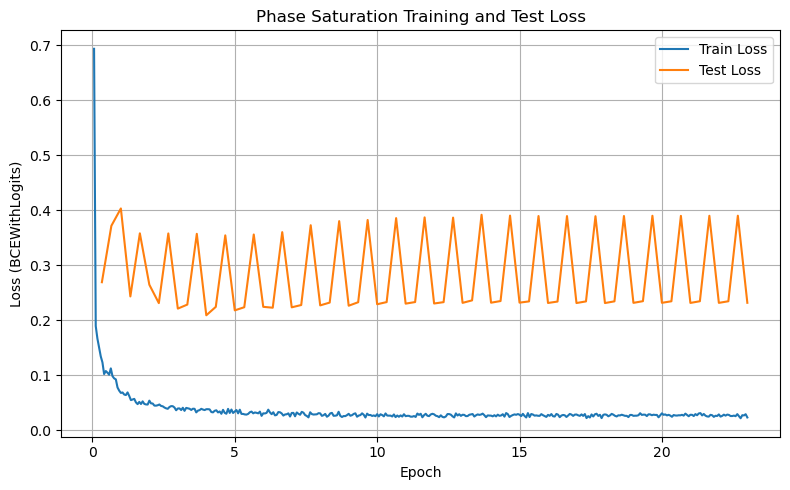

Model olivine Precision of positive prediction: 94.21% 
Model olivine Recall of dataset positives : 94.11%


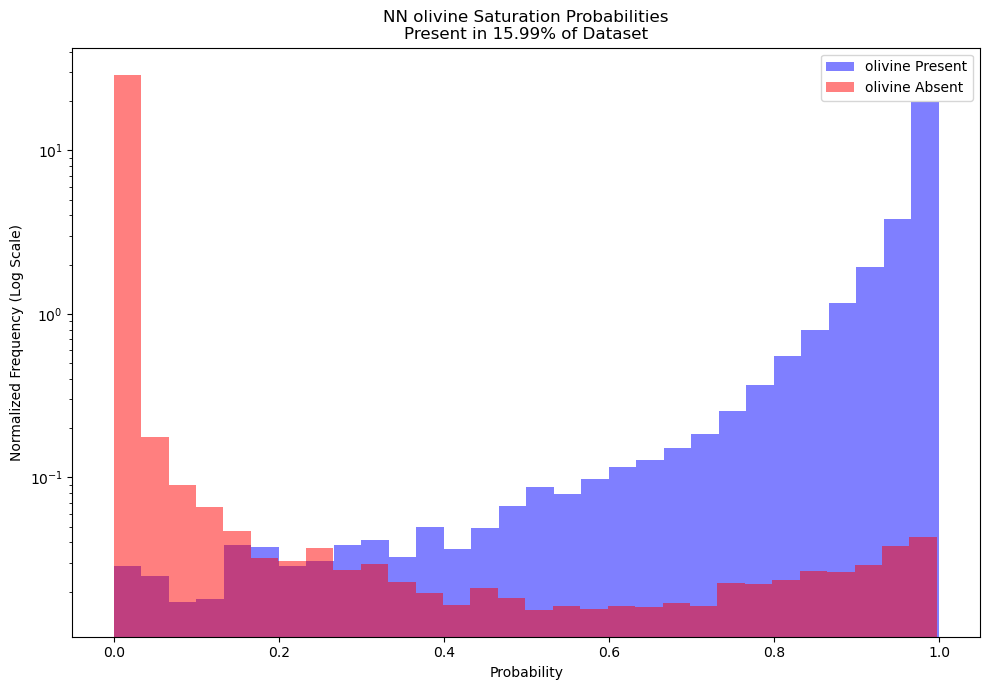

C:\Users\dashf\AppData\Local\Temp\ipykernel_54196\617715692.py:147: RuntimeWarning: invalid value encountered in scalar divide
  precision = Ytest[predPos.astype(bool),i].sum()/np.sum(predPos)


Model orthopyroxene Precision of positive prediction: nan% 
Model orthopyroxene Recall of dataset positives : 6.18%


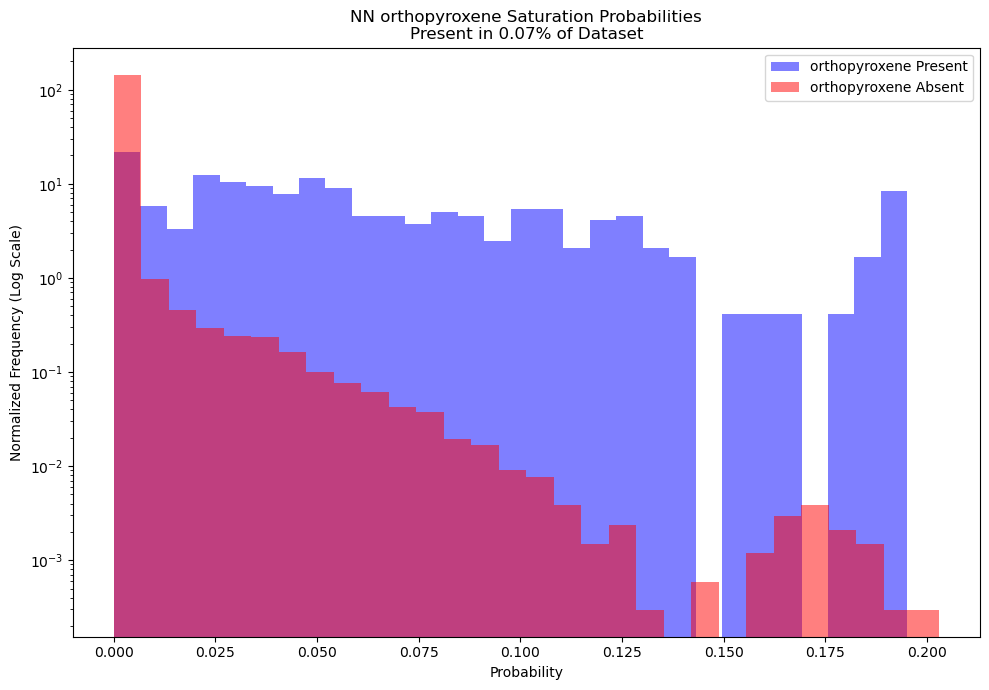

Model clinopyroxene Precision of positive prediction: 91.67% 
Model clinopyroxene Recall of dataset positives : 33.7%


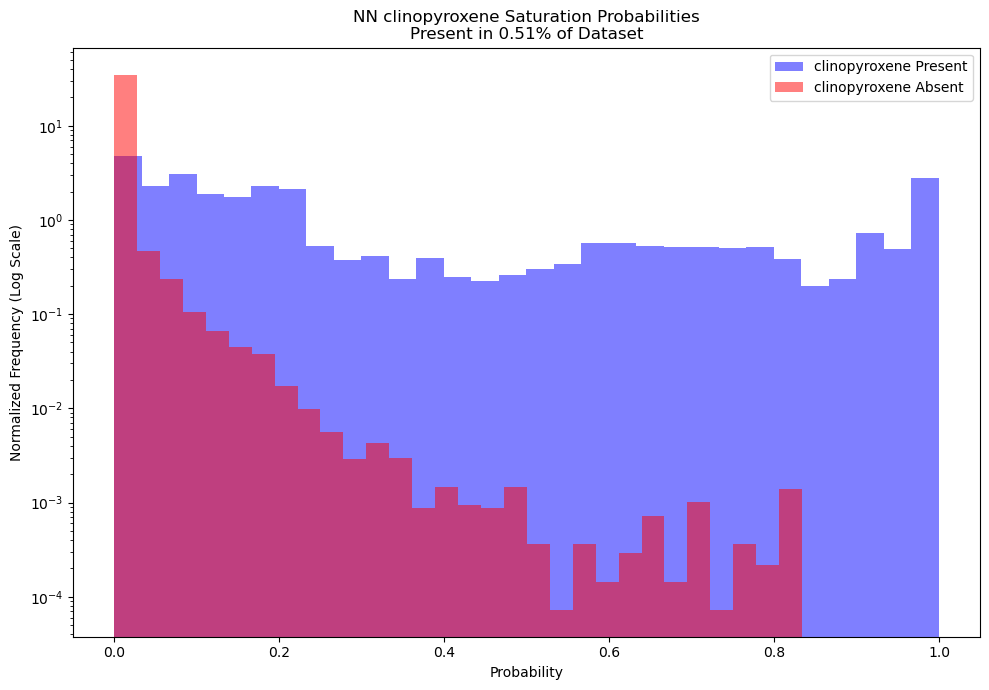

Model spinel Precision of positive prediction: 80.71% 
Model spinel Recall of dataset positives : 50.44%


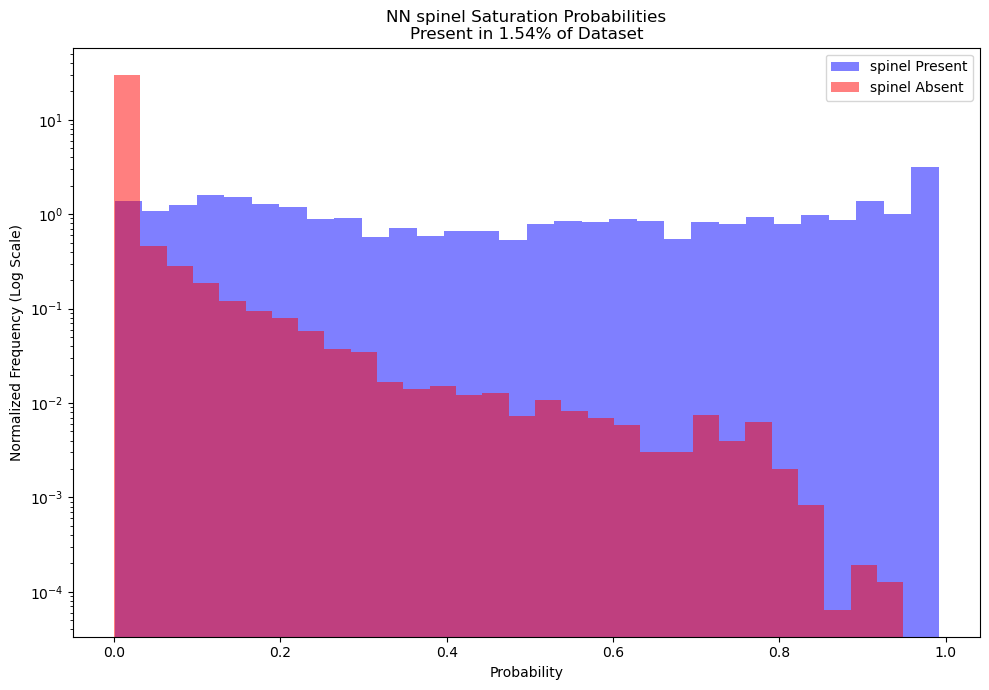

Model plagioclase Precision of positive prediction: 93.0% 
Model plagioclase Recall of dataset positives : 89.75%


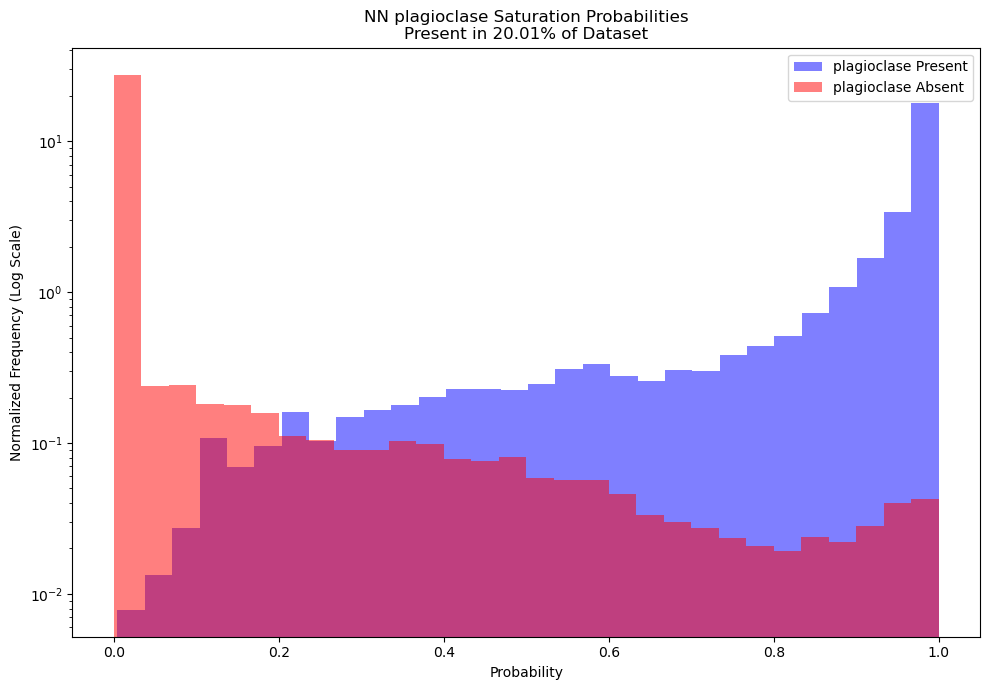

Model k-feldspar Precision of positive prediction: 90.47% 
Model k-feldspar Recall of dataset positives : 88.58%


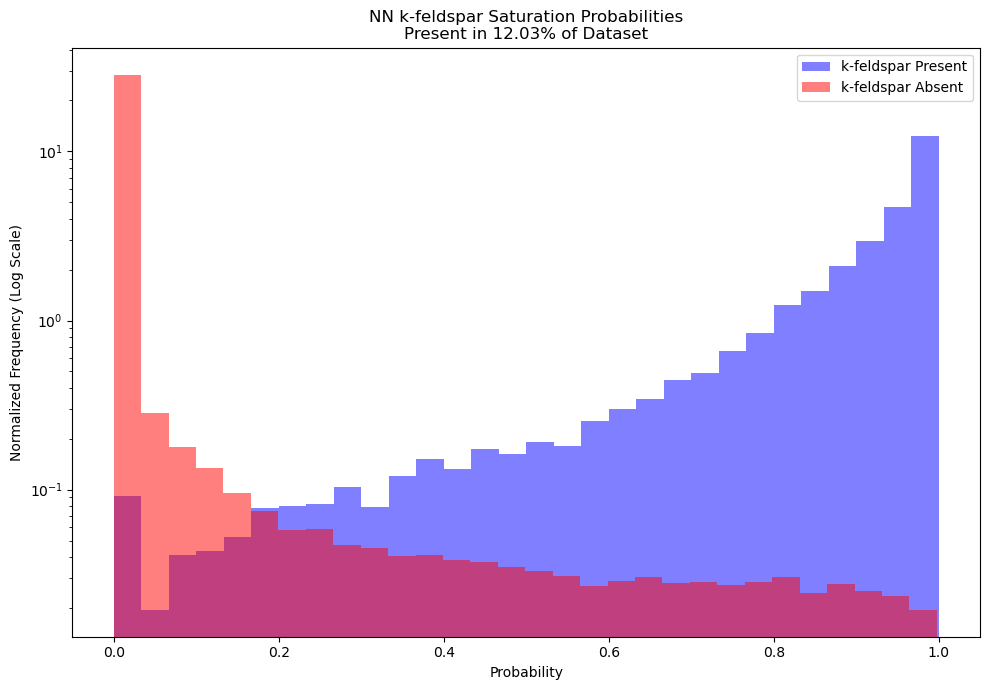

Model garnet Precision of positive prediction: 88.98% 
Model garnet Recall of dataset positives : 88.0%


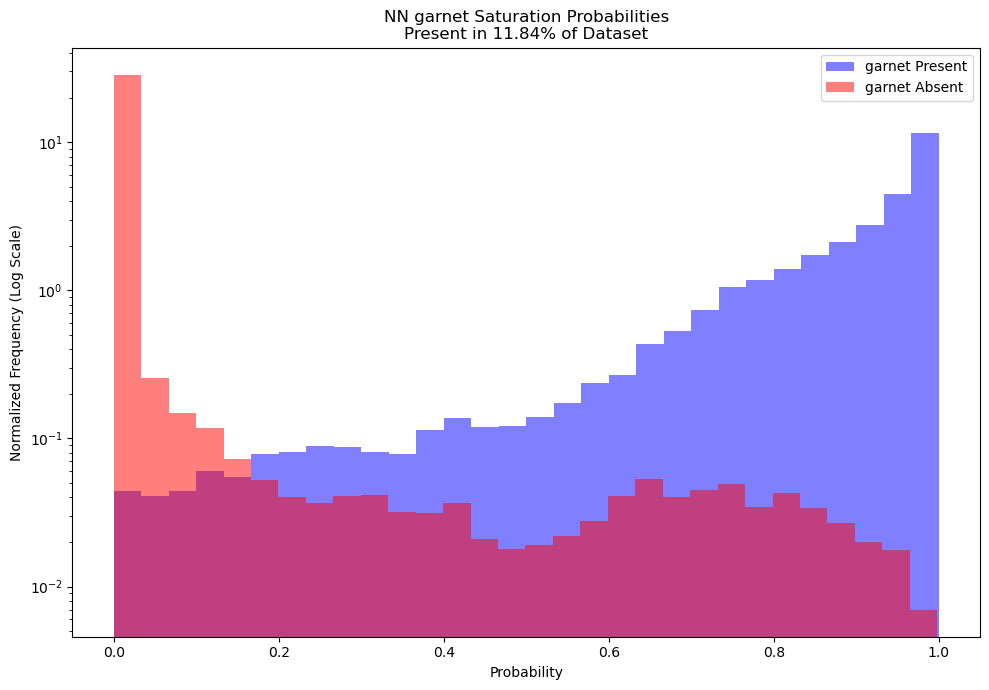

Model nepheline Precision of positive prediction: 96.23% 
Model nepheline Recall of dataset positives : 97.95%


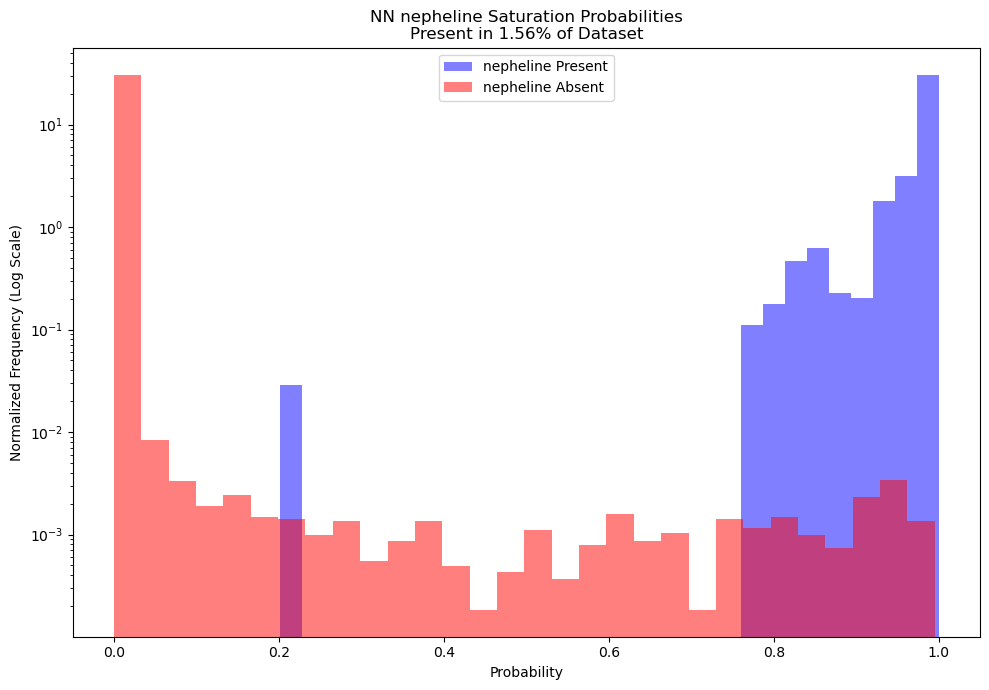

Model leucite Precision of positive prediction: 76.2% 
Model leucite Recall of dataset positives : 39.51%


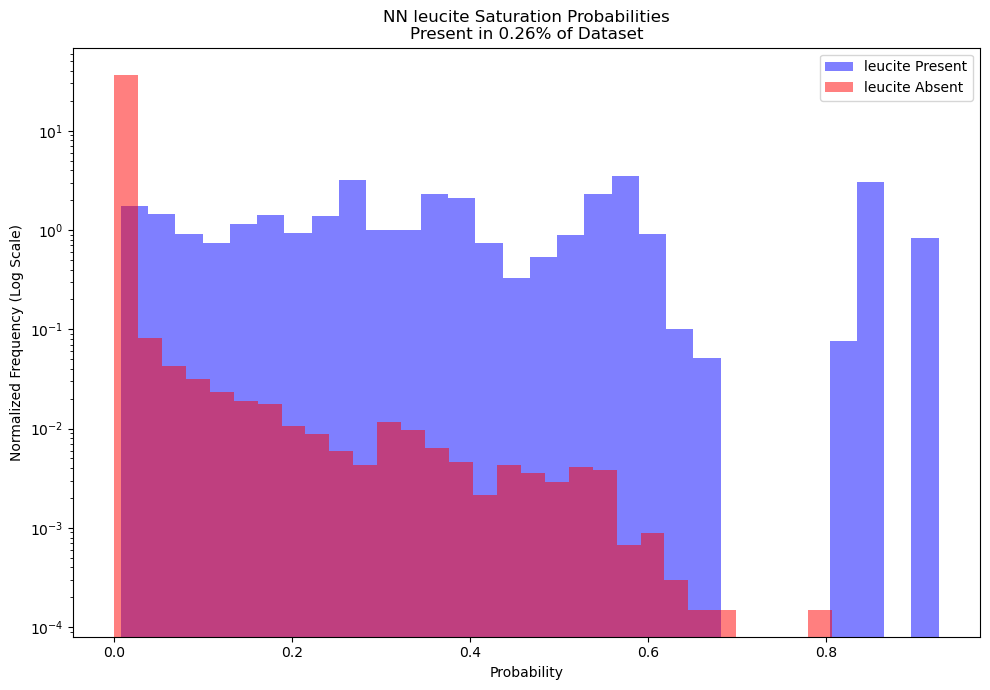

Model biotite Precision of positive prediction: 90.41% 
Model biotite Recall of dataset positives : 85.5%


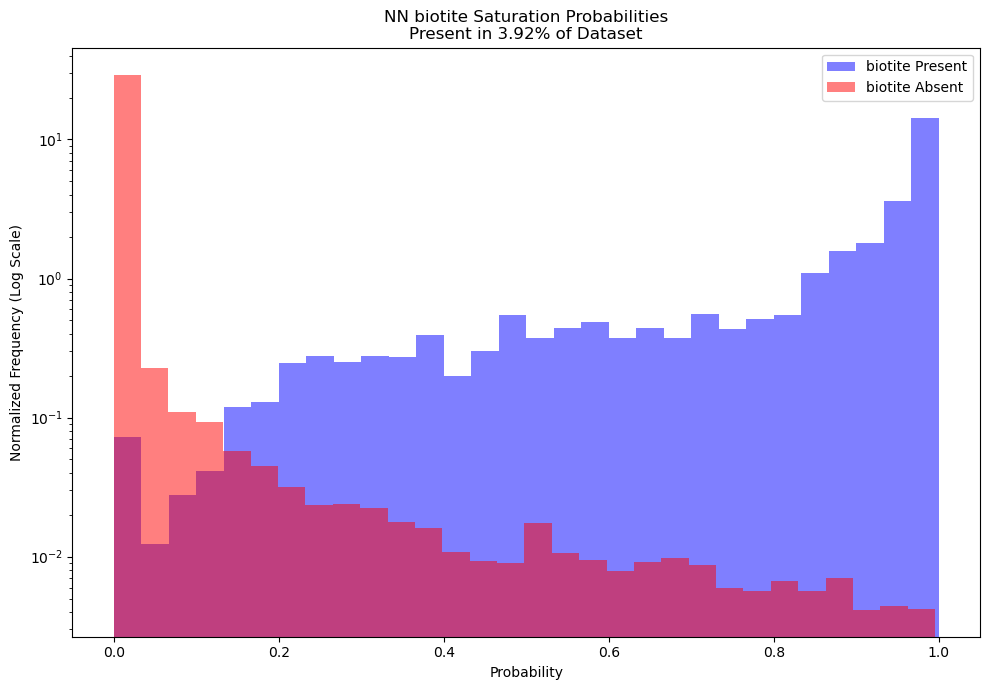

Model rhm-oxide Precision of positive prediction: 91.21% 
Model rhm-oxide Recall of dataset positives : 90.72%


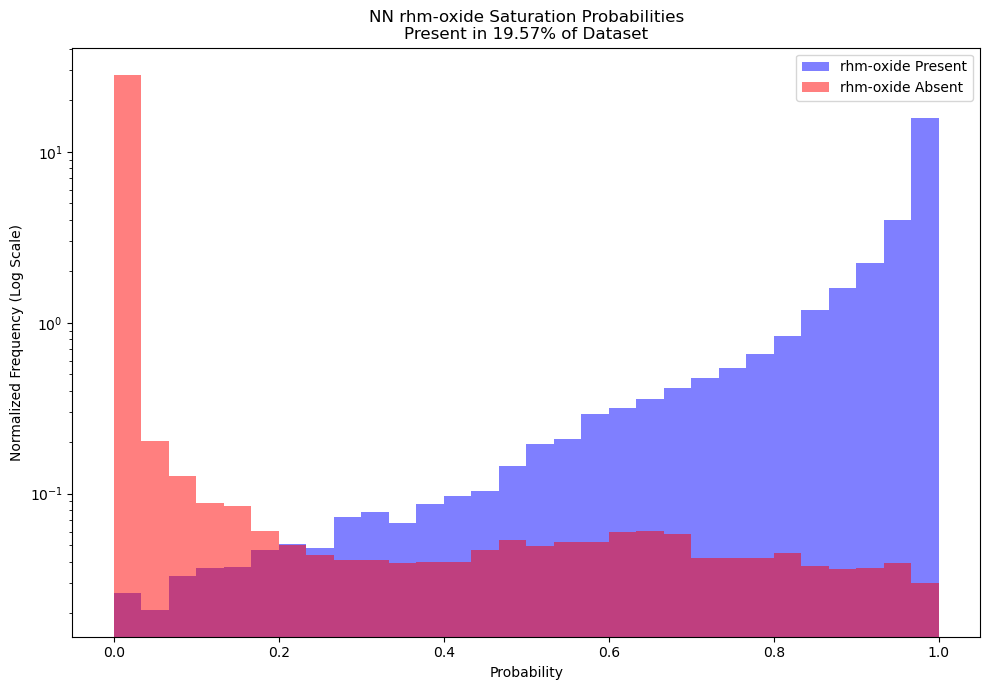

Model alloy-solid Precision of positive prediction: 54.4% 
Model alloy-solid Recall of dataset positives : 19.69%


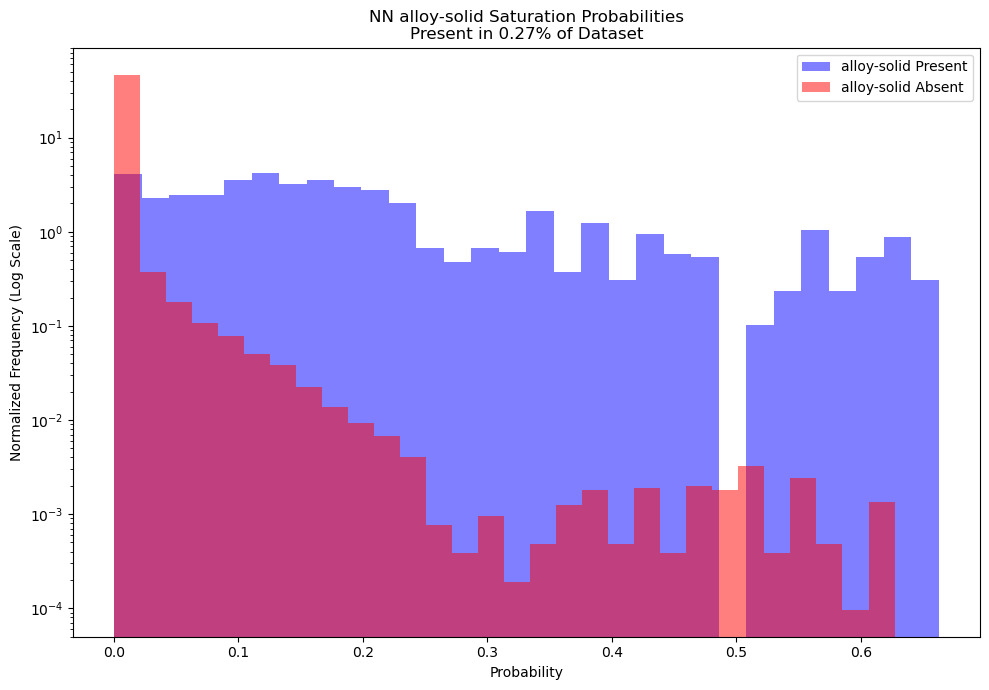

Model analcime Precision of positive prediction: 92.41% 
Model analcime Recall of dataset positives : 92.89%


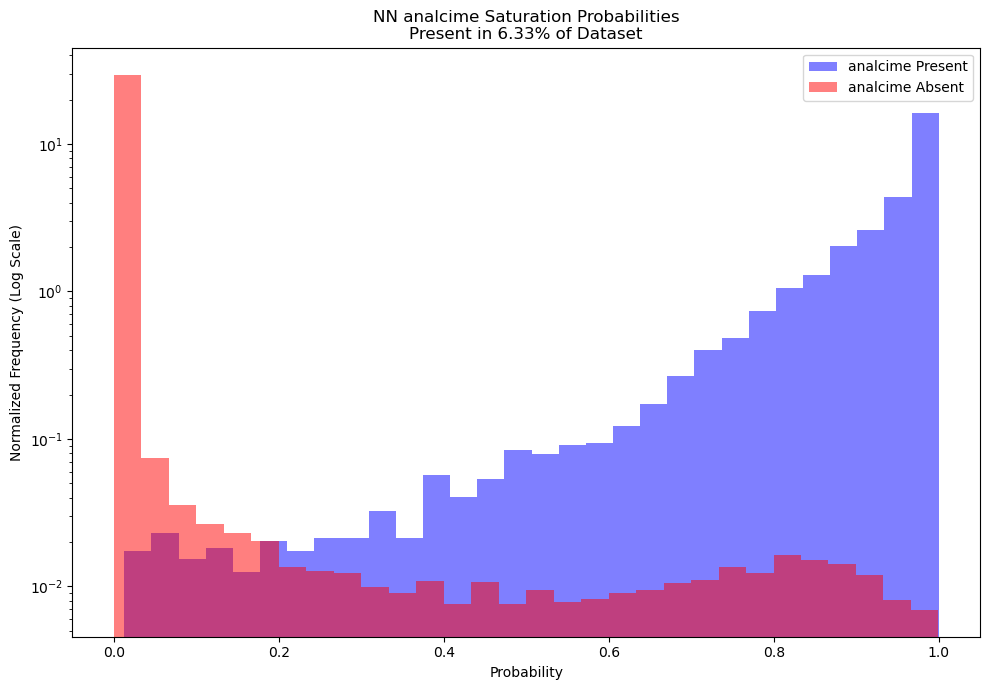

Model apatite Precision of positive prediction: 84.29% 
Model apatite Recall of dataset positives : 76.76%


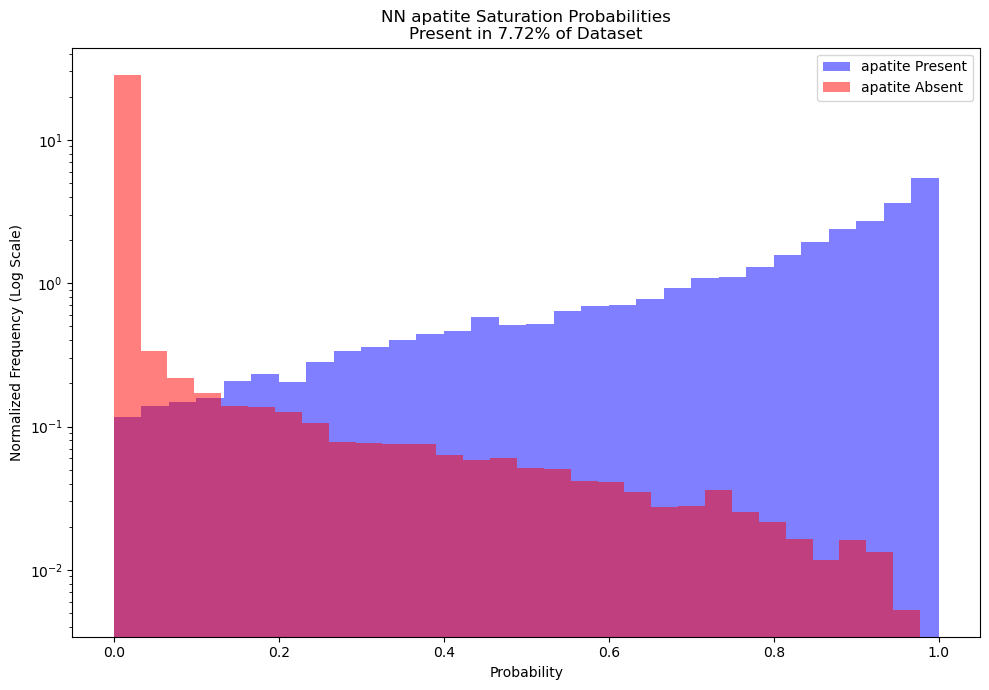

Model whitlockite Precision of positive prediction: 88.77% 
Model whitlockite Recall of dataset positives : 85.96%


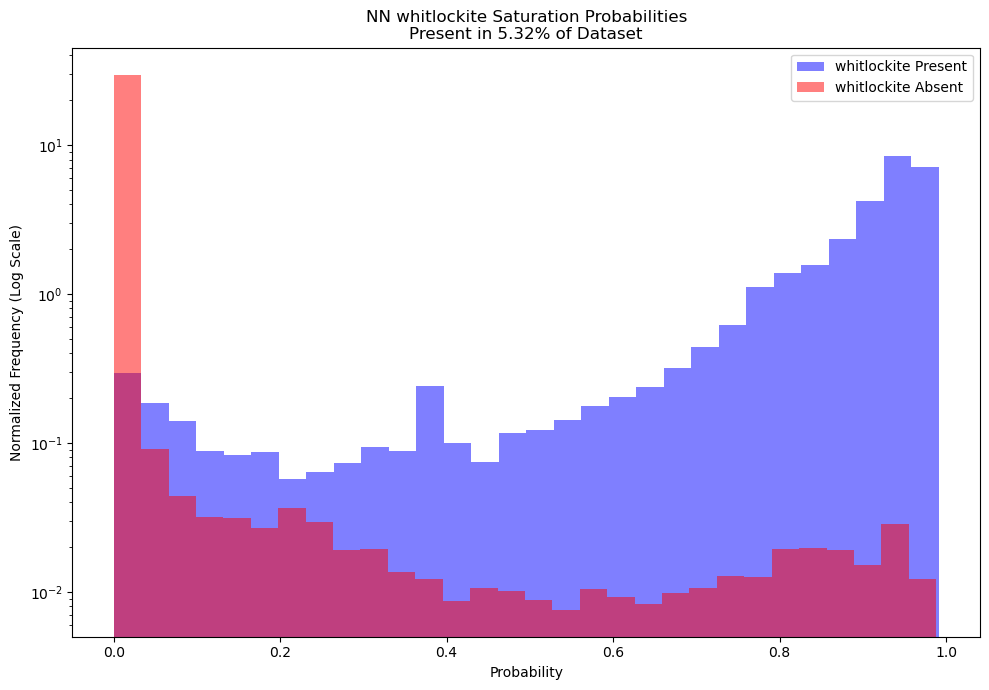

Model quartz Precision of positive prediction: 93.13% 
Model quartz Recall of dataset positives : 92.13%


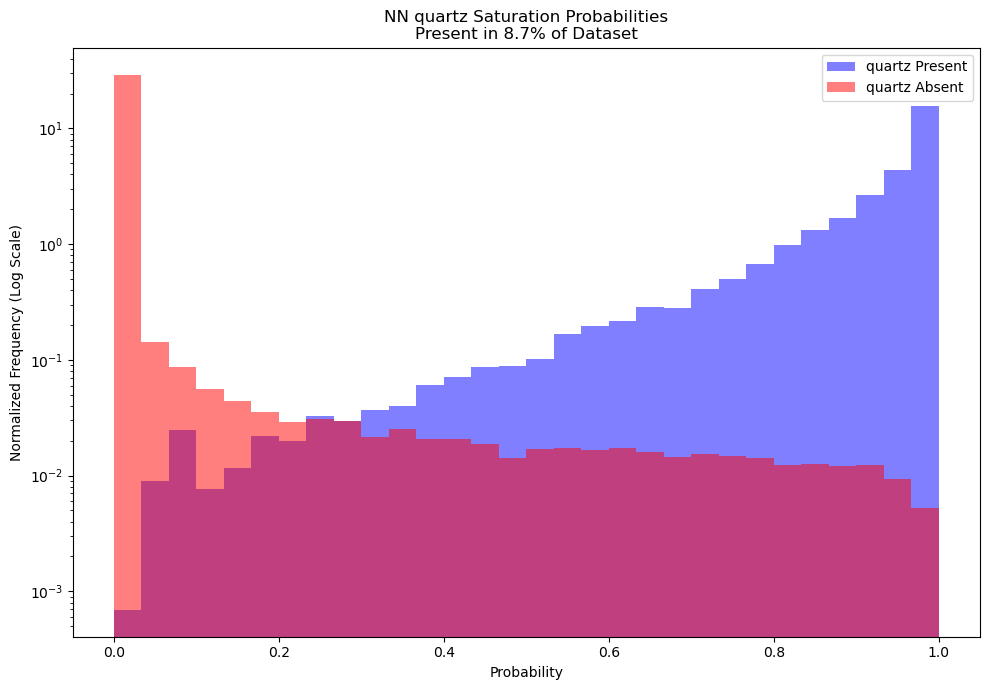

Model tridymite Precision of positive prediction: 90.74% 
Model tridymite Recall of dataset positives : 86.9%


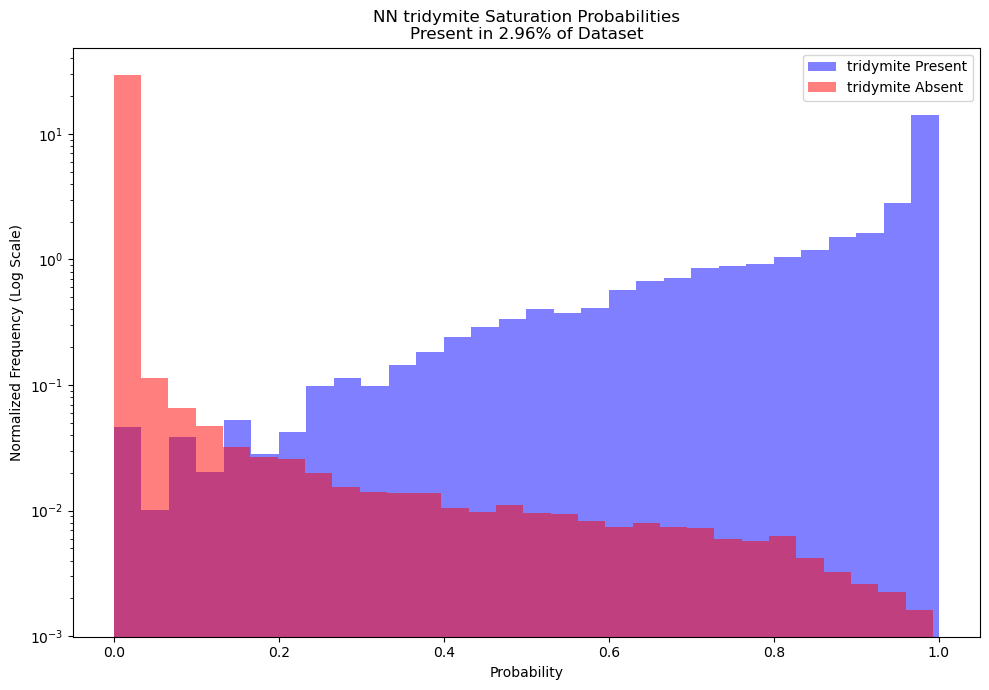

Model muscovite Precision of positive prediction: 89.89% 
Model muscovite Recall of dataset positives : 89.23%


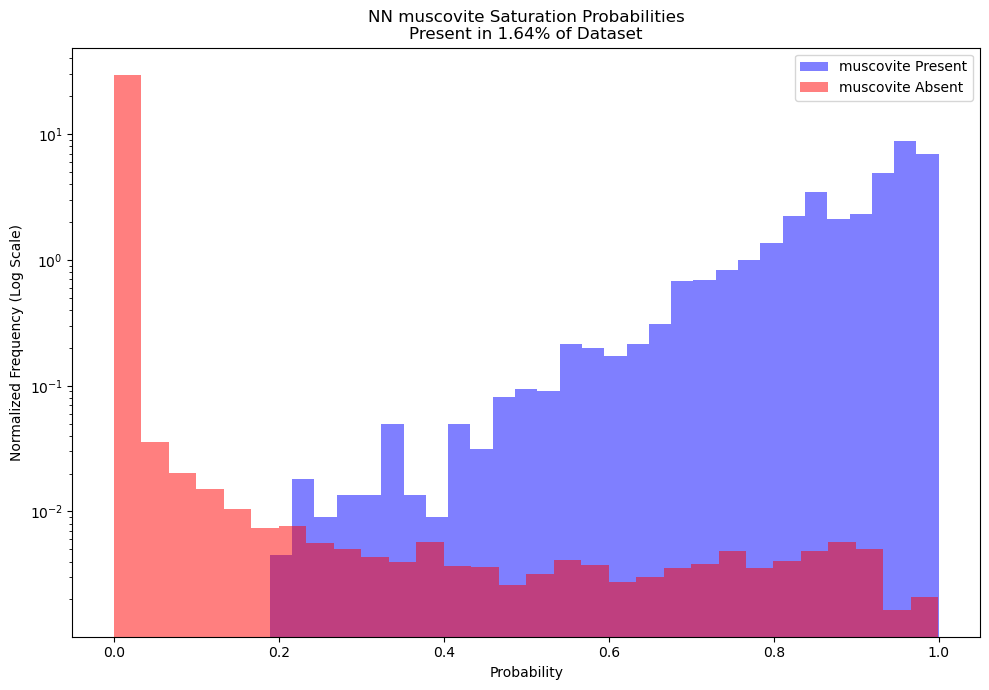

Model fluid Precision of positive prediction: 98.35% 
Model fluid Recall of dataset positives : 97.62%


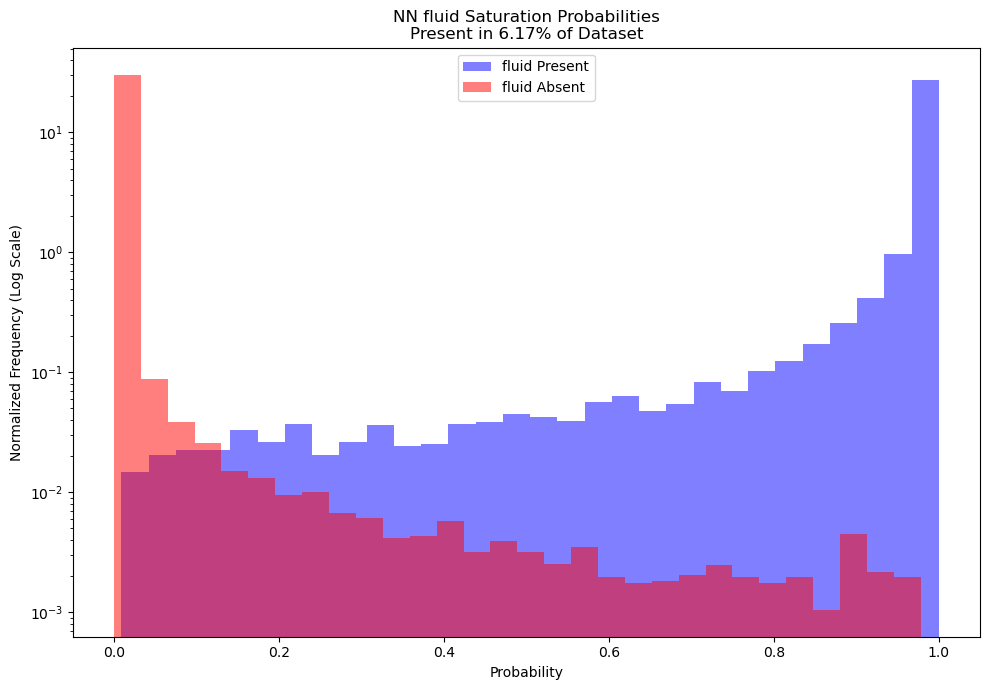

Model melts-liquid Precision of positive prediction: 100.0% 
Model melts-liquid Recall of dataset positives : 100.0%


c:\Users\dashf\anaconda3\envs\torch-env\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
c:\Users\dashf\anaconda3\envs\torch-env\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
C:\Users\dashf\AppData\Local\Temp\ipykernel_54196\617715692.py:161: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


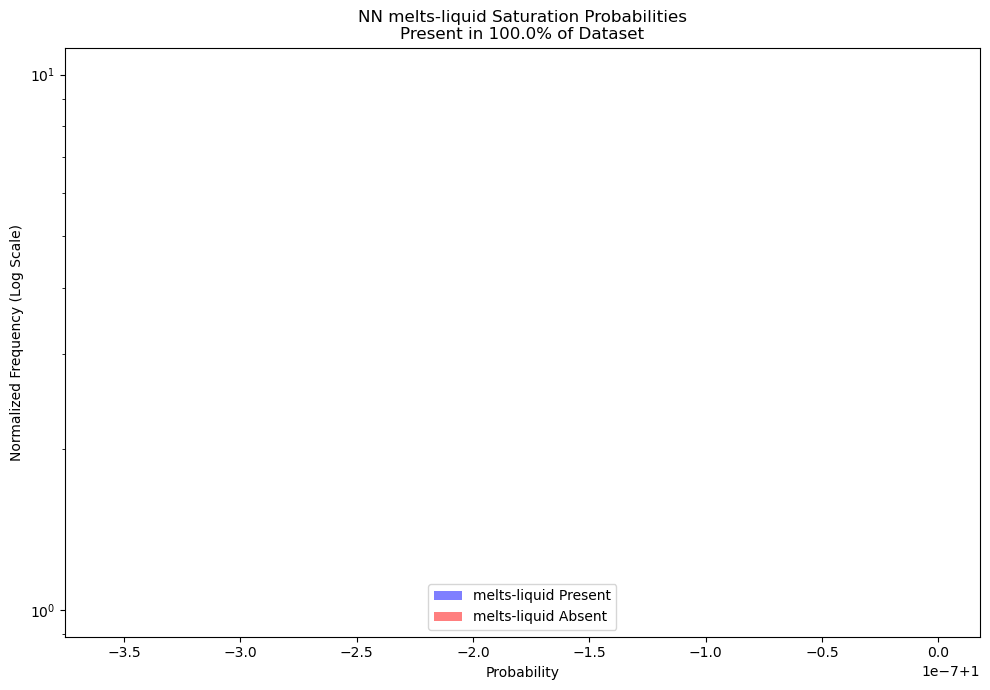

Model olivine Precision of positive prediction: 70.89% 
Model olivine Recall of dataset positives : 93.46%


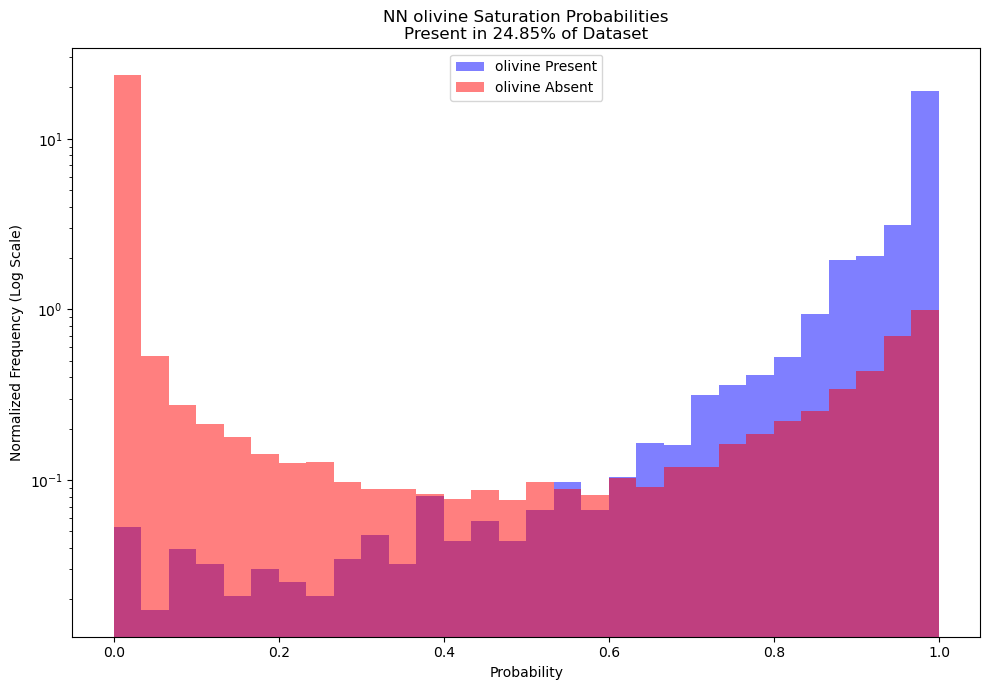

Model orthopyroxene Precision of positive prediction: nan% 
Model orthopyroxene Recall of dataset positives : 0.45%


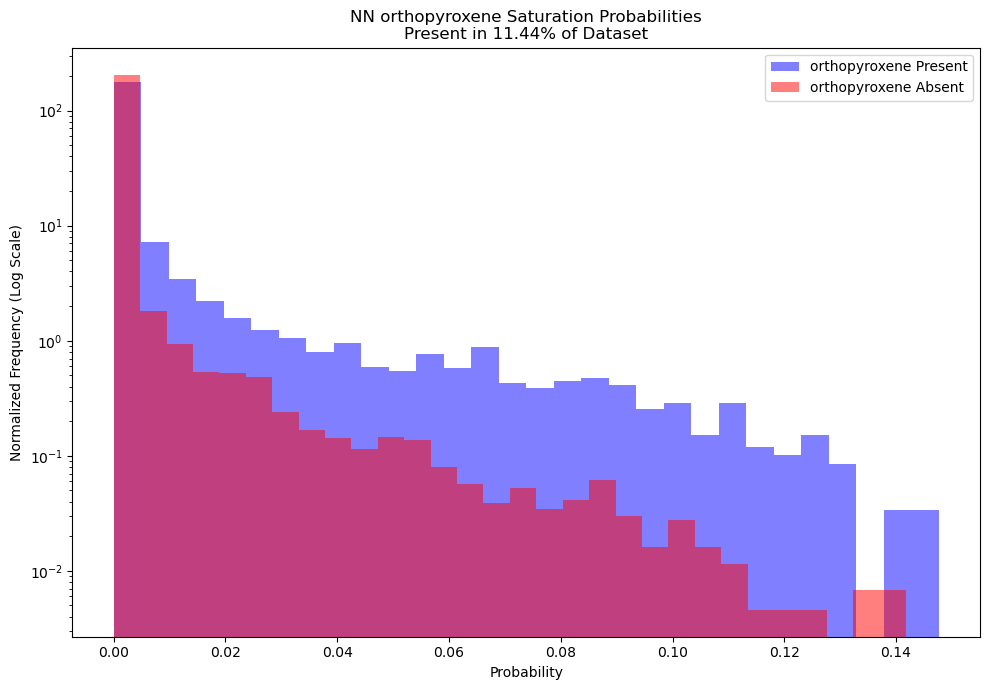

Model clinopyroxene Precision of positive prediction: 99.48% 
Model clinopyroxene Recall of dataset positives : 9.42%


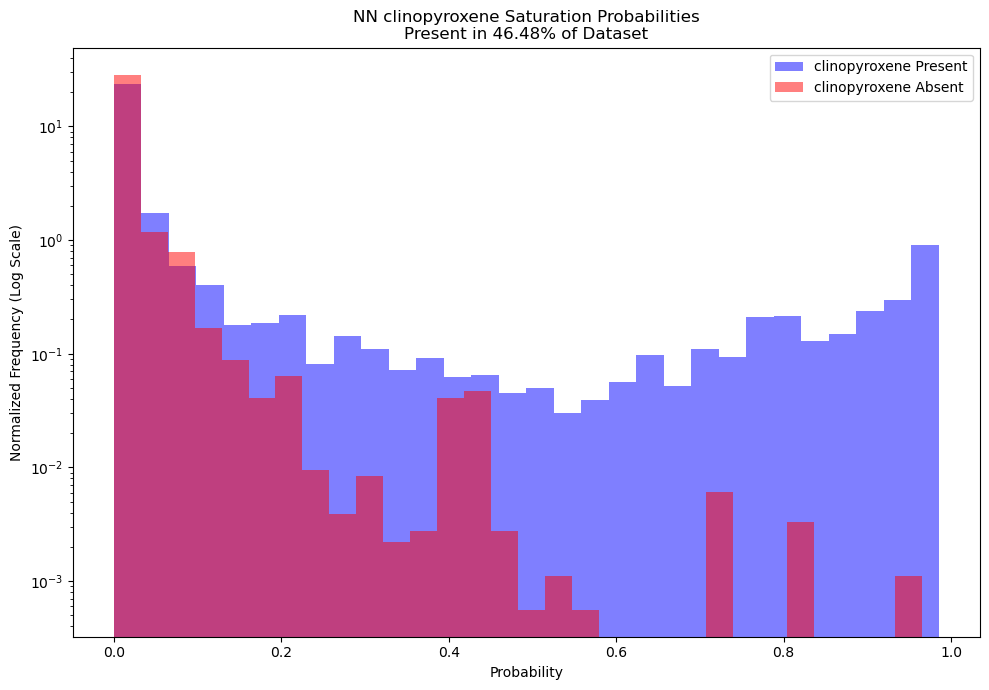

Model spinel Precision of positive prediction: 97.88% 
Model spinel Recall of dataset positives : 21.49%


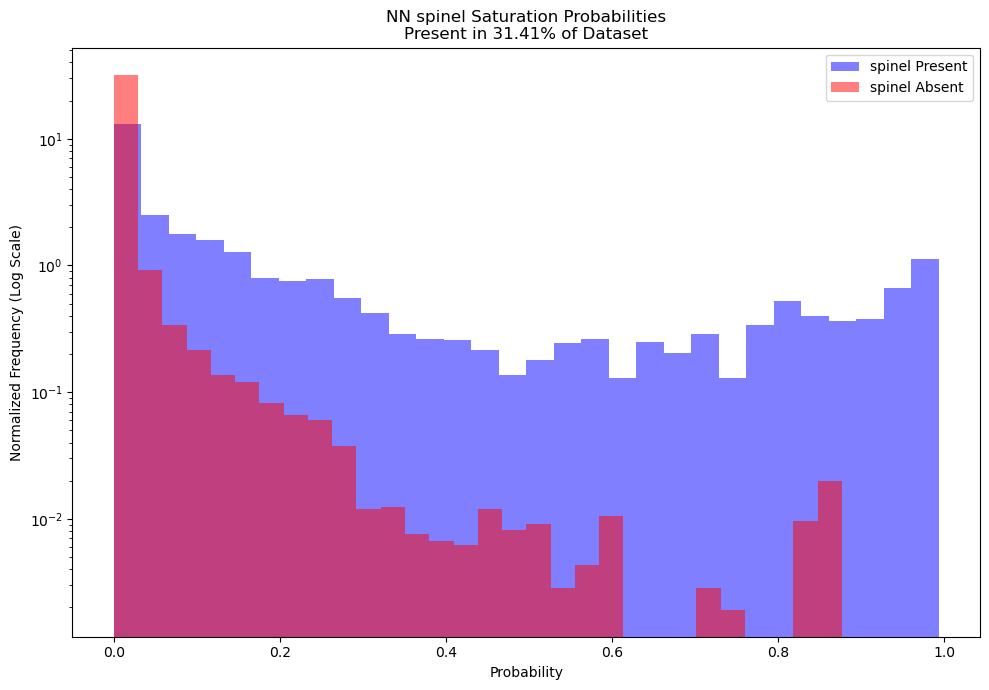

Model plagioclase Precision of positive prediction: 91.09% 
Model plagioclase Recall of dataset positives : 91.98%


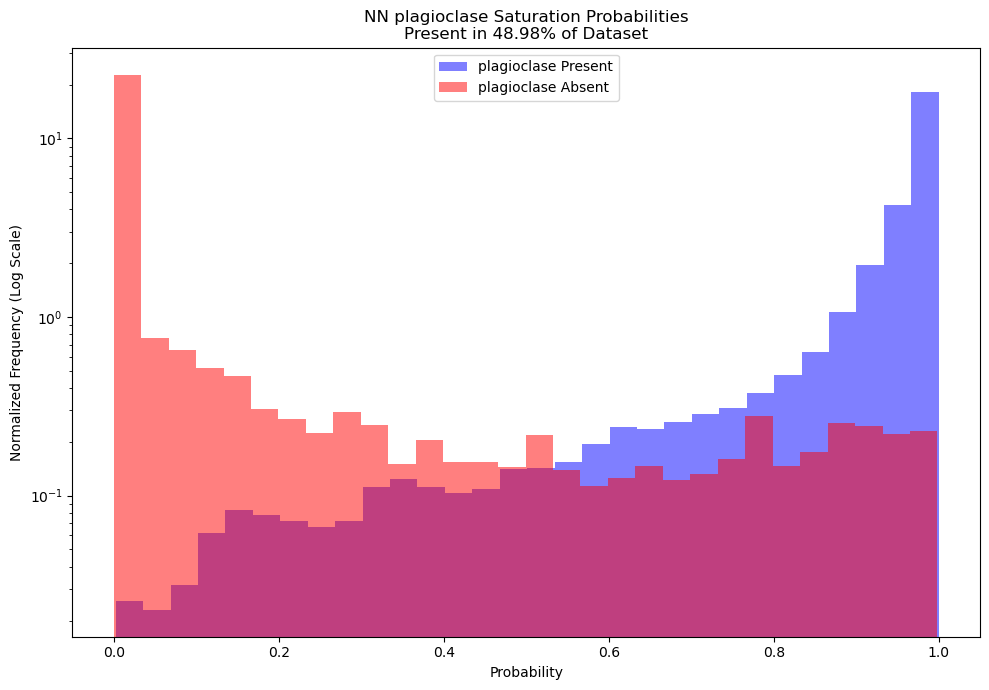

Model k-feldspar Precision of positive prediction: 80.7% 
Model k-feldspar Recall of dataset positives : 75.19%


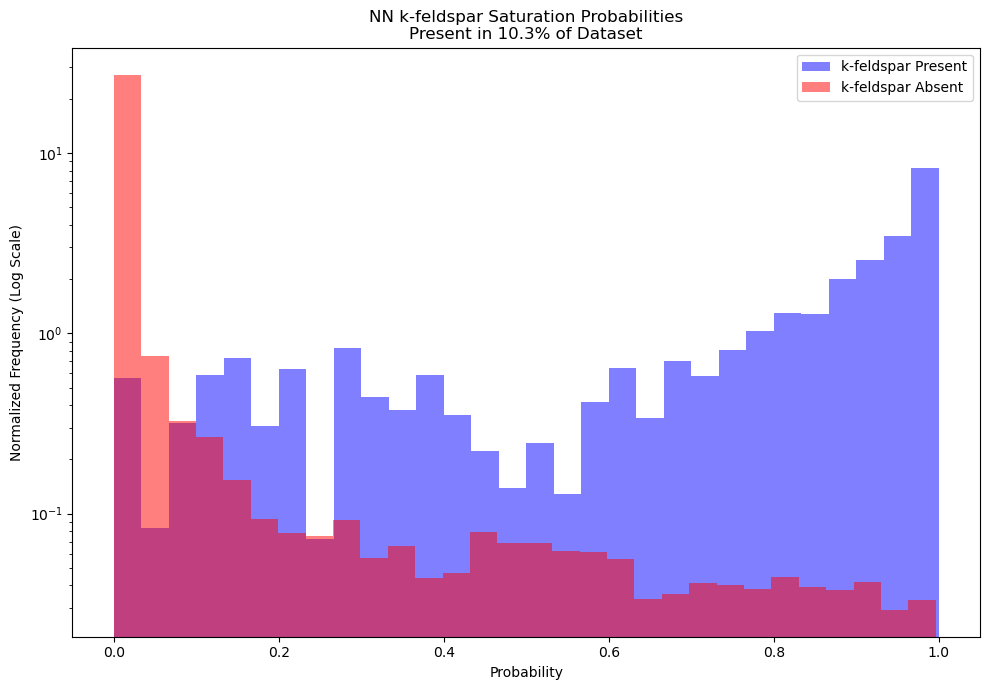

Model garnet Precision of positive prediction: 46.36% 
Model garnet Recall of dataset positives : 86.62%


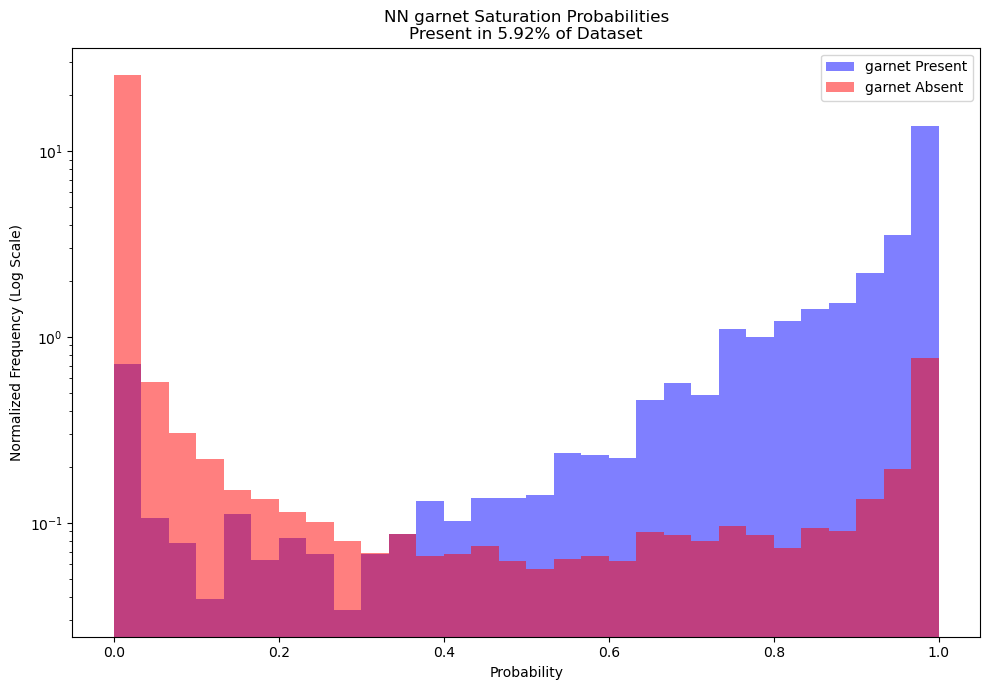

Model nepheline Precision of positive prediction: 86.0% 
Model nepheline Recall of dataset positives : 96.52%


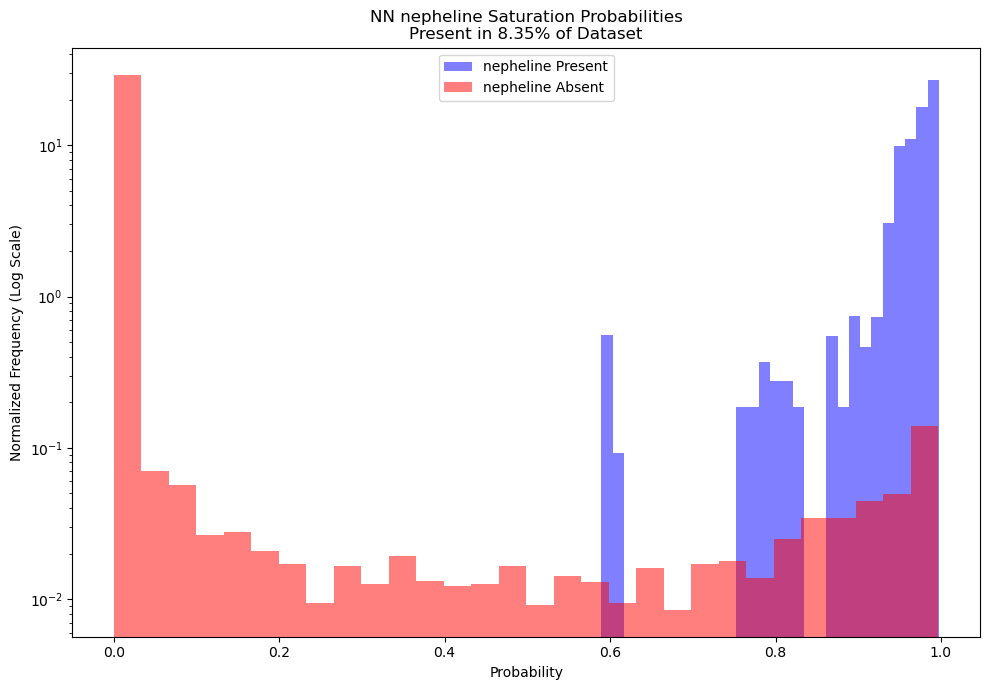

Model leucite Precision of positive prediction: 71.0% 
Model leucite Recall of dataset positives : 34.88%


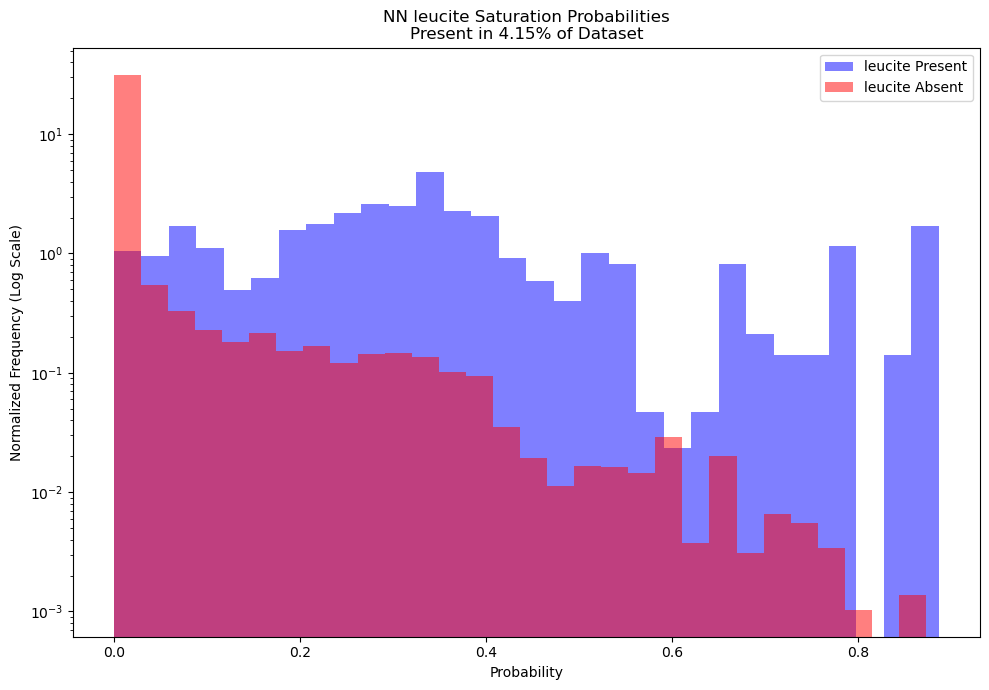

Model biotite Precision of positive prediction: 76.67% 
Model biotite Recall of dataset positives : 84.82%


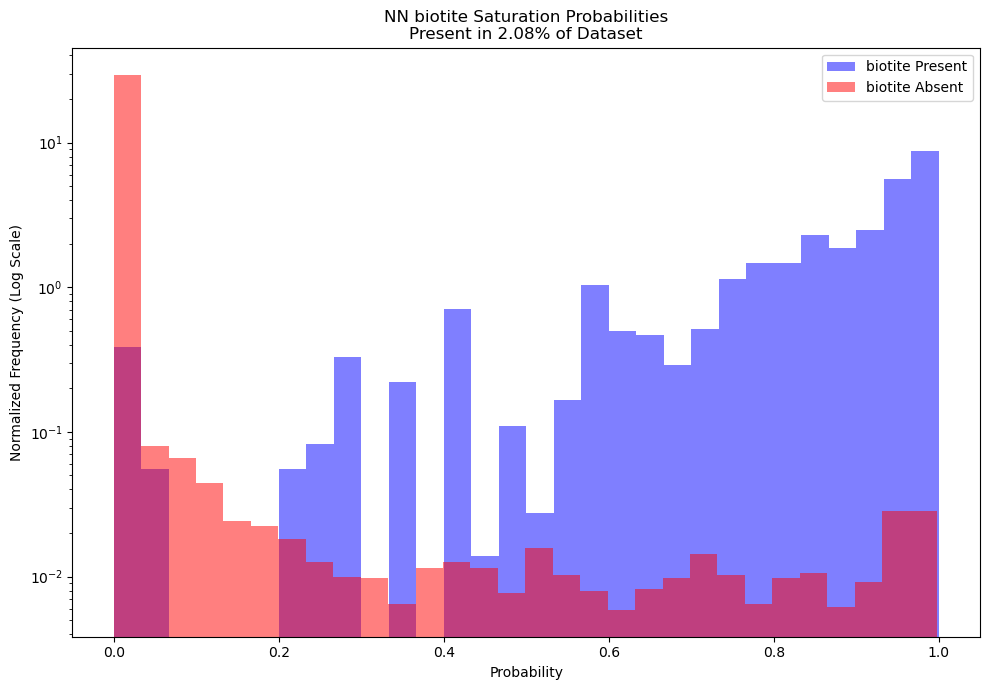

Model rhm-oxide Precision of positive prediction: 74.04% 
Model rhm-oxide Recall of dataset positives : 74.09%


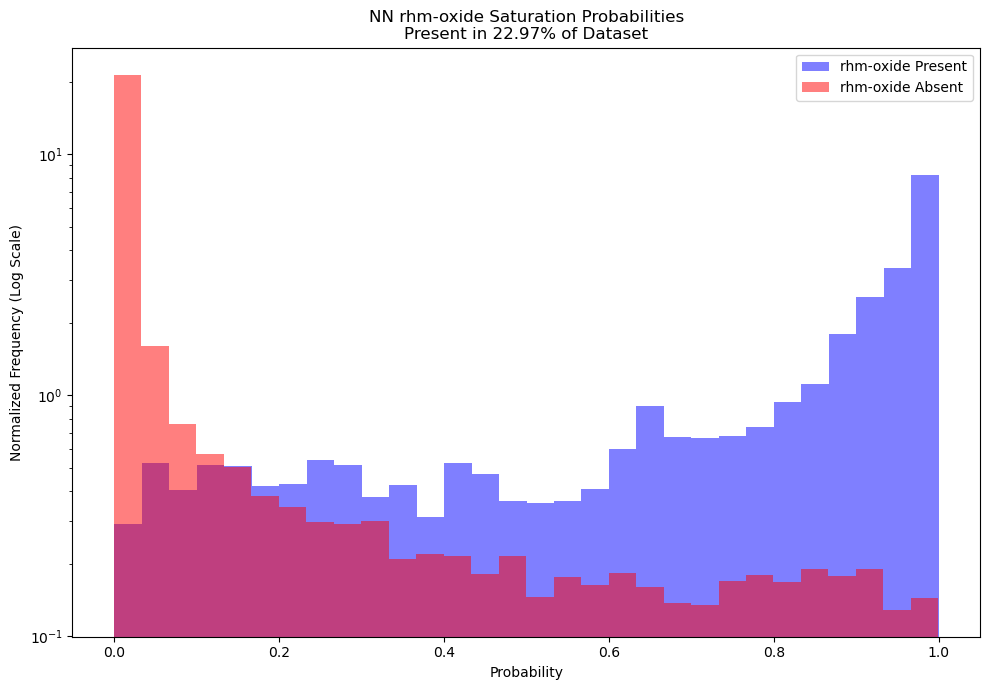

Model alloy-solid Precision of positive prediction: 37.5% 
Model alloy-solid Recall of dataset positives : 8.8%


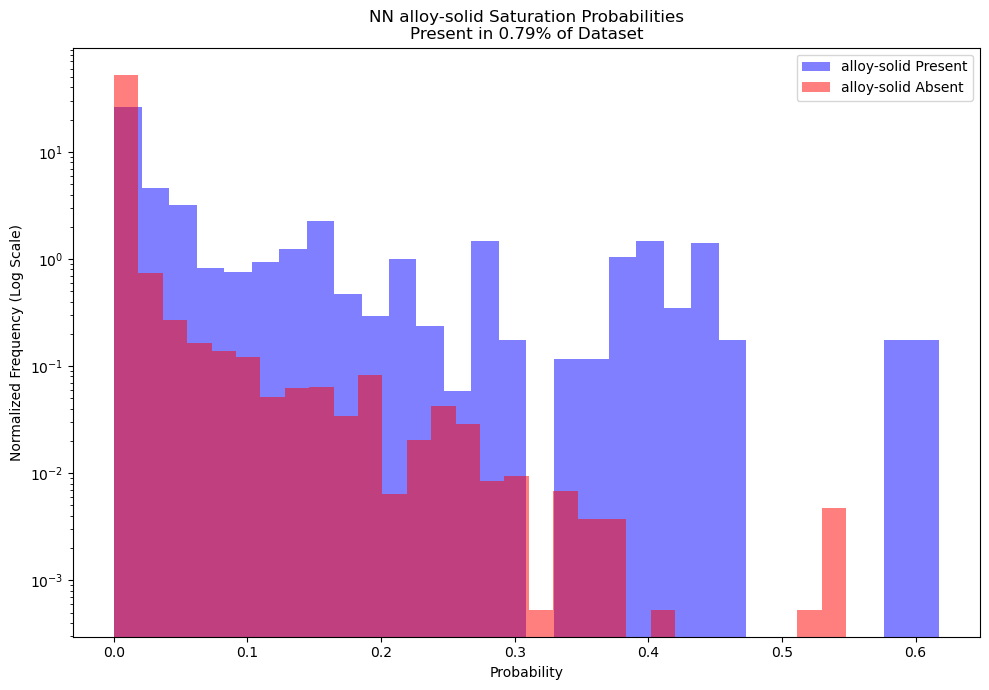

Model analcime Precision of positive prediction: 86.78% 
Model analcime Recall of dataset positives : 87.45%


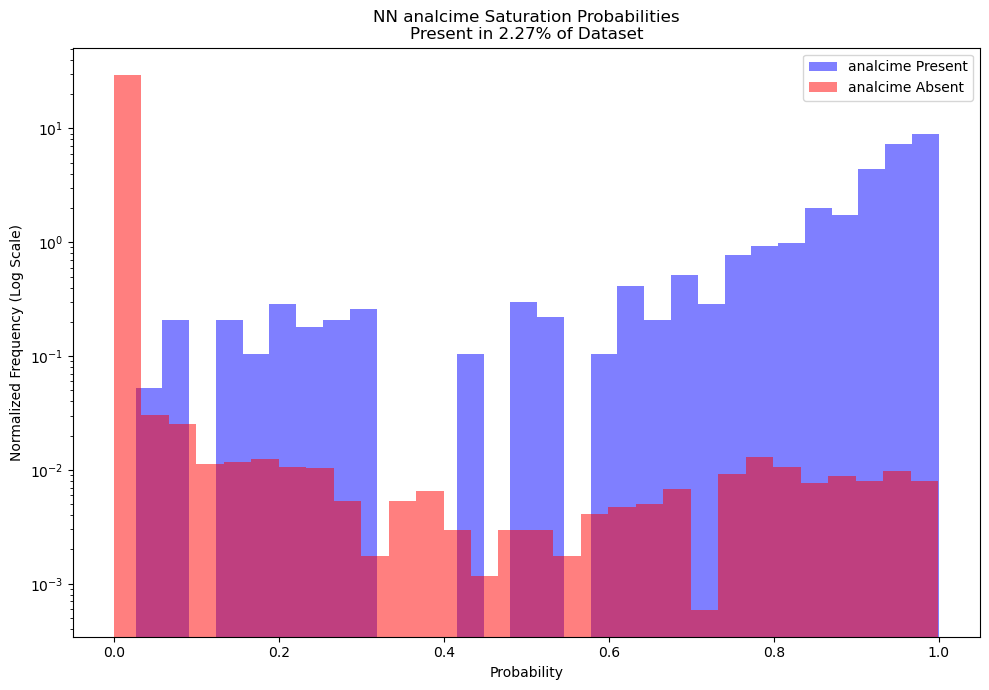

Model apatite Precision of positive prediction: 76.44% 
Model apatite Recall of dataset positives : 69.45%


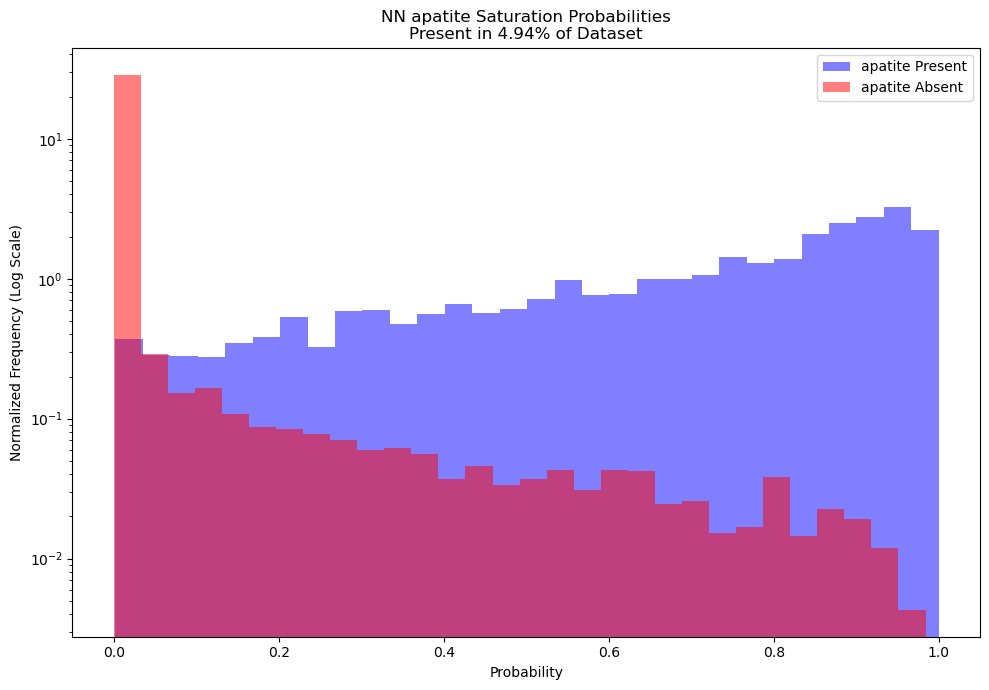

Model whitlockite Precision of positive prediction: 90.76% 
Model whitlockite Recall of dataset positives : 82.25%


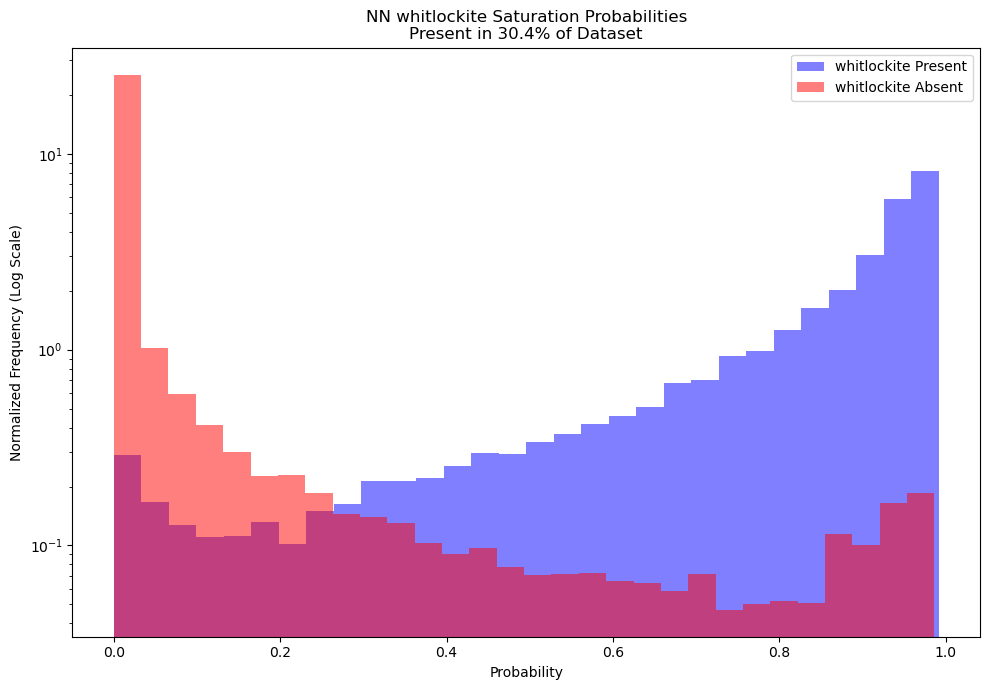

Model quartz Precision of positive prediction: 85.79% 
Model quartz Recall of dataset positives : 86.57%


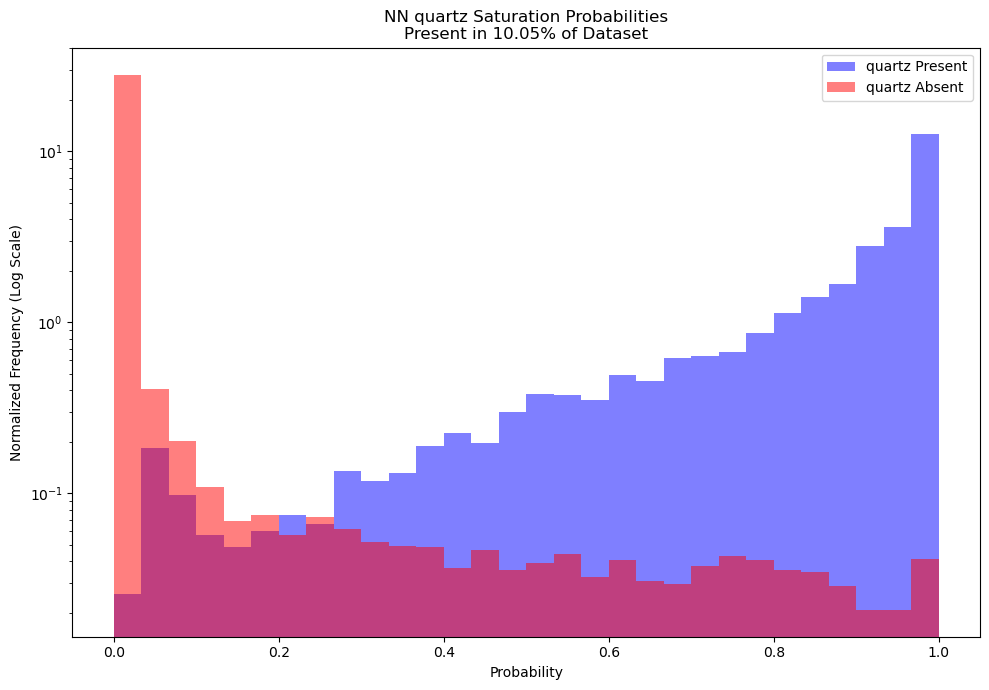

Model tridymite Precision of positive prediction: 84.42% 
Model tridymite Recall of dataset positives : 83.27%


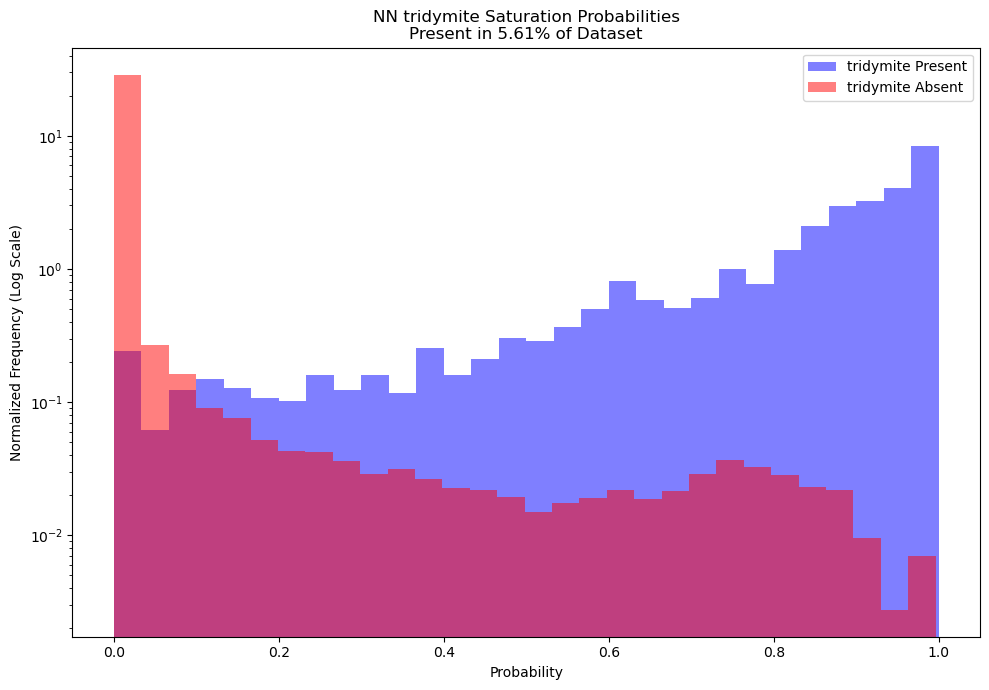

Model muscovite Precision of positive prediction: 85.25% 
Model muscovite Recall of dataset positives : 80.51%


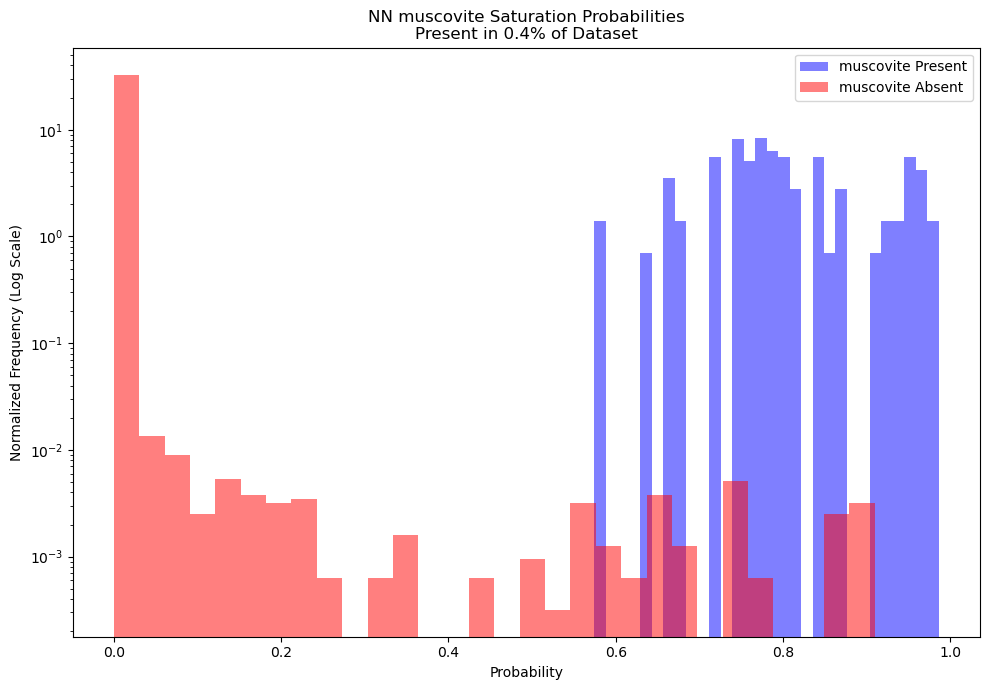

Model fluid Precision of positive prediction: 97.2% 
Model fluid Recall of dataset positives : 97.66%


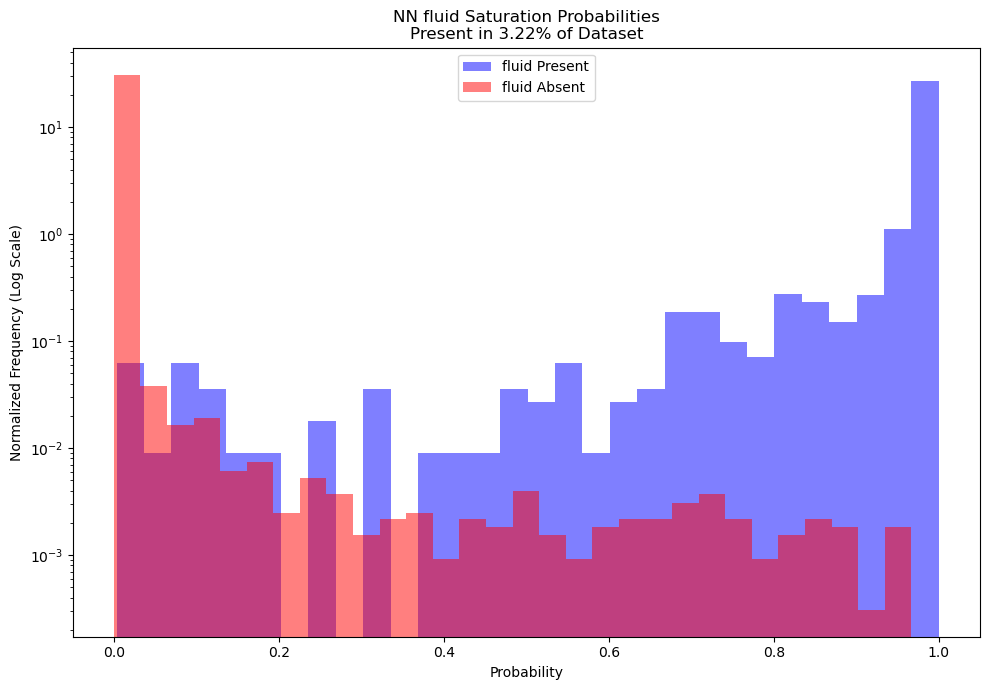

Model melts-liquid Precision of positive prediction: 100.0% 
Model melts-liquid Recall of dataset positives : 100.0%


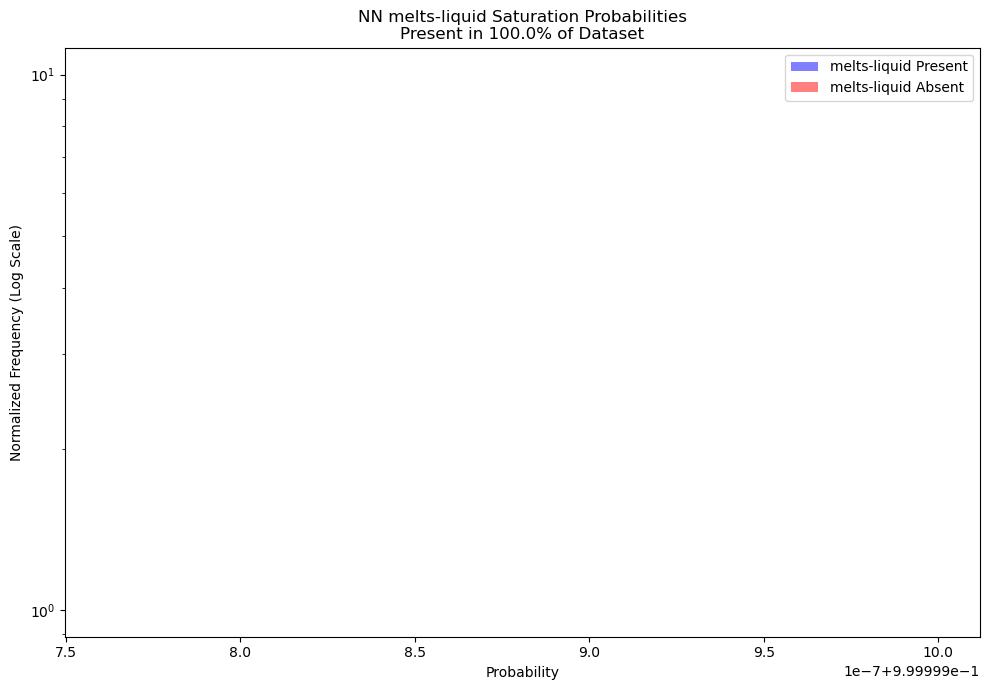


--- Epoch 2 ---


Training:   0%|          | 4/879 [00:03<09:20,  1.56it/s]

[  0.0%] Batch     0 Loss: 0.7167


Training:  24%|██▍       | 213/879 [00:07<00:11, 58.02it/s]

[ 22.8%] Batch   200 Loss: 0.3713


...

Training:  69%|██████▉   | 607/879 [00:16<00:06, 42.93it/s]

[ 68.3%] Batch   600 Loss: 0.0886


Training:  92%|█████████▏| 807/879 [00:20<00:01, 50.44it/s]

[ 91.0%] Batch   800 Loss: 0.0866


Running Saturation Loss: 14435.7321
Epoch 29 | Train Loss: 0.087243 | Test Loss: 0.356508
[TIMER] Epoch time: 28.14 seconds
No Improvement in 3 epochs. New LR: 1e-07. New Weight Decay: 0


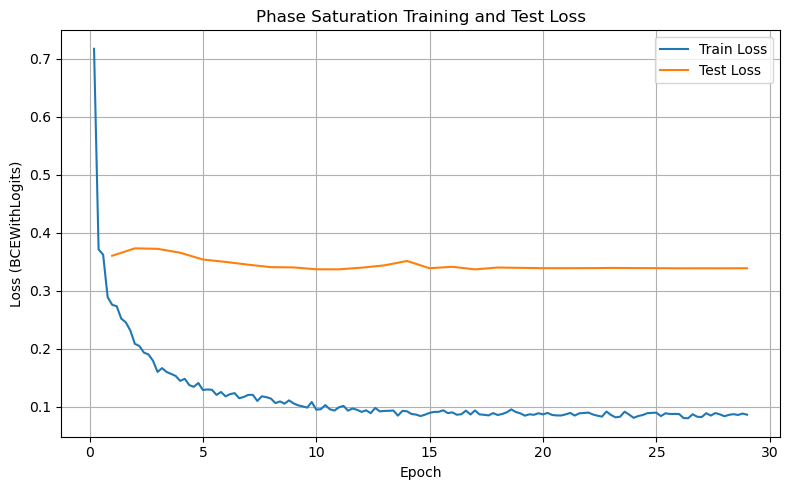

Model olivine Precision of positive prediction: 91.88% 
Model olivine Recall of dataset positives : 89.49%


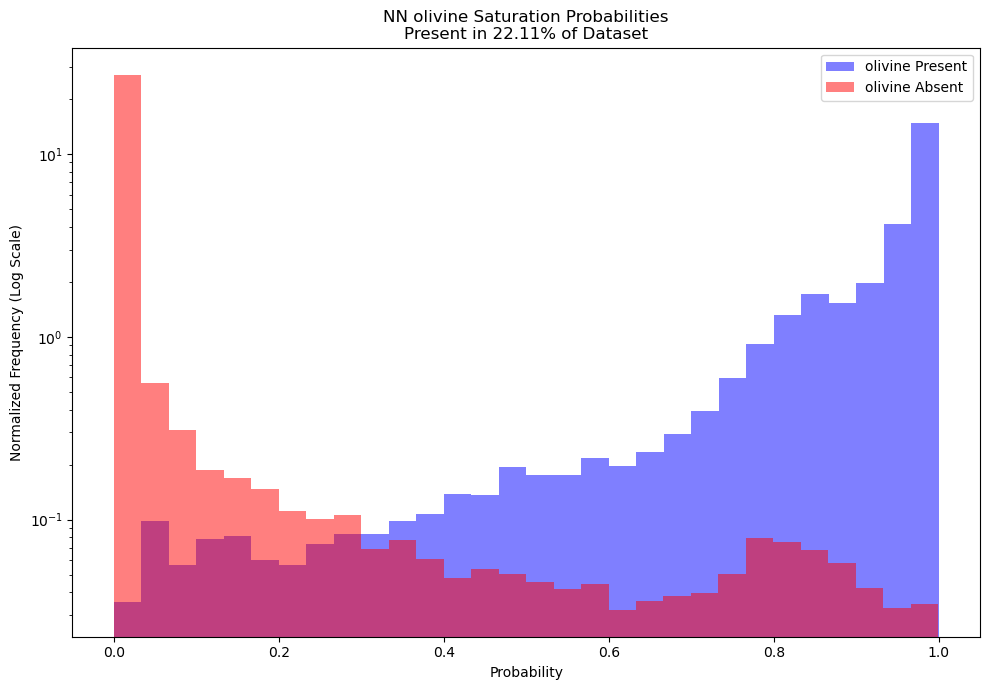

C:\Users\dashf\AppData\Local\Temp\ipykernel_54196\617715692.py:147: RuntimeWarning: invalid value encountered in scalar divide
  precision = Ytest[predPos.astype(bool),i].sum()/np.sum(predPos)


Model orthopyroxene Precision of positive prediction: nan% 
Model orthopyroxene Recall of dataset positives : 1.6%


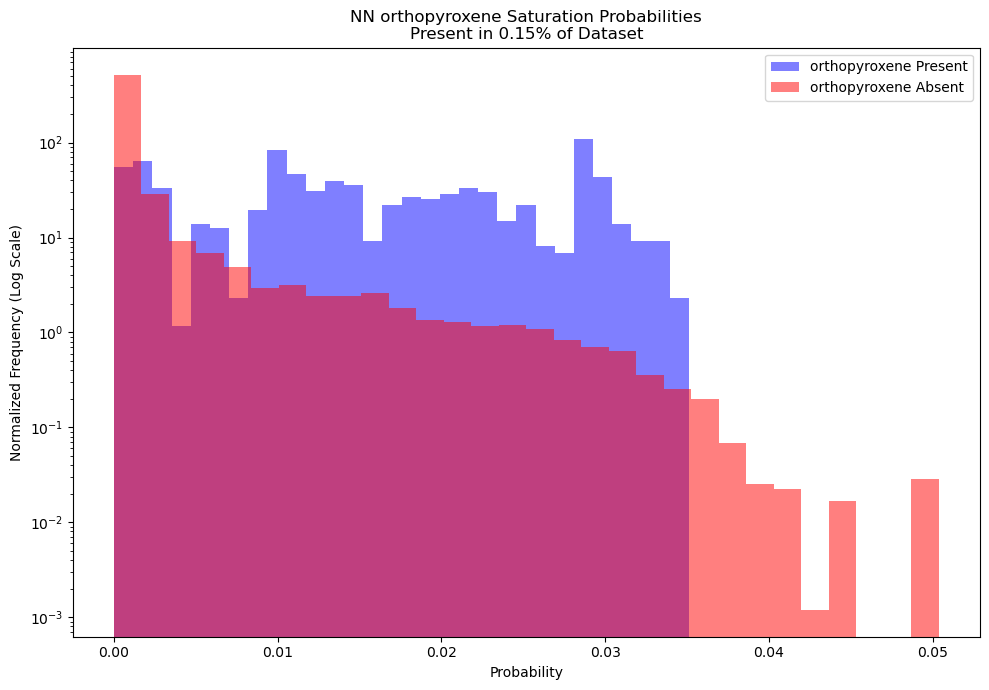

Model clinopyroxene Precision of positive prediction: 88.84% 
Model clinopyroxene Recall of dataset positives : 37.79%


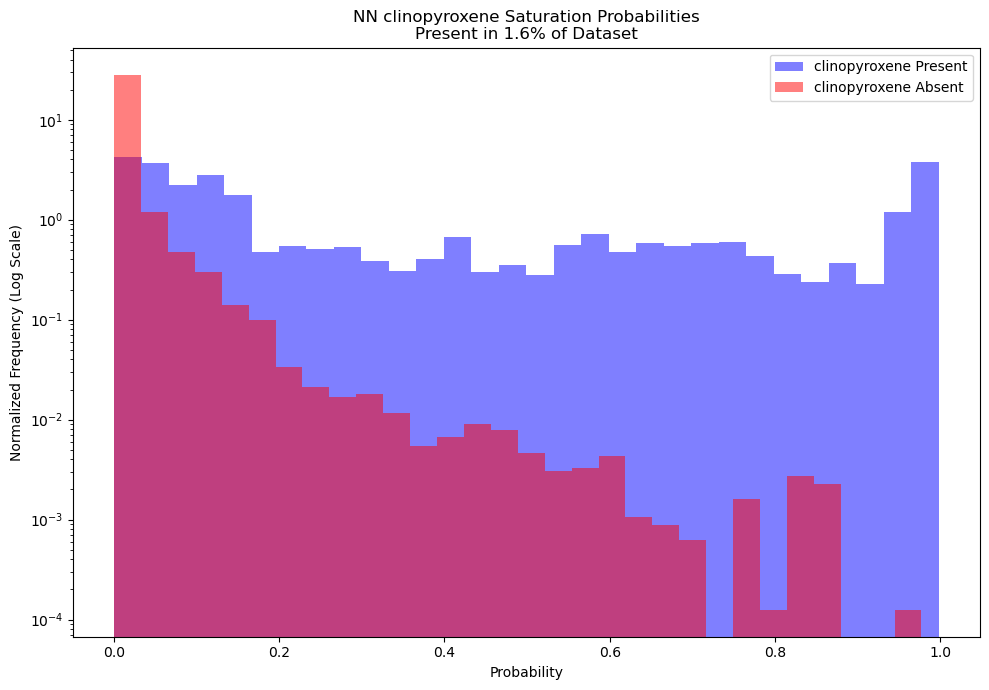

Model spinel Precision of positive prediction: 72.36% 
Model spinel Recall of dataset positives : 42.13%


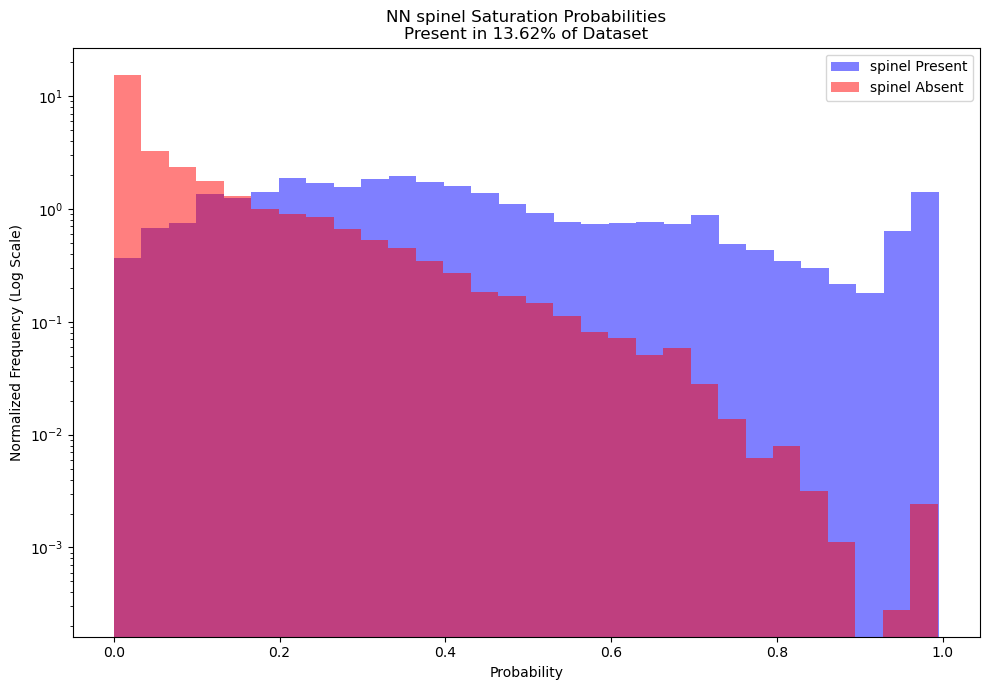

Model plagioclase Precision of positive prediction: 92.07% 
Model plagioclase Recall of dataset positives : 86.7%


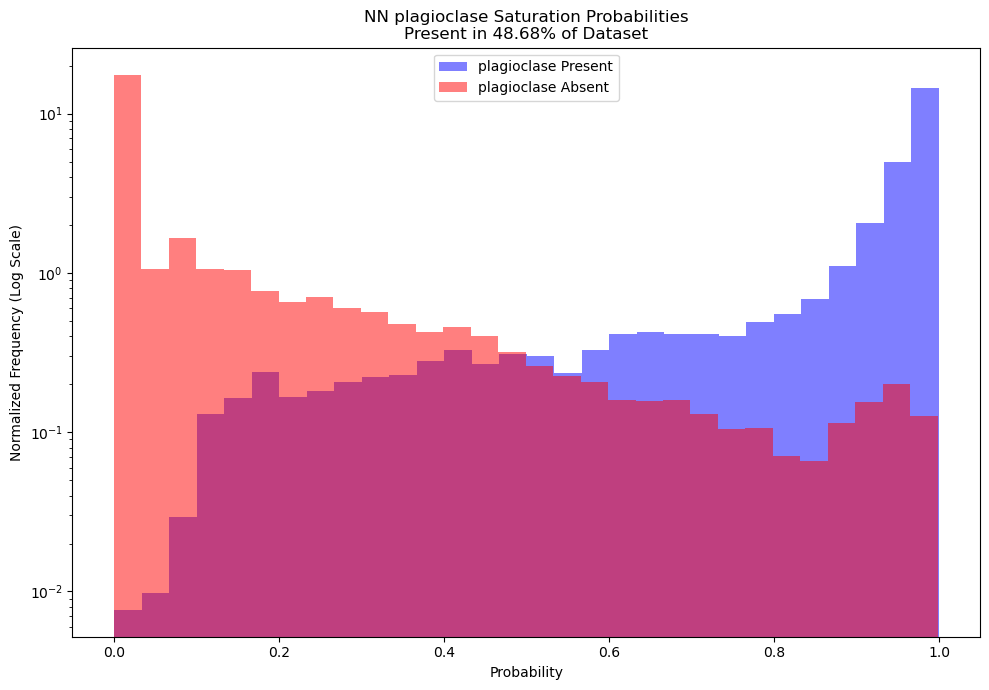

Model k-feldspar Precision of positive prediction: 92.55% 
Model k-feldspar Recall of dataset positives : 91.24%


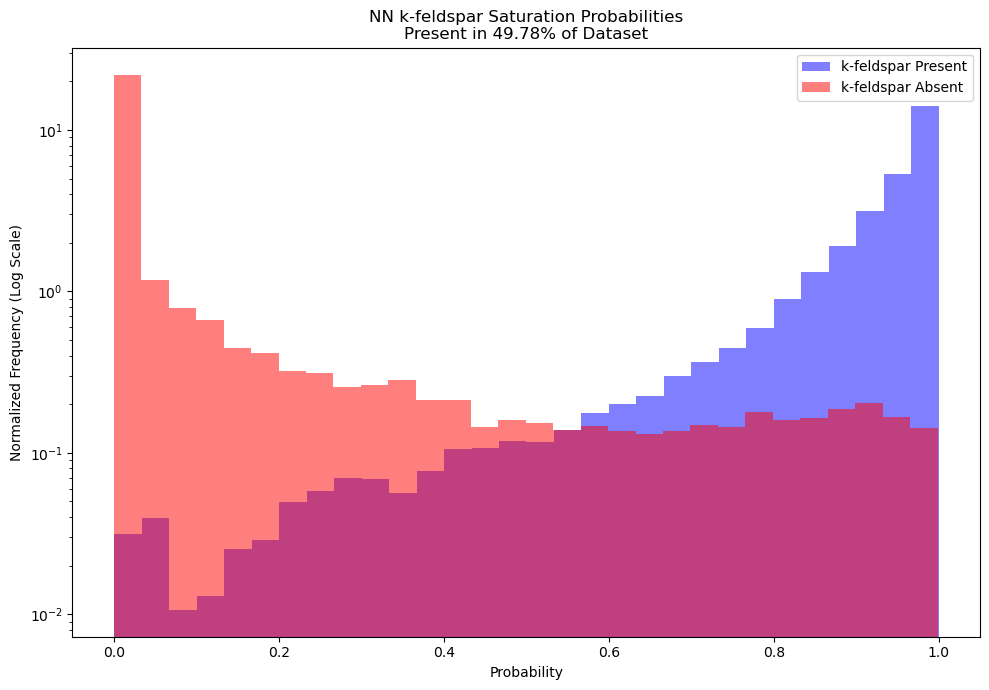

Model garnet Precision of positive prediction: 86.31% 
Model garnet Recall of dataset positives : 84.42%


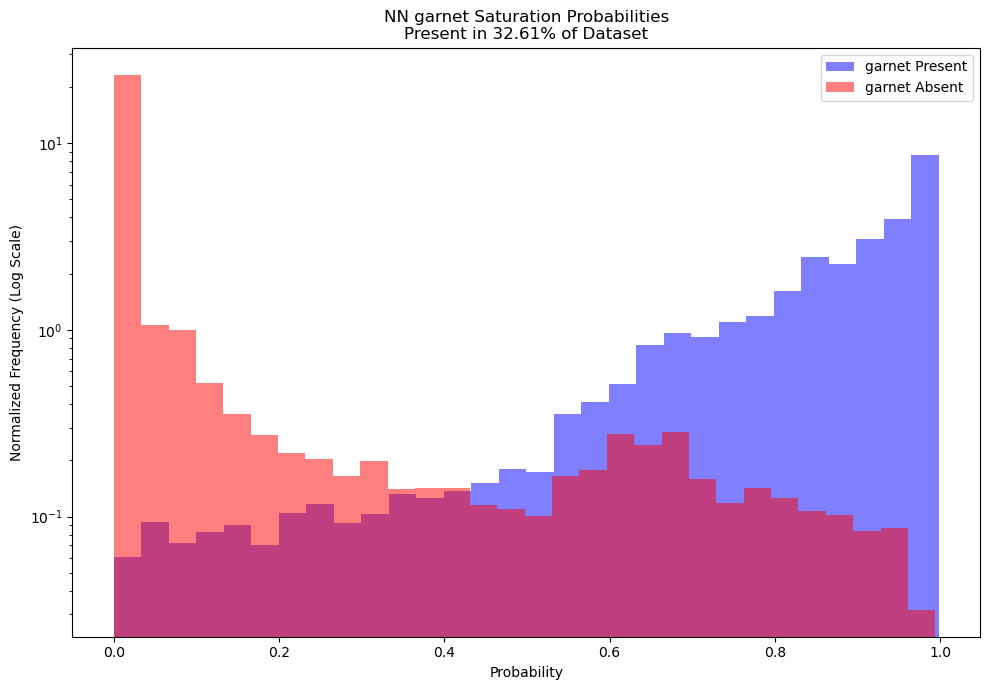

Model nepheline Precision of positive prediction: 97.73% 
Model nepheline Recall of dataset positives : 98.72%


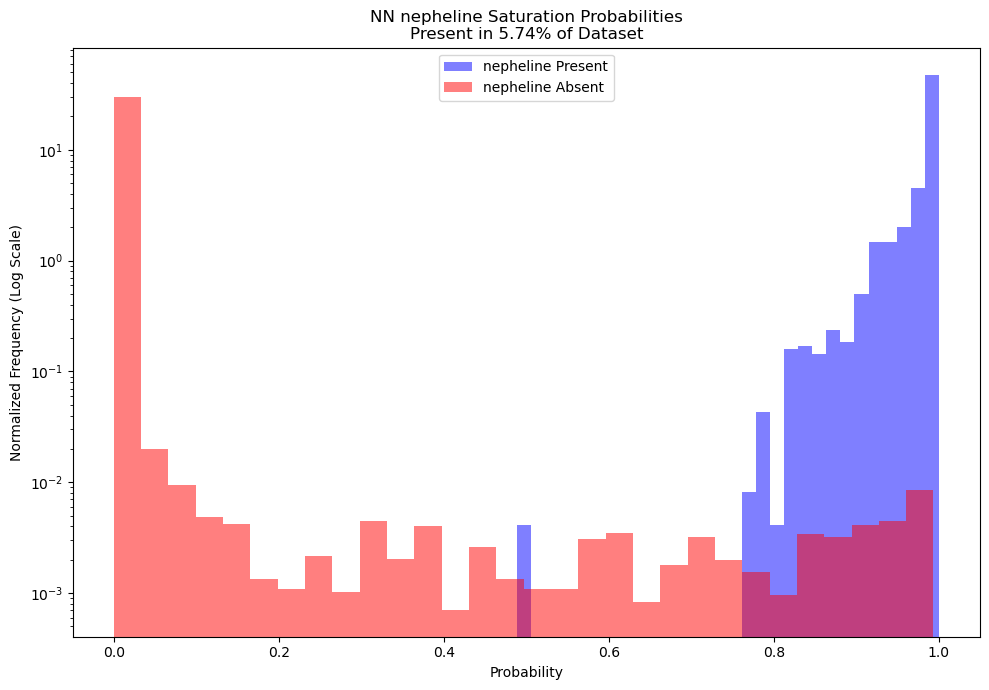

Model leucite Precision of positive prediction: 90.84% 
Model leucite Recall of dataset positives : 60.33%


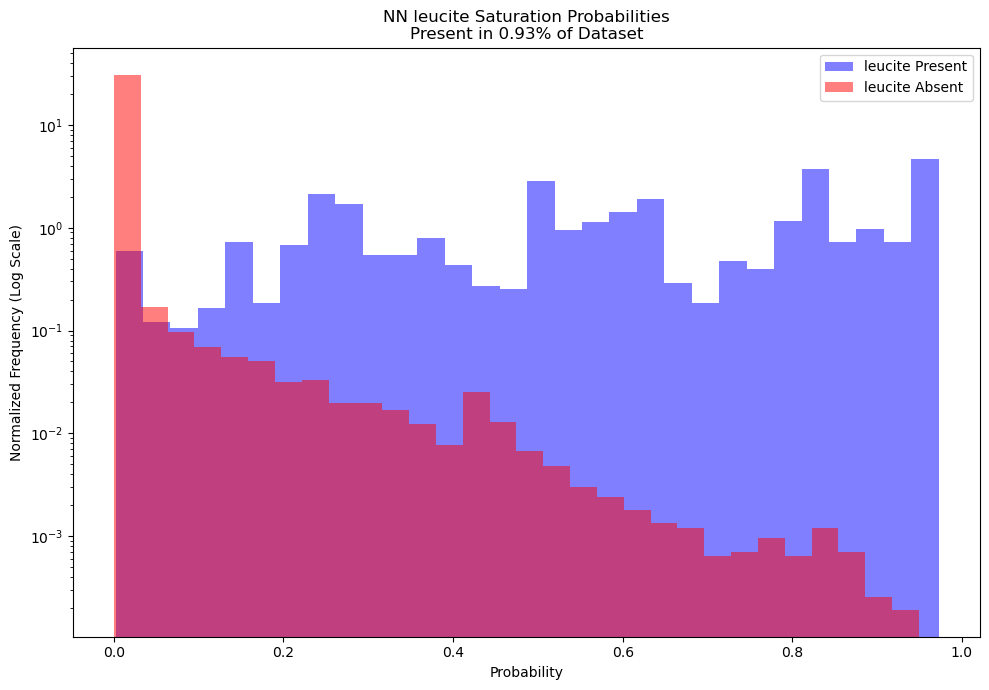

Model biotite Precision of positive prediction: 90.29% 
Model biotite Recall of dataset positives : 83.87%


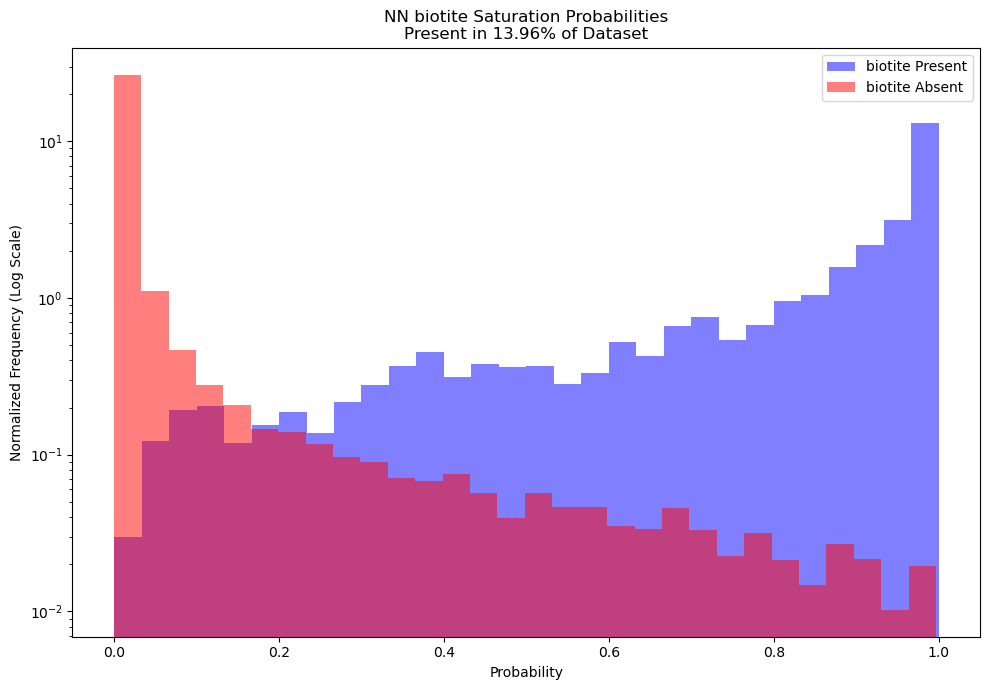

Model rhm-oxide Precision of positive prediction: 93.7% 
Model rhm-oxide Recall of dataset positives : 94.36%


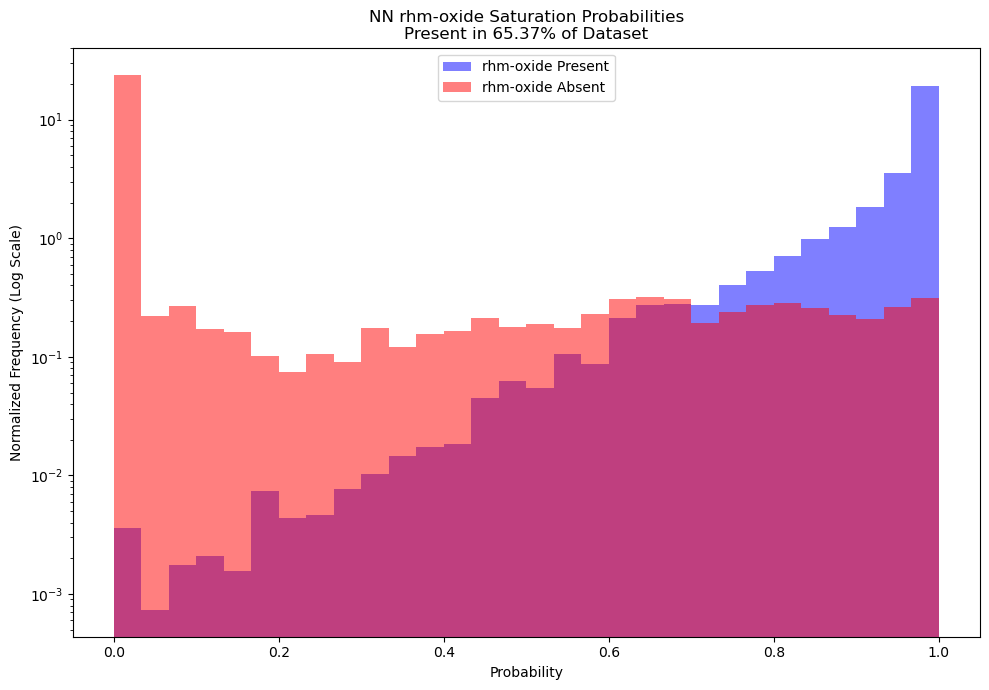

Model alloy-solid Precision of positive prediction: 71.7% 
Model alloy-solid Recall of dataset positives : 64.72%


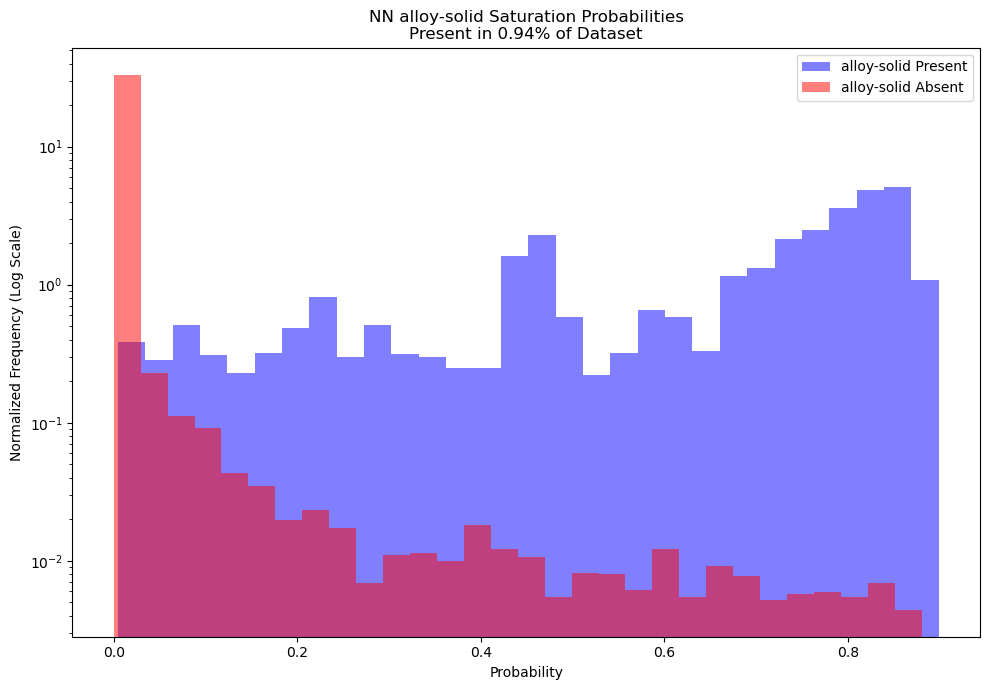

Model analcime Precision of positive prediction: 92.92% 
Model analcime Recall of dataset positives : 92.61%


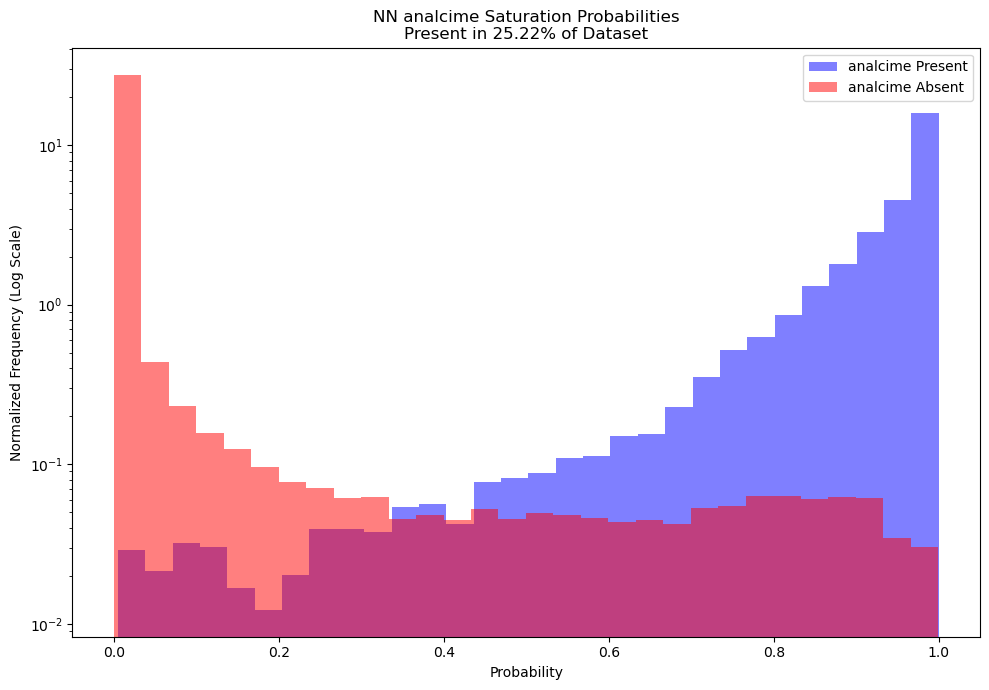

Model apatite Precision of positive prediction: 82.49% 
Model apatite Recall of dataset positives : 75.3%


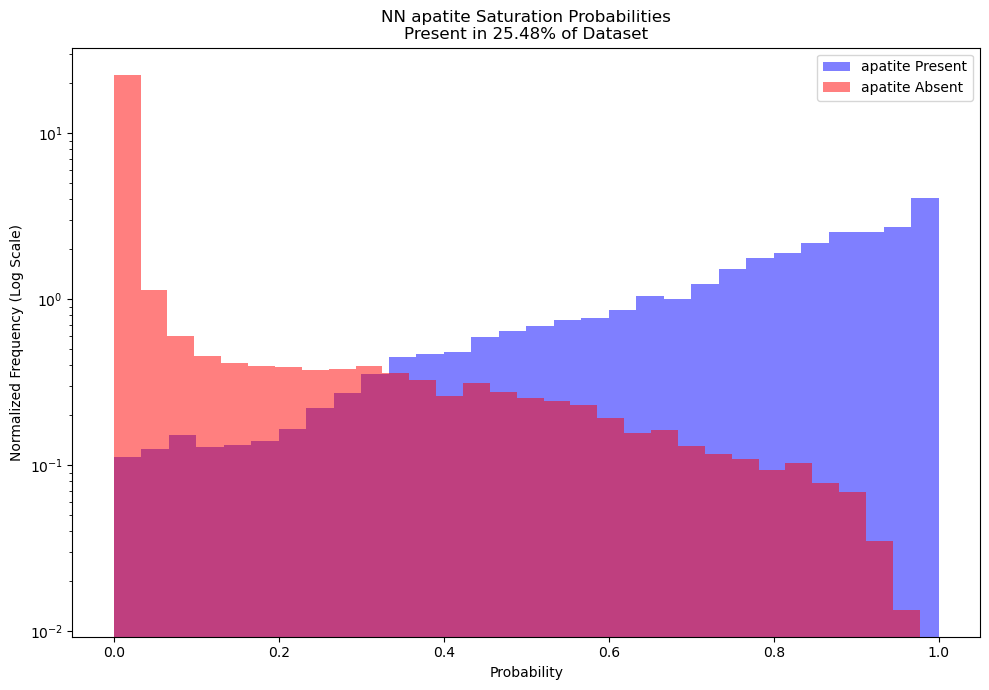

Model whitlockite Precision of positive prediction: 89.51% 
Model whitlockite Recall of dataset positives : 89.35%


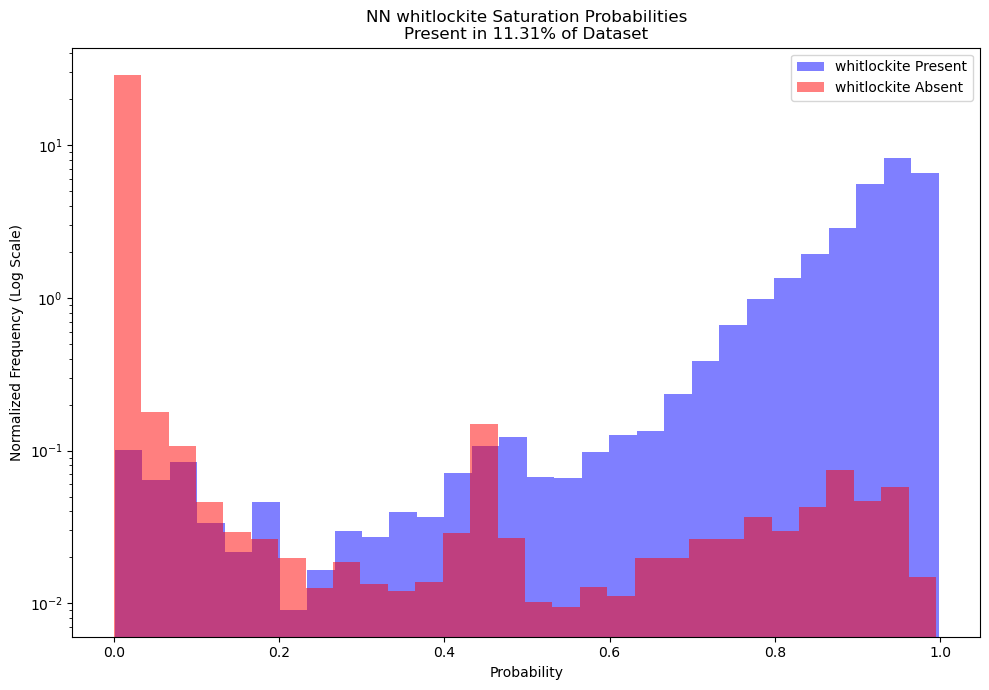

Model quartz Precision of positive prediction: 93.76% 
Model quartz Recall of dataset positives : 93.16%


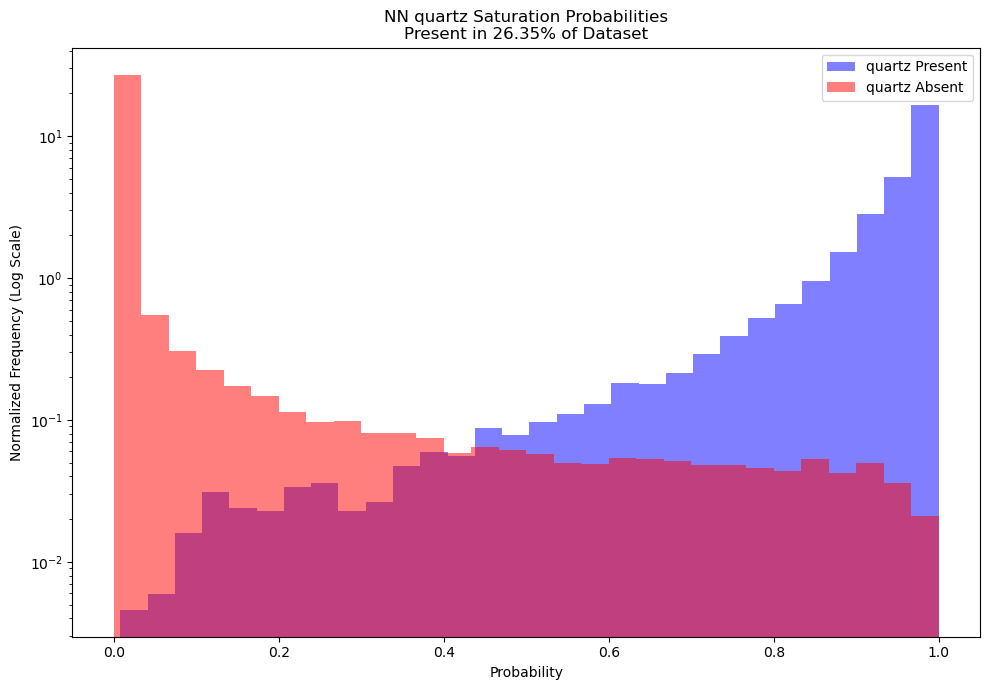

Model tridymite Precision of positive prediction: 90.7% 
Model tridymite Recall of dataset positives : 87.96%


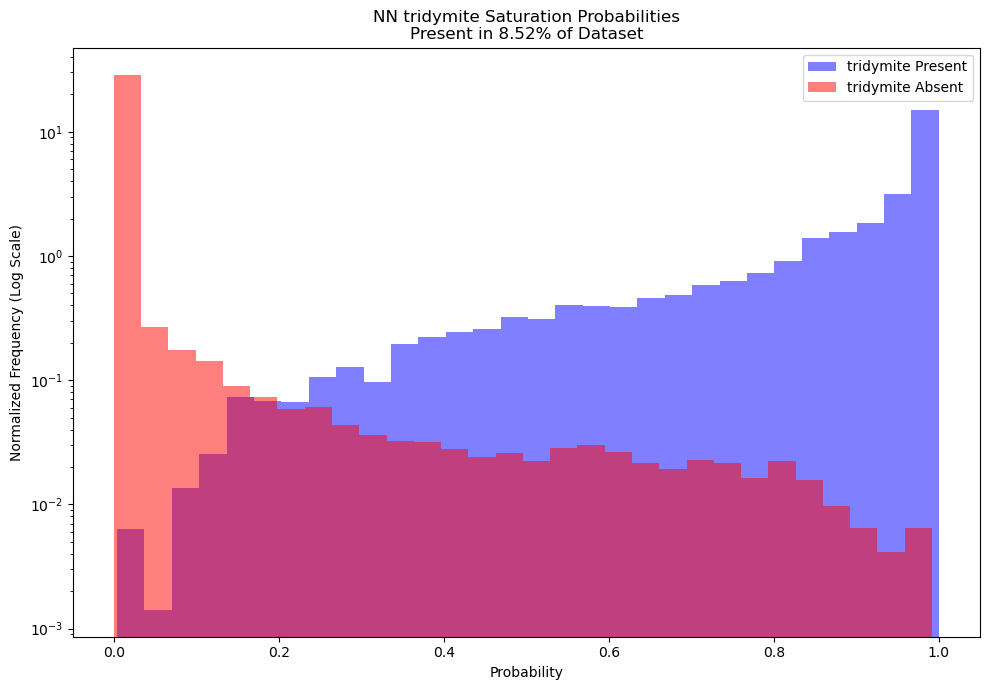

Model muscovite Precision of positive prediction: 91.11% 
Model muscovite Recall of dataset positives : 90.38%


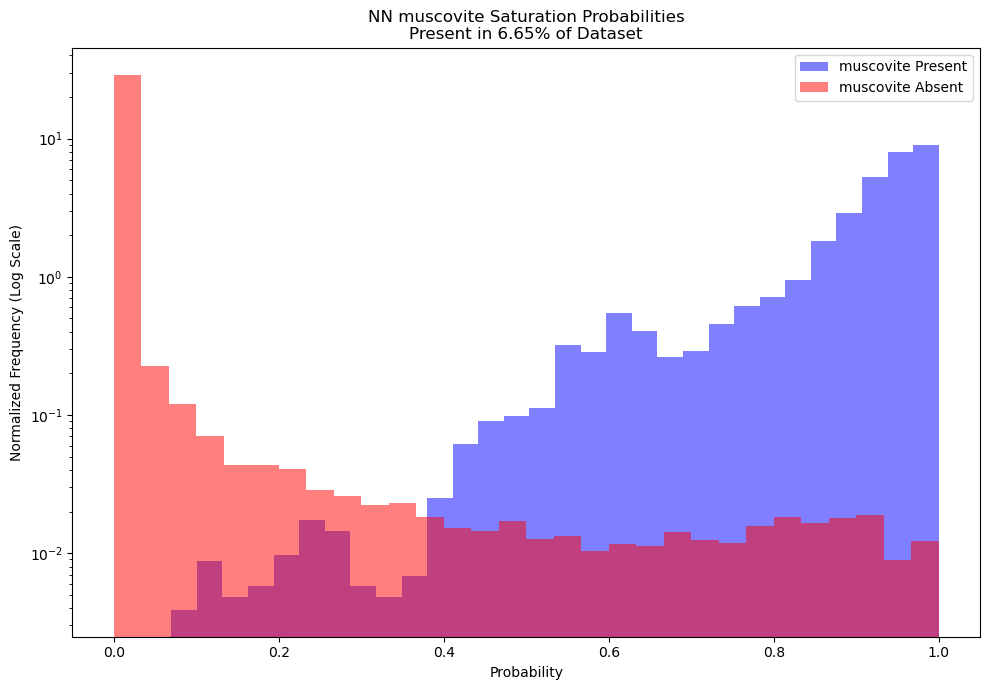

Model fluid Precision of positive prediction: 98.06% 
Model fluid Recall of dataset positives : 95.07%


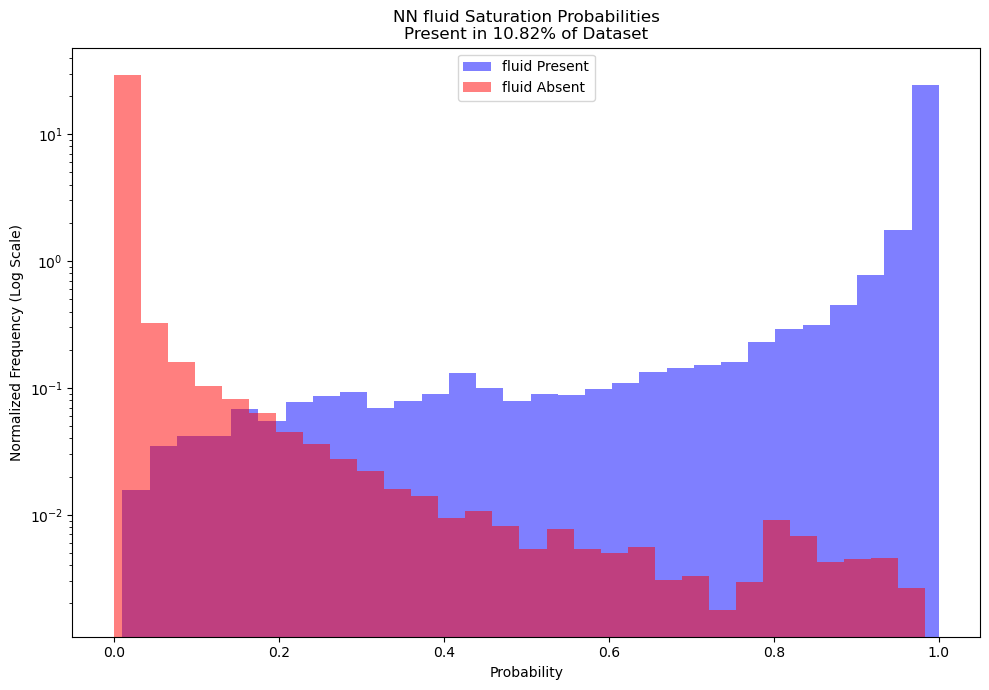

Model melts-liquid Precision of positive prediction: 100.0% 
Model melts-liquid Recall of dataset positives : 100.0%


c:\Users\dashf\anaconda3\envs\torch-env\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


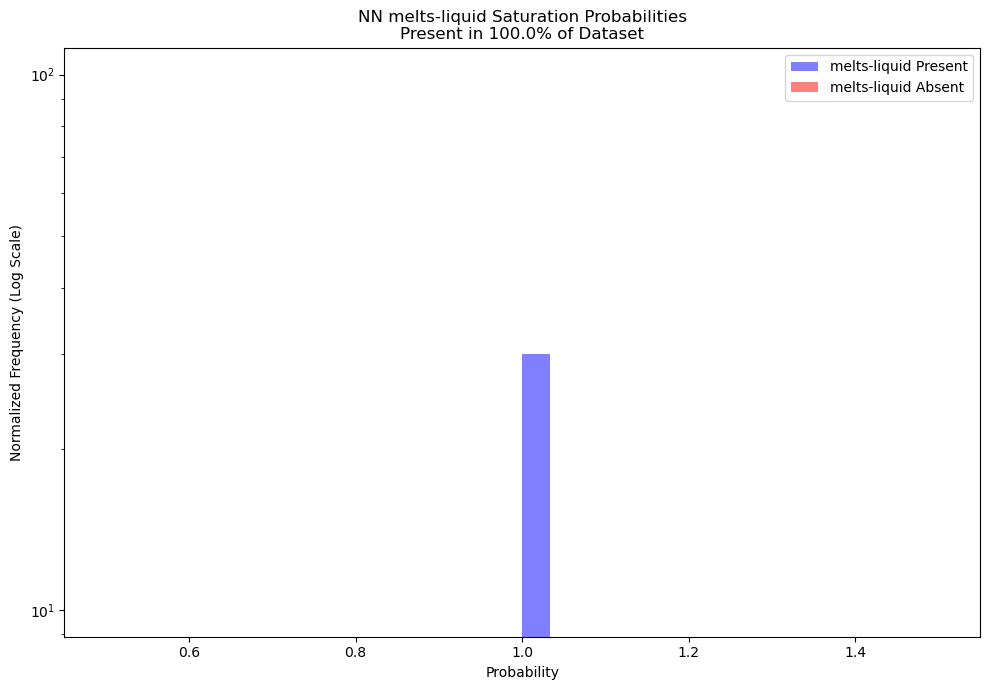

Model olivine Precision of positive prediction: 82.49% 
Model olivine Recall of dataset positives : 92.68%


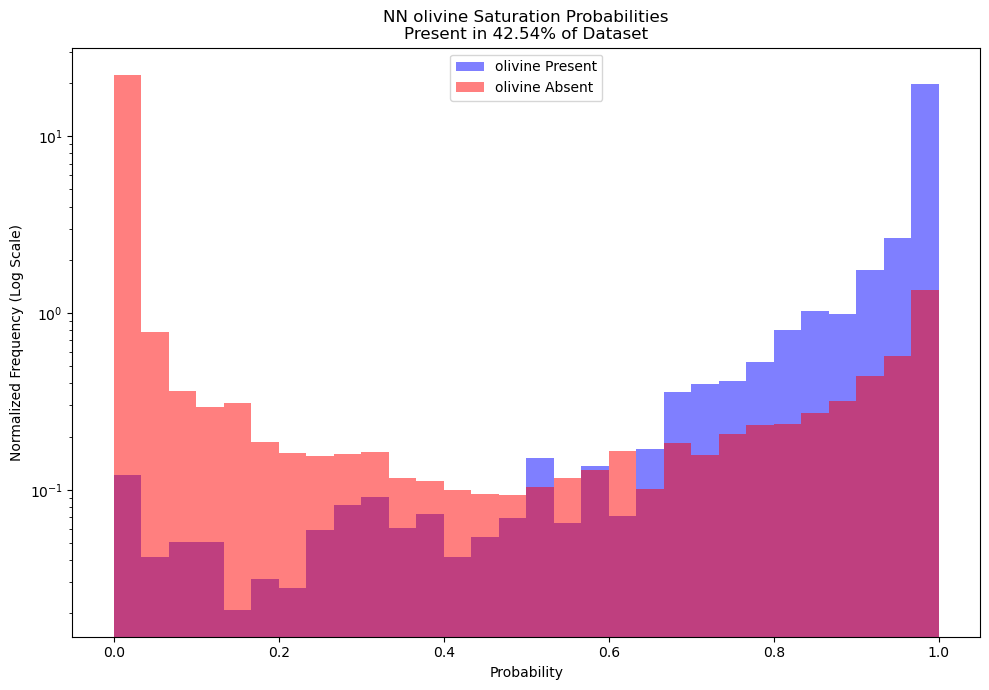

Model orthopyroxene Precision of positive prediction: nan% 
Model orthopyroxene Recall of dataset positives : 0.14%


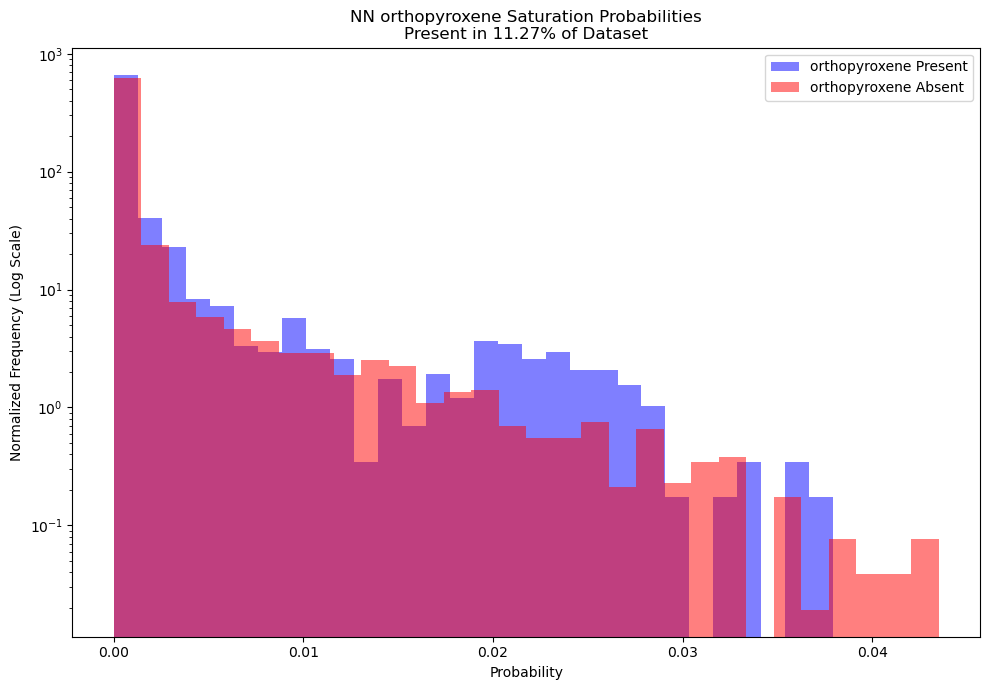

Model clinopyroxene Precision of positive prediction: 96.27% 
Model clinopyroxene Recall of dataset positives : 25.23%


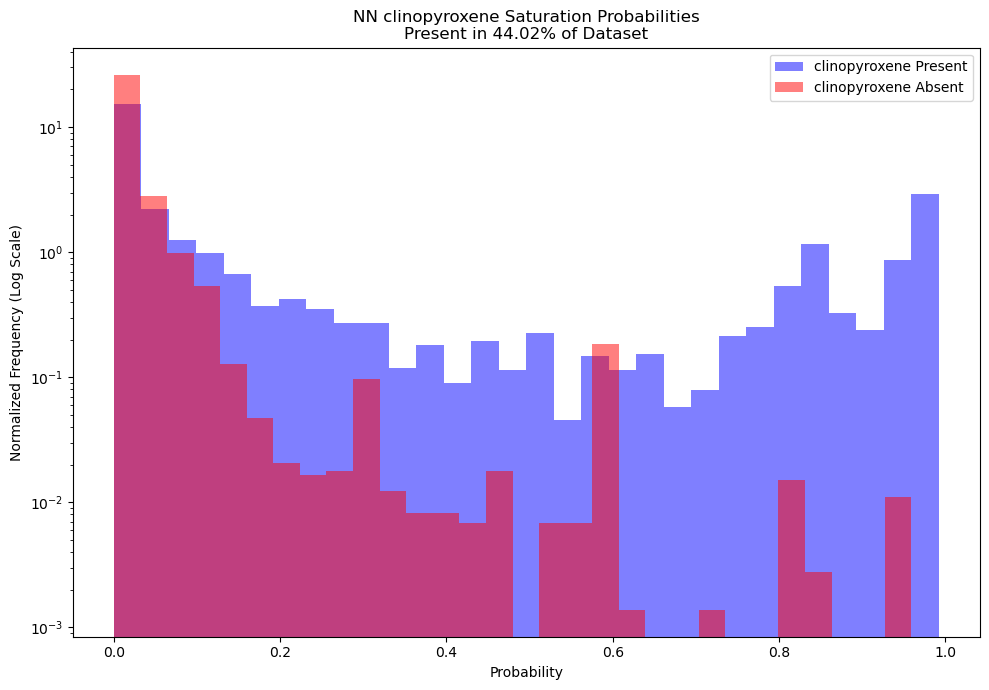

Model spinel Precision of positive prediction: 96.14% 
Model spinel Recall of dataset positives : 25.72%


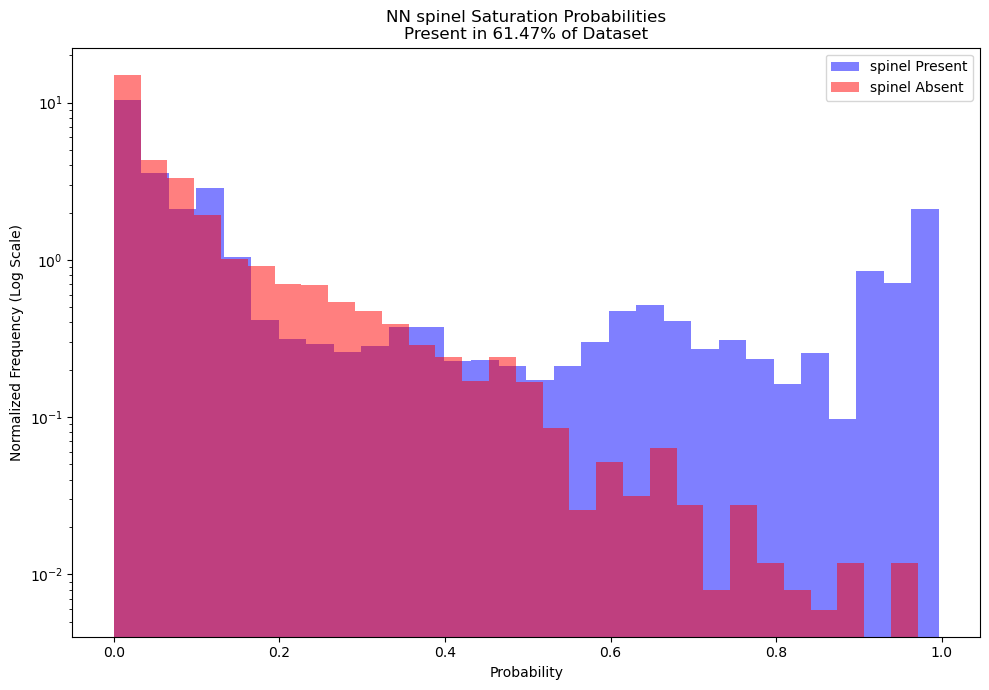

Model plagioclase Precision of positive prediction: 84.33% 
Model plagioclase Recall of dataset positives : 90.12%


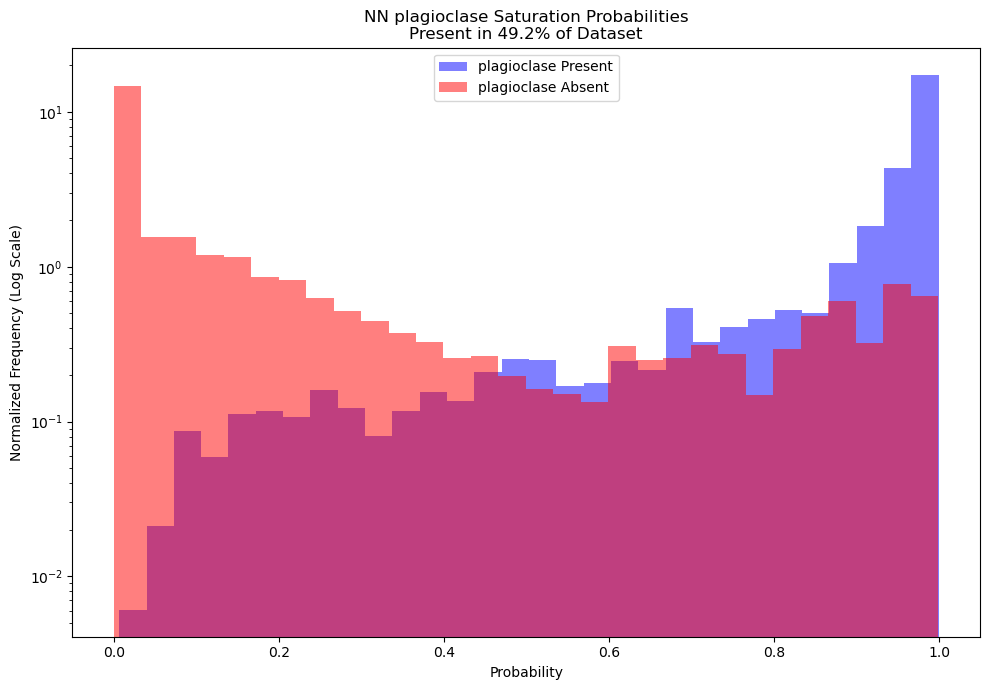

Model k-feldspar Precision of positive prediction: 90.25% 
Model k-feldspar Recall of dataset positives : 76.56%


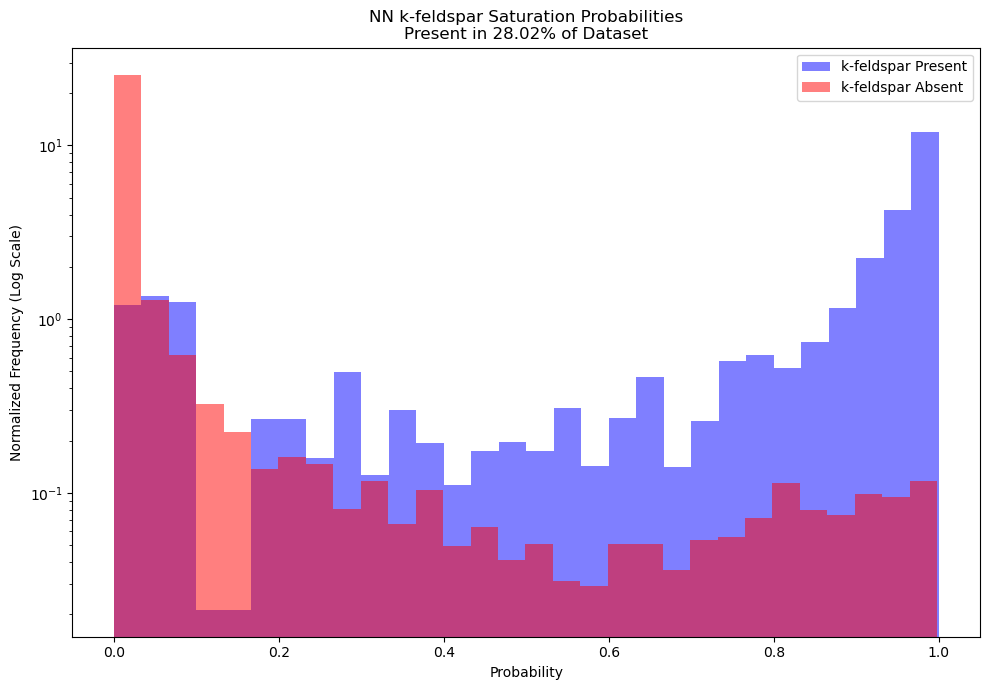

Model garnet Precision of positive prediction: 62.37% 
Model garnet Recall of dataset positives : 80.83%


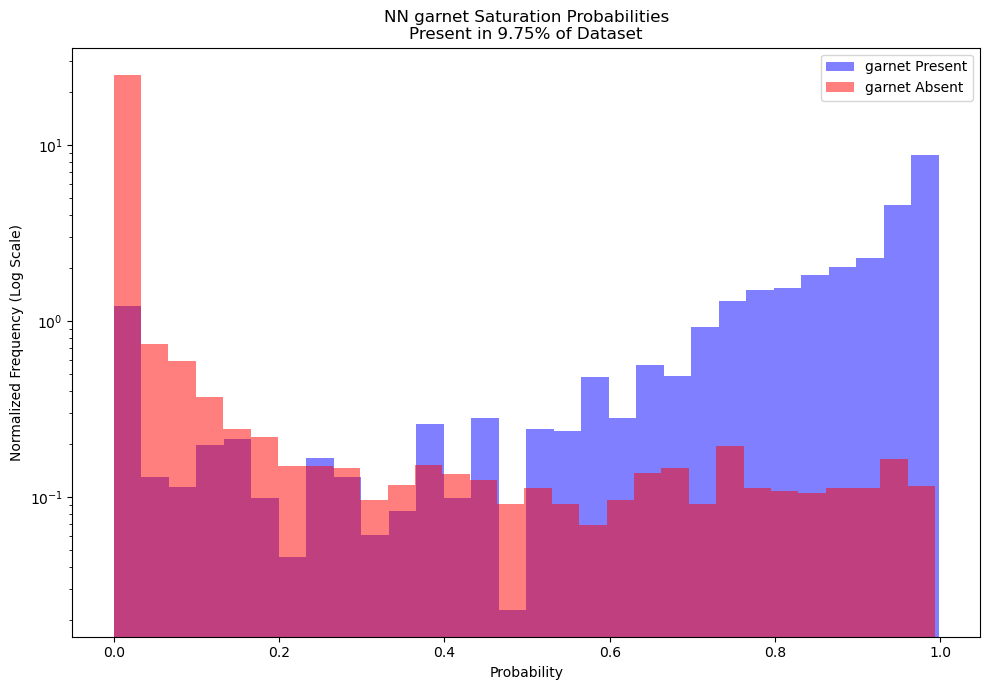

Model nepheline Precision of positive prediction: 88.14% 
Model nepheline Recall of dataset positives : 98.58%


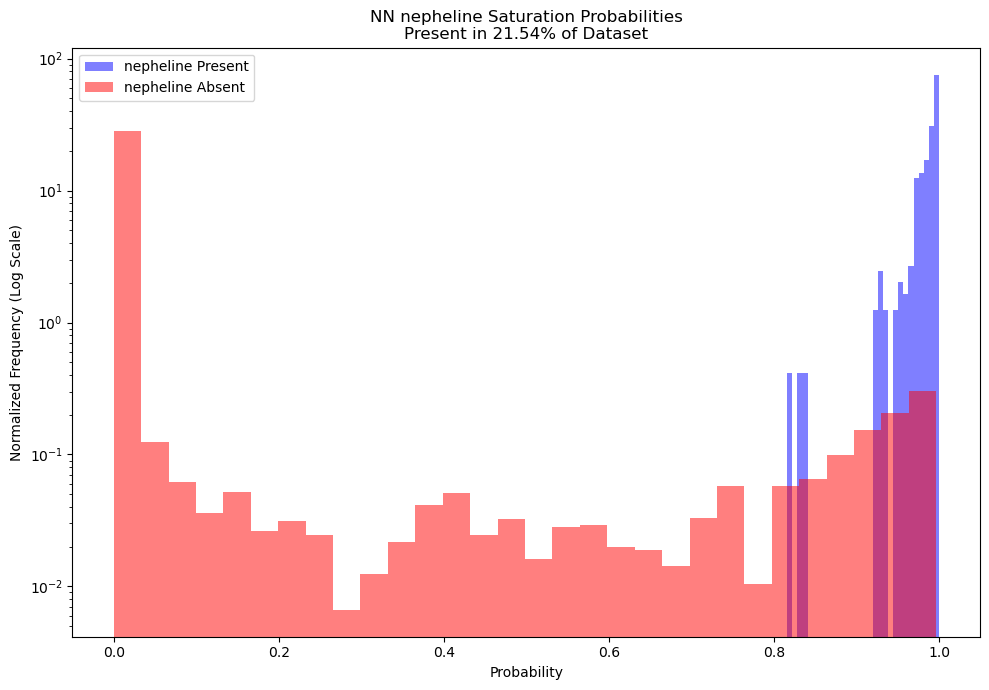

Model leucite Precision of positive prediction: 73.98% 
Model leucite Recall of dataset positives : 58.61%


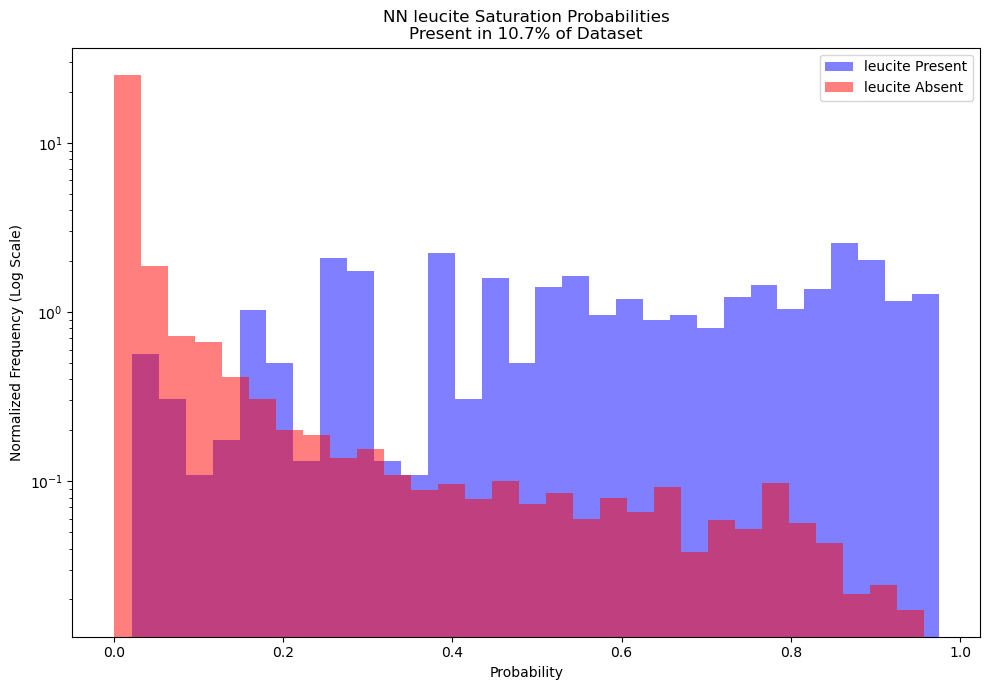

Model biotite Precision of positive prediction: 78.49% 
Model biotite Recall of dataset positives : 80.8%


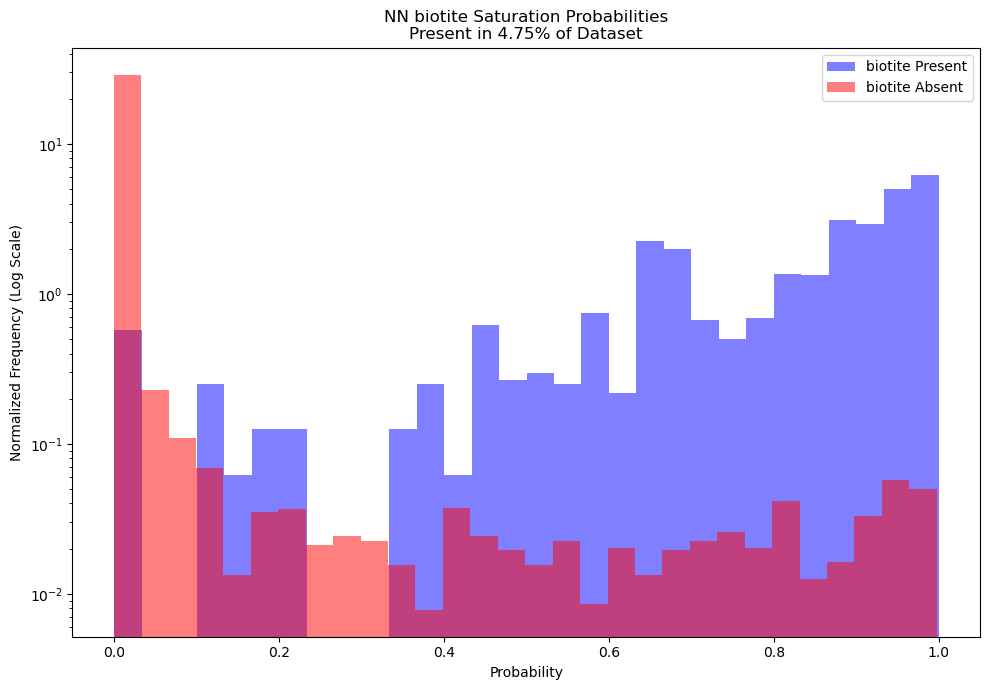

Model rhm-oxide Precision of positive prediction: 79.8% 
Model rhm-oxide Recall of dataset positives : 82.18%


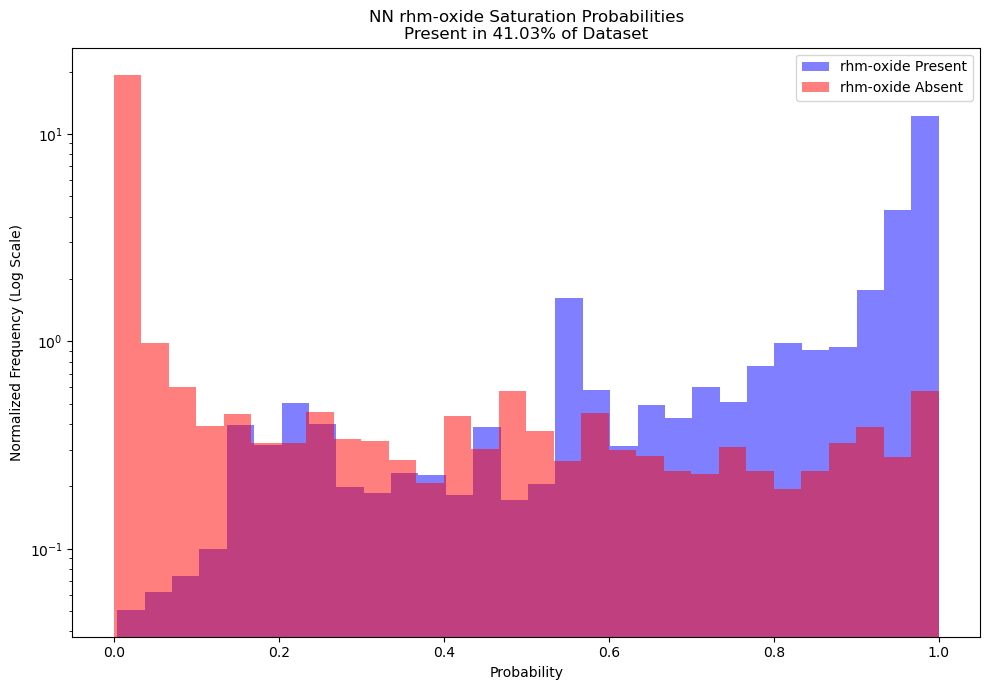

Model alloy-solid Precision of positive prediction: 47.83% 
Model alloy-solid Recall of dataset positives : 21.14%


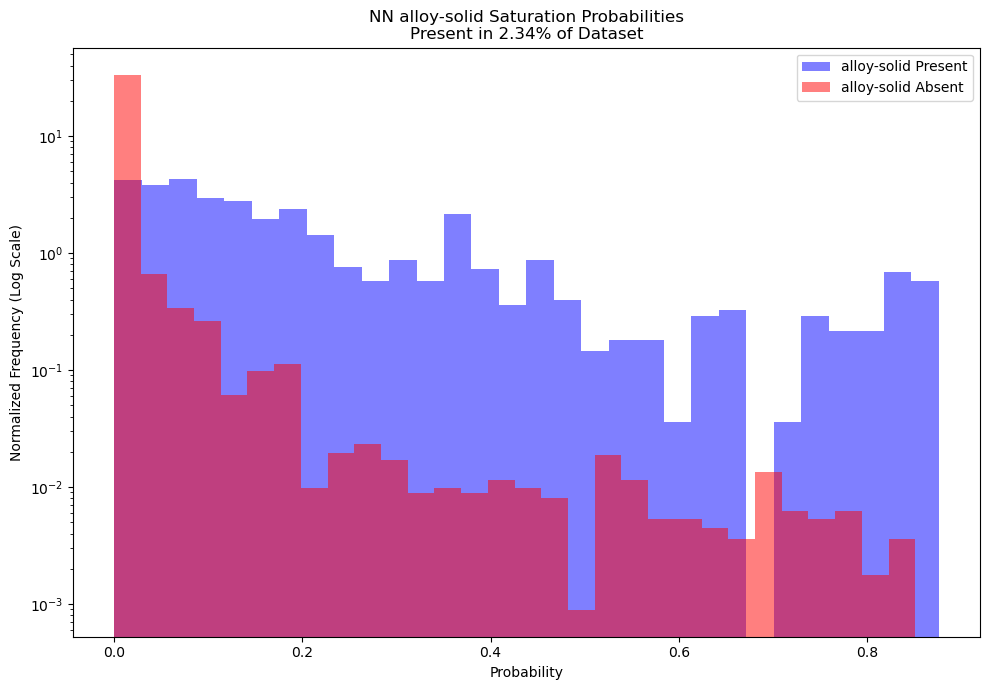

Model analcime Precision of positive prediction: 87.47% 
Model analcime Recall of dataset positives : 87.99%


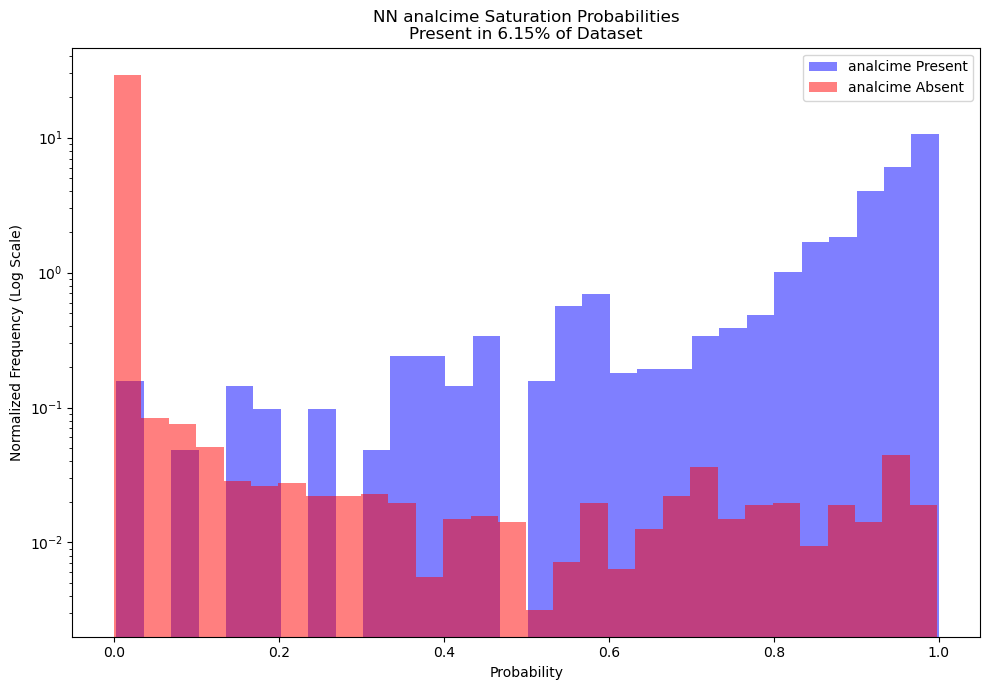

Model apatite Precision of positive prediction: 71.2% 
Model apatite Recall of dataset positives : 68.29%


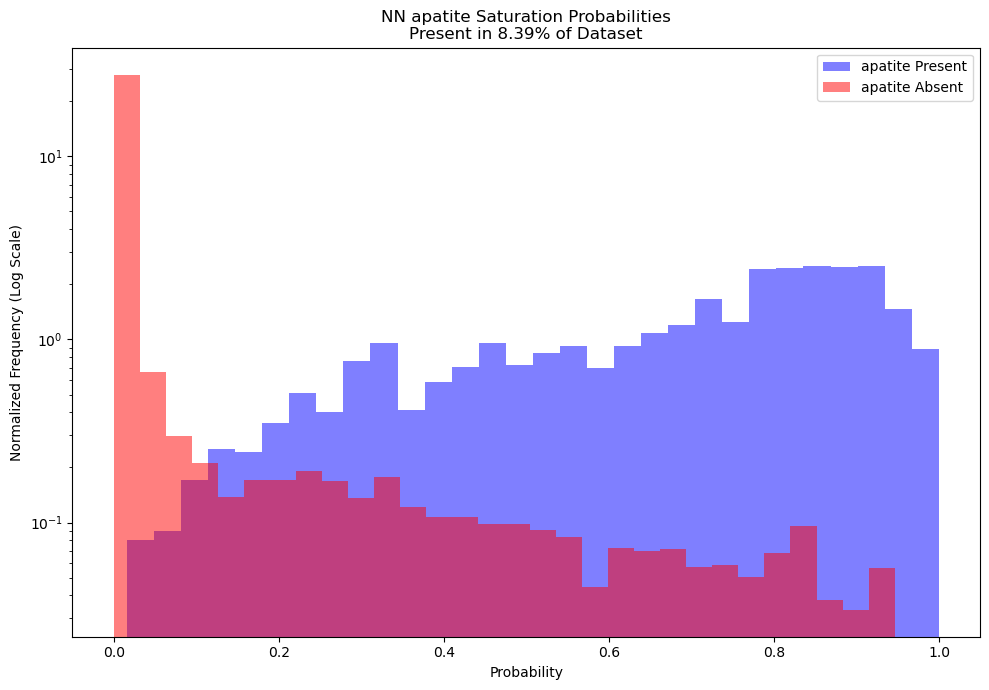

Model whitlockite Precision of positive prediction: 92.46% 
Model whitlockite Recall of dataset positives : 90.03%


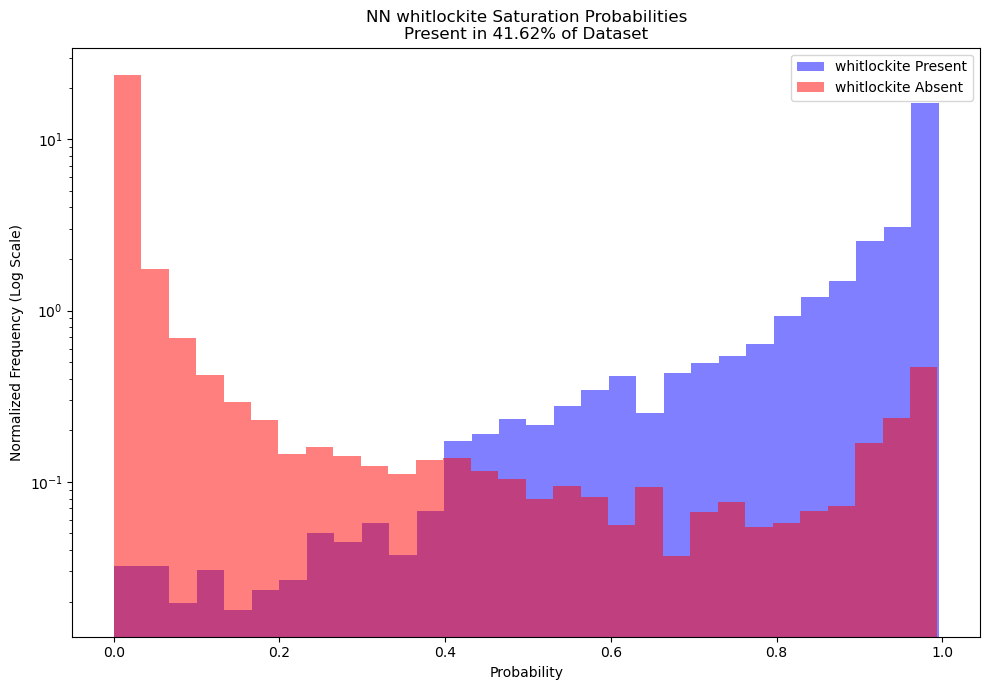

Model quartz Precision of positive prediction: 93.13% 
Model quartz Recall of dataset positives : 90.25%


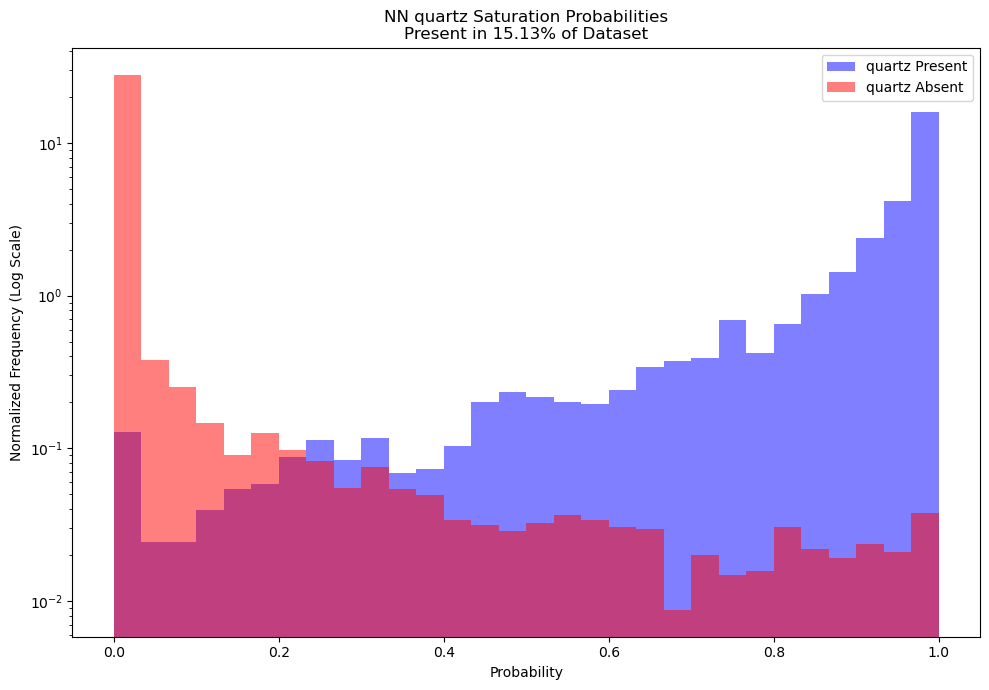

Model tridymite Precision of positive prediction: 88.22% 
Model tridymite Recall of dataset positives : 87.39%


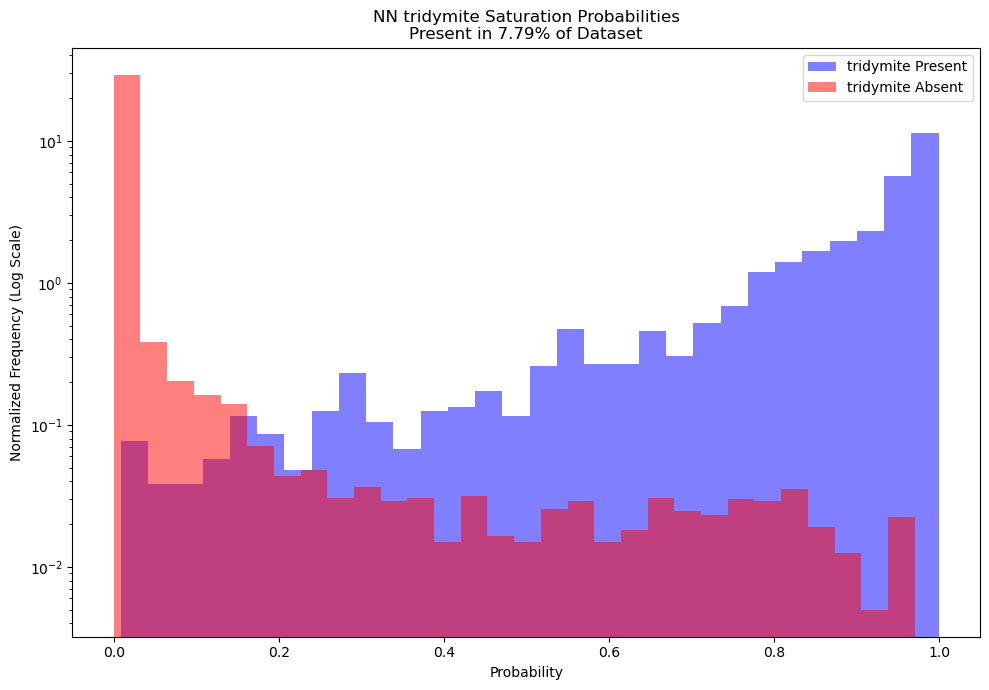

Model muscovite Precision of positive prediction: 88.8% 
Model muscovite Recall of dataset positives : 81.25%


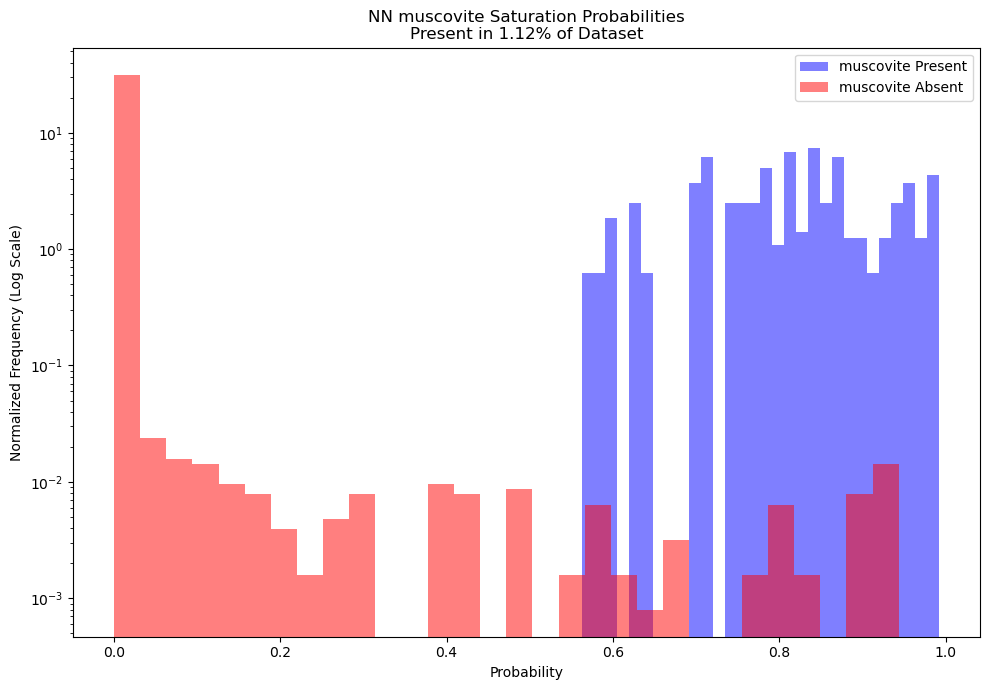

Model fluid Precision of positive prediction: 94.58% 
Model fluid Recall of dataset positives : 95.7%


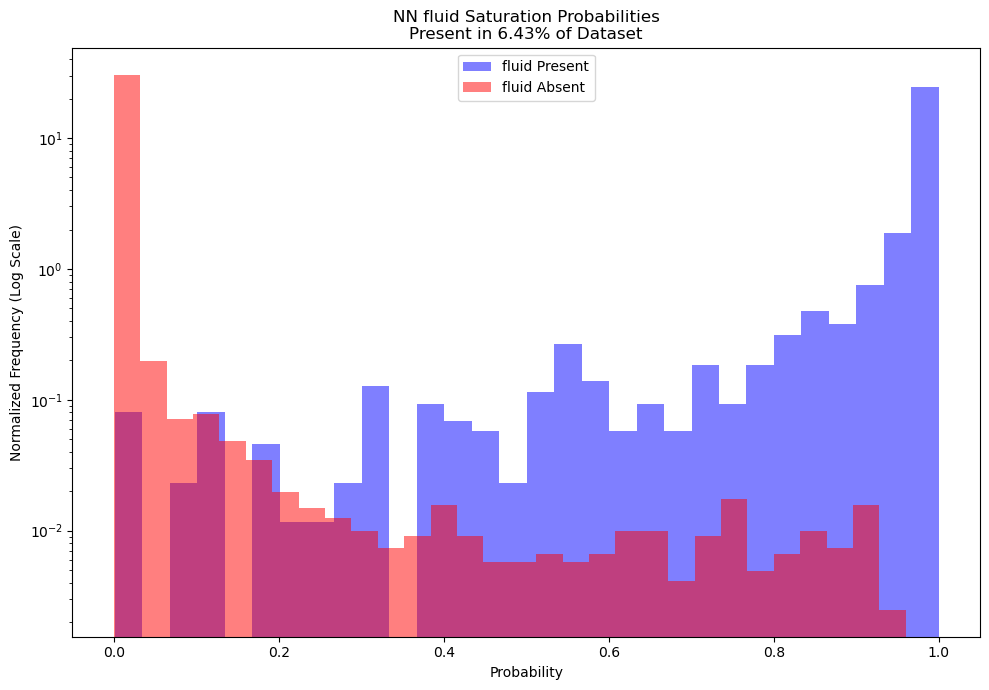

Model melts-liquid Precision of positive prediction: 100.0% 
Model melts-liquid Recall of dataset positives : 100.0%


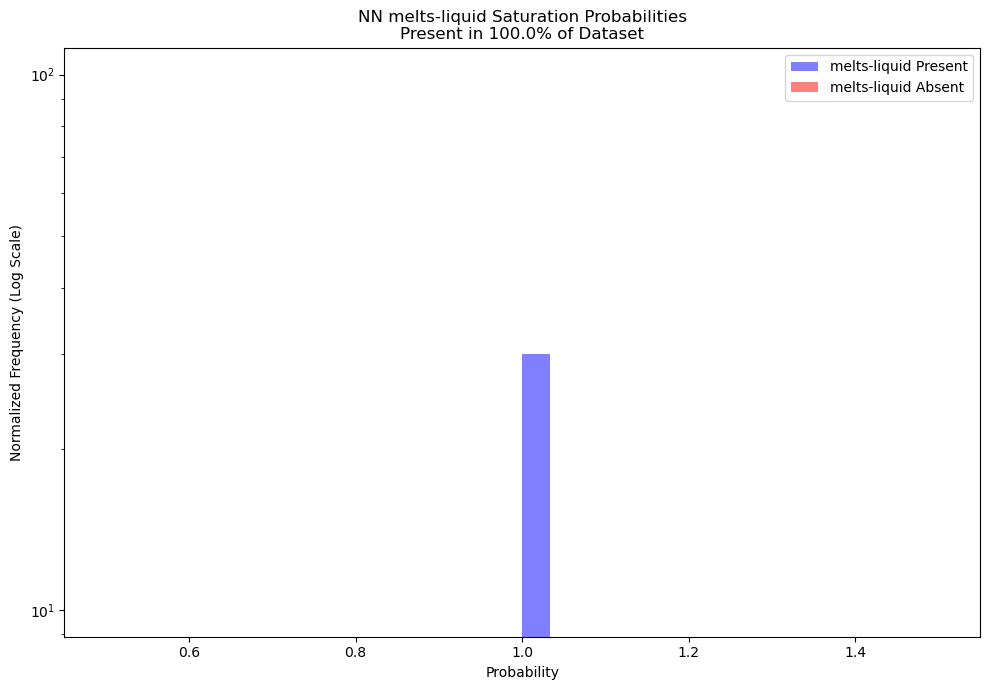

In [11]:
"""HYBRID NET Training loop for Binary Phase Saturation Model"""

criterion = nn.BCEWithLogitsLoss()  # suitable for multi-label classification
#criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.cuda())  # suitable for multi-label classification, weighting rare phases

device = 'cuda'

for i, (binary_train_set, binary_test_set) in enumerate([(binary_train_set_NoCr, binary_test_set_NoCr), (binary_train_set_Cr, binary_test_set_Cr)]):
    FullMELTS = DualSaturationChemistry().cuda()
    date = "Sept30" 
    modelname = "rhyoliteMELTS1.0.2Fxtal"
    DictFilePath=f"./{modelname}{['NoCr', 'Cr'][i]}_BinaryOnly_{date}.pt"
    #FullMELTS.load_state_dict(torch.load(DictFilePath), strict=False) #Warm Start
    #ictFilePath=f'./{modelname}_BinaryOnly0.0025noise_{date}.pt'
    
    batch_size = 1024
    binary_train_loader = DataLoader(binary_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    binary_test_loader = DataLoader(binary_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    
    for p in FullMELTS.parameters():
        p.requires_grad = True
    for p in FullMELTS.chem_heads.parameters():
        p.requires_grad = False
    for p in FullMELTS.mole_head.parameters():
        p.requires_grad = False

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min_binary = np.inf

    #EPOCHS = 50
    epoch = 0
    improve_record = [1,1]
    lrs = np.logspace(-8,-4,9).tolist() 
    #lrs = np.logspace(-7,-3,9).tolist() 

    lr = lrs.pop()
    wd = 0#1E-4
    optimizer = Adam(FullMELTS.parameters(), lr=lr, weight_decay=wd)

    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while lr > 2E-7:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(binary_train_loader)

        print(f"\n--- Epoch {epoch+1} ---") #/{EPOCHS}

        for batch_idx, (x_batch, y_batch) in enumerate(tqdm(binary_train_loader, desc="Training", leave=False)):
            x_batch, y_batch = x_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)

            x_batch = x_batch + torch.randn_like(x_batch) * 0.0025 # Add Small Gaussian Noise to avoid overfitting during training

            optimizer.zero_grad()
            logits = FullMELTS.forward_binaries(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")

        avg_train_loss = running_train_loss / len(binary_train_set)


        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        with torch.no_grad():
            for batch_idx, (x_batch, y_batch) in enumerate(binary_test_loader):
                x_batch, y_batch = x_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
                logits = FullMELTS.forward_binaries(x_batch)
                loss = criterion(logits, y_batch)
                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())

        avg_test_loss = running_test_loss / len(binary_test_set)
        test_losses.append(avg_test_loss)
        print(f"Running Saturation Loss: {round(running_test_loss,4)}")
        if avg_test_loss <= valid_loss_min_binary:
            torch.save(FullMELTS.state_dict(), DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min_binary, avg_test_loss))
            valid_loss_min_binary = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-3:]) == 0:
            improve_record = [1,1]
            lr = lrs.pop()
            """if wd > 5*lr:
                wd = 5*lr"""
            print(f"No Improvement in 3 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = Adam(FullMELTS.parameters(), lr=lr, weight_decay=wd)

    # ---- Plotting ----
    plt.figure(figsize=(8, 5))
    plt.plot((epoch/len(train_losses))*(np.arange(len(train_losses))+1),train_losses, label='Train Loss')
    plt.plot((epoch/len(long_test_losses))*(np.arange(len(long_test_losses))+1), long_test_losses, label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss (BCEWithLogits)")
    plt.title("Phase Saturation Training and Test Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{modelname}_BinaryPhaseSatTrain_{date}.jpg", dpi = 256)
    plt.show()

    """Histograms of Binary Phase Saturation Probabilities"""

    directories = [f'{modelname}Binary_Phase_Saturation_Histograms_{date}_TRAIN',f'{modelname}Binary_Phase_Saturation_Histograms_{date}_TEST']
    for i, histogram_directory in enumerate(directories):

        if not os.path.exists(histogram_directory):
            os.makedirs(histogram_directory)
        if len([binary_train_set, binary_test_set][i]) > 500000:
            subset = np.random.choice(np.arange(0, len([binary_train_set, binary_test_set][i])), size=500000, replace=False)
        else:
            subset = np.arange(0, len([binary_train_set, binary_test_set][i]))

        Xtest, Ytest = ([binary_train_set, binary_test_set][i])[subset.tolist()]
        with torch.no_grad():
            Y_hat_test = torch.sigmoid(FullMELTS.forward_binaries(Xtest.to('cuda')))
            Y_hat_test = Y_hat_test.detach().cpu().numpy()
            Xtest = Xtest.detach().numpy()
            Ytest = Ytest.detach().numpy()
        gc.collect()
        with open(histogram_directory+'/PRstats.txt', 'w'): # Create blank file
            pass


        for i, phase in enumerate(list(label_indices.keys())):
            realPos = (Ytest[:,i] > 0.5)
            predPos = (Y_hat_test[:,i] > 0.5).astype(float)
            precision = Ytest[predPos.astype(bool),i].sum()/np.sum(predPos)
            recall = Y_hat_test[realPos.astype(bool),i].sum()/np.sum(realPos)
            with open(histogram_directory+'/PRstats.txt', 'a') as File: #Record Stats
                File.write(f"Model {phase} Precision of positive prediction: {round(100*precision,2)}\n")
                File.write(f"Model {phase} Recall of dataset positives : {round(100*recall,2)}%\n")
            print(f"Model {phase} Precision of positive prediction: {round(100*precision,2)}% ")
            print(f"Model {phase} Recall of dataset positives : {round(100*recall,2)}%")
            plt.hist(Y_hat_test[realPos.astype(bool),i], bins=30, alpha=0.5, color = 'blue', label=f'{phase} Present', density=True, log = True)
            plt.hist(Y_hat_test[~(realPos.astype(bool)),i], bins=30, alpha=0.5, color = 'red', label=f'{phase} Absent', density=True, log = True)
            #plt.axvline(x=3, color='r', linestyle='dashed', linewidth=1)
            plt.legend()
            plt.xlabel("Probability")
            plt.ylabel("Normalized Frequency (Log Scale)")
            plt.title(f"NN {phase} Saturation Probabilities\nPresent in {round(100*realPos.sum()/len(Ytest),2)}% of Dataset")
            plt.tight_layout()
            plt.savefig(histogram_directory+f"/{phase}_Saturation_Probability_Histogram")
            plt.show()

In [12]:
#Chem and Mole head training. NoBulk, frozen encodings
#torch.autograd.set_detect_anomaly(False)

weight_dict_both = {
    'olivine': 3,
    'nepheline': 15,
    'leucite': 10,
    'alloy-solid': 5,
    'muscovite': 3,
    'k-feldspar': 5
}
# This overprints the above weights, does not apply to NoCr model
weight_dict_Cr = {
    'rhm-oxide': 5
}

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
for phase, W in weight_dict_both.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    binWeightsNoCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W
        compWeightsNoCr[:,comp_phasedict[phase]] = W
for phase, W in weight_dict_Cr.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W


for i, (full_train_set, full_test_set) in enumerate([(full_train_set_NoCr, full_test_set_NoCr), (full_train_set_Cr, full_test_set_Cr)]):

    FullMELTS = DualSaturationChemistry().cuda()
    #date = "Sept30"
    #modelname = "rhyoliteMELTS1.0.2Fxtal"
    DictFilePath=f"./{modelname}{['NoCr', 'Cr'][i]}_BinaryOnly_{date}.pt"
    #DictFilePath=f'./{modelname}_ChemMoleL2_{date}.pt'
    
    FullMELTS.load_state_dict(torch.load(DictFilePath),strict = False)
    
    #date = "Sept22" + ['NoCr', 'Cr'][i]
    DictFilePath=f"./{modelname}{['NoCr', 'Cr'][i]}_ChemMoleL2_{date}.pt"
    
    
    
    batch_size = 1024

    device = 'cuda'

    binWeights = ([binWeightsNoCr, binWeightsCr][i]).to(device)
    compWeights = ([compWeightsNoCr, compWeightsCr][i]).to(device)
    
    train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # All but mole heads: Put those on top.
    for p in FullMELTS.parameters():
        p.requires_grad = True
    #for p in FullMELTS.mole_head.parameters():
    #    p.requires_grad = False
    for p in FullMELTS.encoder.parameters():
        p.requires_grad = False
        
        
    criterion_sat = torch.nn.BCEWithLogitsLoss(weight = binWeights)
    criterion_chem = symmetric_rel_l2 #relative_L1_loss #y_pred, y_true, mask=None, eps=1e-6 #criterion_chem = F.mse_loss 
    criterion_mole = symmetric_rel_l2
    criterion_bulk = symmetric_rel_l2
    
    chem_alpha = 1 
    mole_alpha = 1
    bulk_alpha = 0 # For now, guassian noise in bulk
    

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min = np.inf


    epoch = 0
    improve_record = [1,1]
    lrs = np.logspace(-7,-3,9).tolist()
    lr = lrs.pop()
    wd = 1E-5
    optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)

    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while (lr > 2E-7):
    #while lr > 2E-25:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(train_loader)

        print(f"\n--- Epoch {epoch} ---") #/{EPOCHS}

        for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc="Training", leave=False)):

            optimizer.zero_grad()

            x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
            
            bulk_zero_mask = (x_batch != 0).to(torch.float)
            x_batch = x_batch + torch.randn_like(x_batch) * 0.002 * bulk_zero_mask # Add Small Gaussian Noise to avoid overfitting during training

            logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)

            # Binary saturation loss
            loss_sat = criterion_sat(logits, b_batch)

            # Chemistry and mass losses: apply masks
            chem_loss_raw = criterion_chem(chem_preds, y_batch)
            mole_loss_raw = criterion_mole(mole_preds, m_batch)
            bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
            mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach() # Only use binary preds for masking when those neurons are free
            mole_zero_mask = (b_batch > 0.5).to(torch.float).detach()
     
            chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
            mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
            bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask[:,3:]).sum() / (bulk_zero_mask[:,3:]).sum().clamp(min=1)
            
            
            loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
            #print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}")

            if not torch.isfinite(loss):
                print("Non-finite loss detected!")
                print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}, Mole loss: {mole_loss_masked}, Bulk loss: {bulk_loss_masked}")
                continue

            loss.backward()


            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")


        avg_train_loss = running_train_loss / len(full_train_set)

        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        
        with torch.no_grad():
            for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(test_loader):
                x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
                logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)
                
                # Binary saturation loss
                loss_sat = criterion_sat(logits, b_batch)
                running_sat_loss += loss_sat.item()
                
                # Chemistry losses: apply masks
                chem_loss_raw = criterion_chem(chem_preds, y_batch)
                mole_loss_raw = criterion_mole(mole_preds, m_batch)
                bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
                bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
                mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach()
                #mole_zero_mask = (b_batch > 0.5).to(torch.float)
                
                chem_loss_masked = (chem_loss_raw * chem_zero_mask).sum() / chem_zero_mask.sum().clamp(min=1)
                mole_loss_masked = (mole_loss_raw * mole_zero_mask).sum() / mole_zero_mask.sum().clamp(min=1)
                bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
                
                running_mole_loss += mole_loss_masked.item()
                running_chem_loss += chem_loss_masked.item()
                running_bulk_loss += bulk_loss_masked.item()
                
                # Total loss
                #loss = loss_sat + chem_alpha*chem_loss_masked
                #loss = mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                

                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())


        print(f"Running Saturation Loss: {round(running_sat_loss,4)}\nRunning Chem Loss: {round(running_chem_loss,4)}")
        print(f"Running Molar Loss: {round(running_mole_loss,4)}\nRunning Bulk Loss: {round(running_bulk_loss,4)}")
        
        avg_test_loss = running_test_loss / len(full_test_set)
        test_losses.append(avg_test_loss)
        if avg_test_loss <= valid_loss_min:
            torch.save(FullMELTS.state_dict(), DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, avg_test_loss))
            valid_loss_min = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-3:]) == 0:
            improve_record = [1,1]
            lr = lrs.pop()
            #if wd > 5*lr:
            #    wd = 5*lr
            print(f"No Improvement in 3 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)#Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        #Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        
        #break

C:\Users\dashf\AppData\Local\Temp\ipykernel_54196\4233018467.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  FullMELTS.load_state_dict(torch.load(DictFilePath),strict =


--- Epoch 1 ---


Training:   0%|          | 4/3247 [00:19<3:16:29,  3.64s/it] 

[  0.0%] Batch     0 Loss: 0.1269


Training:   6%|▋         | 206/3247 [00:26<01:45, 28.90it/s]

...

Training:  69%|██████▊   | 604/879 [00:50<00:15, 18.11it/s]

[ 68.3%] Batch   600 Loss: 0.1811


Training:  91%|█████████▏| 804/879 [01:00<00:03, 19.48it/s]

[ 91.0%] Batch   800 Loss: 0.1849


Running Saturation Loss: 27.2064
Running Chem Loss: 0.1653
Running Molar Loss: 0.0031
Running Bulk Loss: 0.0647
Epoch 26 | Train Loss: 0.175485 | Test Loss: 0.687530
[TIMER] Epoch time: 84.41 seconds
No Improvement in 3 epochs. New LR: 1e-07. New Weight Decay: 1e-05


In [13]:
#FULL model with Bulk and custom phase weights
#torch.autograd.set_detect_anomaly(False)

weight_dict_both = {
    'olivine': 3,
    'nepheline': 15,
    'leucite': 10,
    'alloy-solid': 5,
    'muscovite': 3,
    'k-feldspar': 5
}
# This overprints the above weights, does not apply to NoCr model
weight_dict_Cr = {
    'rhm-oxide': 3
}

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
for phase, W in weight_dict_both.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    binWeightsNoCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W
        compWeightsNoCr[:,comp_phasedict[phase]] = W
for phase, W in weight_dict_Cr.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W


for i, (full_train_set, full_test_set) in enumerate([(full_train_set_NoCr, full_test_set_NoCr), (full_train_set_Cr, full_test_set_Cr)]):
    #if i == 0:
    #   continue
    FullMELTS = DualSaturationChemistry().cuda()
    #date = "Sept30" 
    #modelname = "rhyoliteMELTS1.0.2Fxtal"
    DictFilePath=f"./{modelname}{['NoCr', 'Cr'][i]}_ChemMoleL2_{date}.pt"

    FullMELTS.load_state_dict(torch.load(DictFilePath),strict = False)
    
    #date = "Sept25" + ['NoCr', 'Cr'][i]
    DictFilePath=f"./{modelname}{['NoCr', 'Cr'][i]}_FullL1_{date}.pt"
    
    
    
    batch_size = 1024

    device = 'cuda'

    binWeights = ([binWeightsNoCr, binWeightsCr][i]).to(device)
    compWeights = ([compWeightsNoCr, compWeightsCr][i]).to(device)
    
    train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # All 
    #Training only mole and Chem heads
    for p in FullMELTS.parameters():
        p.requires_grad = False

    for p in FullMELTS.mole_head.parameters():
        p.requires_grad = True

    for p in FullMELTS.chem_heads.parameters():
        p.requires_grad = True
        
    criterion_sat = torch.nn.BCEWithLogitsLoss(weight = binWeights)
    criterion_chem = symmetric_rel_l1 #relative_L1_loss #y_pred, y_true, mask=None, eps=1e-6 #criterion_chem = F.mse_loss 
    criterion_mole = symmetric_rel_l1
    criterion_bulk = symmetric_rel_l1
    
    chem_alpha = 1 #tried 1/30 last time
    mole_alpha = 1
    bulk_alpha = 0
    

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min = np.inf


    epoch = 0
    improve_record = [1,1]
    lrs = np.logspace(-7,-3,9).tolist()
    
    lr = lrs.pop()
    wd = 1E-5
    optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)

    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while (lr > 2E-7):
    #while lr > 2E-25:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(train_loader)

        print(f"\n--- Epoch {epoch} ---") #/{EPOCHS}

        for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc="Training", leave=False)):

            optimizer.zero_grad()

            x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
            
            bulk_zero_mask = (x_batch != 0).to(torch.float)
            #x_batch = x_batch + torch.randn_like(x_batch) * 0.003 * bulk_zero_mask # Add Small Gaussian Noise to avoid overfitting during training

            logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)

            # Binary saturation loss
            loss_sat = criterion_sat(logits, b_batch)

            # Chemistry and mass losses: apply masks
            chem_loss_raw = criterion_chem(chem_preds, y_batch)
            mole_loss_raw = criterion_mole(mole_preds, m_batch)
            bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
            #bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
            mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach() # Only use binary preds for masking when those neurons are free
            #mole_zero_mask = (b_batch > 0.5).to(torch.float).detach()
     
            chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
            mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
            bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
            
            
            loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
            #print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}")

            if not torch.isfinite(loss):
                print("Non-finite loss detected!")
                print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}, Mole loss: {mole_loss_masked}, Bulk loss: {bulk_loss_masked}")
                continue

            loss.backward()


            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")


        avg_train_loss = running_train_loss / len(full_train_set)

        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        
        with torch.no_grad():
            for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(test_loader):
                x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
                logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)
                
                # Binary saturation loss
                loss_sat = criterion_sat(logits, b_batch)
                running_sat_loss += loss_sat.item()
                
                # Chemistry losses: apply masks
                chem_loss_raw = criterion_chem(chem_preds, y_batch)
                mole_loss_raw = criterion_mole(mole_preds, m_batch)
                bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
                bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
                mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach()
                #mole_zero_mask = (b_batch > 0.5).to(torch.float)
                
                chem_loss_masked = (chem_loss_raw * chem_zero_mask).sum() / chem_zero_mask.sum().clamp(min=1)
                mole_loss_masked = (mole_loss_raw * mole_zero_mask).sum() / mole_zero_mask.sum().clamp(min=1)
                bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
                
                running_mole_loss += mole_loss_masked.item()
                running_chem_loss += chem_loss_masked.item()
                running_bulk_loss += bulk_loss_masked.item()
                
                # Total loss
                #loss = loss_sat + chem_alpha*chem_loss_masked
                #loss = mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                

                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())


        print(f"Running Saturation Loss: {round(running_sat_loss,4)}\nRunning Chem Loss: {round(running_chem_loss,4)}")
        print(f"Running Molar Loss: {round(running_mole_loss,4)}\nRunning Bulk Loss: {round(running_bulk_loss,4)}")
        
        avg_test_loss = running_test_loss / len(full_test_set)
        test_losses.append(avg_test_loss)
        if avg_test_loss <= valid_loss_min:
            torch.save(FullMELTS.state_dict(), DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, avg_test_loss))
            valid_loss_min = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-3:]) == 0:
            improve_record = [1,1]
            lr = lrs.pop()
            #if wd > 5*lr:
            #    wd = 5*lr
            print(f"No Improvement in 3 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)#Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        #Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        
        #break

C:\Users\dashf\AppData\Local\Temp\ipykernel_54196\3813416574.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  FullMELTS.load_state_dict(torch.load(DictFilePath),strict =


--- Epoch 1 ---


Training:   0%|          | 4/3247 [00:19<3:14:59,  3.61s/it] 

[  0.0%] Batch     0 Loss: 0.1312


Training:   6%|▋         | 204/3247 [00:27<02:09, 23.44it/s]

...

Training:  69%|██████▊   | 604/879 [00:42<00:11, 22.92it/s]

[ 68.3%] Batch   600 Loss: 0.2635


Training:  91%|█████████▏| 804/879 [00:51<00:03, 24.76it/s]

[ 91.0%] Batch   800 Loss: 0.2800


Running Saturation Loss: 24.9948
Running Chem Loss: 2.7908
Running Molar Loss: 4.7578
Running Bulk Loss: 5.0913
Epoch 50 | Train Loss: 0.272237 | Test Loss: 0.816472
[TIMER] Epoch time: 74.35 seconds
No Improvement in 3 epochs. New LR: 1e-07. New Weight Decay: 1e-05


In [14]:
#FULL model L2 Polishing with Bulk and custom phase weights
#torch.autograd.set_detect_anomaly(False)

weight_dict_both = {
    'olivine': 3,
    'nepheline': 15,
    'leucite': 10,
    'alloy-solid': 5,
    'muscovite': 3,
    'k-feldspar': 5
}
# This overprints the above weights, does not apply to NoCr model
weight_dict_Cr = {
    'rhm-oxide': 3
}

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
for phase, W in weight_dict_both.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    binWeightsNoCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W
        compWeightsNoCr[:,comp_phasedict[phase]] = W
for phase, W in weight_dict_Cr.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W


for i, (full_train_set, full_test_set) in enumerate([(full_train_set_NoCr, full_test_set_NoCr), (full_train_set_Cr, full_test_set_Cr)]):

    FullMELTS = DualSaturationChemistry().cuda()
    #date = "Sept30"
    #modelname = "rhyoliteMELTS1.0.2Fxtal"
    DictFilePath=f"./{modelname}{['NoCr', 'Cr'][i]}_FullL1_{date}.pt"

    FullMELTS.load_state_dict(torch.load(DictFilePath),strict = False)
    
    #date = "Sept24" 
    DictFilePath=f"./{modelname}{['NoCr', 'Cr'][i]}_FullL2_{date}.pt"
    
    
    
    batch_size = 1024

    device = 'cuda'

    binWeights = ([binWeightsNoCr, binWeightsCr][i]).to(device)
    compWeights = ([compWeightsNoCr, compWeightsCr][i]).to(device)
    
    train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # All 
    for p in FullMELTS.parameters():
        p.requires_grad = True

        
        
    criterion_sat = torch.nn.BCEWithLogitsLoss(weight = binWeights)
    criterion_chem = symmetric_rel_l2 #relative_L1_loss #y_pred, y_true, mask=None, eps=1e-6 #criterion_chem = F.mse_loss 
    criterion_mole = symmetric_rel_l2
    criterion_bulk = symmetric_rel_l2
    
    chem_alpha = 1 #tried 1/30 last time
    mole_alpha = 1
    bulk_alpha = 0
    

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min = np.inf


    epoch = 0
    improve_record = [1,1]
    #lrs = np.logspace(-7,-3,9).tolist()
    lrs = np.logspace(-7,-4,2).tolist()
    
    lr = lrs.pop()
    wd = 1E-5
    optimizer = AdamW(FullMELTS.parameters(), lr=lr, weight_decay=wd)

    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while (lr > 2E-7):
    #while lr > 2E-25:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(train_loader)

        print(f"\n--- Epoch {epoch} ---") #/{EPOCHS}

        for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc="Training", leave=False)):

            optimizer.zero_grad()

            x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
            
            bulk_zero_mask = (x_batch != 0).to(torch.float)
            x_batch = x_batch + torch.randn_like(x_batch) * 0.003 * bulk_zero_mask # Add Small Gaussian Noise to avoid overfitting during training

            logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)

            # Binary saturation loss
            loss_sat = criterion_sat(logits, b_batch)

            # Chemistry and mass losses: apply masks
            chem_loss_raw = criterion_chem(chem_preds, y_batch)
            mole_loss_raw = criterion_mole(mole_preds, m_batch)
            bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
            #bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
            mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach() # Only use binary preds for masking when those neurons are free
            #mole_zero_mask = (b_batch > 0.5).to(torch.float).detach()
     
            chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
            mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
            bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
            
            
            loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
            #print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}")

            if not torch.isfinite(loss):
                print("Non-finite loss detected!")
                print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}, Mole loss: {mole_loss_masked}, Bulk loss: {bulk_loss_masked}")
                continue

            loss.backward()


            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")


        avg_train_loss = running_train_loss / len(full_train_set)

        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        
        with torch.no_grad():
            for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(test_loader):
                x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
                logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)
                
                # Binary saturation loss
                loss_sat = criterion_sat(logits, b_batch)
                running_sat_loss += loss_sat.item()
                
                # Chemistry losses: apply masks
                chem_loss_raw = criterion_chem(chem_preds, y_batch)
                mole_loss_raw = criterion_mole(mole_preds, m_batch)
                bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
                bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
                mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach()
                #mole_zero_mask = (b_batch > 0.5).to(torch.float)
                
                chem_loss_masked = (chem_loss_raw * chem_zero_mask).sum() / chem_zero_mask.sum().clamp(min=1)
                mole_loss_masked = (mole_loss_raw * mole_zero_mask).sum() / mole_zero_mask.sum().clamp(min=1)
                bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
                
                running_mole_loss += mole_loss_masked.item()
                running_chem_loss += chem_loss_masked.item()
                running_bulk_loss += bulk_loss_masked.item()
                
                # Total loss
                #loss = loss_sat + chem_alpha*chem_loss_masked
                #loss = mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                

                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())


        print(f"Running Saturation Loss: {round(running_sat_loss,4)}\nRunning Chem Loss: {round(running_chem_loss,4)}")
        print(f"Running Molar Loss: {round(running_mole_loss,4)}\nRunning Bulk Loss: {round(running_bulk_loss,4)}")
        
        avg_test_loss = running_test_loss / len(full_test_set)
        test_losses.append(avg_test_loss)
        if avg_test_loss <= valid_loss_min:
            torch.save(FullMELTS.state_dict(), DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, avg_test_loss))
            valid_loss_min = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-3:]) == 0:
            improve_record = [1,1]
            lr = lrs.pop()
            #if wd > 5*lr:
            #    wd = 5*lr
            print(f"No Improvement in 3 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = AdamW(FullMELTS.parameters(), lr=lr, weight_decay=wd)#Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        #Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        
        #break

C:\Users\dashf\AppData\Local\Temp\ipykernel_54196\2010528350.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  FullMELTS.load_state_dict(torch.load(DictFilePath),strict =


--- Epoch 1 ---


Training:   0%|          | 3/3247 [00:21<4:55:53,  5.47s/it] 

[  0.0%] Batch     0 Loss: 0.0624


Training:   6%|▋         | 204/3247 [00:34<03:04, 16.53it/s]

...

Training:  69%|██████▊   | 603/879 [00:51<00:16, 16.36it/s]

[ 68.3%] Batch   600 Loss: 0.1520


Training:  91%|█████████▏| 804/879 [01:02<00:04, 18.35it/s]

[ 91.0%] Batch   800 Loss: 0.1522


Running Saturation Loss: 23.5775
Running Chem Loss: 0.1667
Running Molar Loss: 0.0028
Running Bulk Loss: 0.0612
Epoch 8 | Train Loss: 0.149886 | Test Loss: 0.596392
[TIMER] Epoch time: 86.90 seconds
No Improvement in 3 epochs. New LR: 1e-07. New Weight Decay: 1e-05


In [15]:
#Chem and Mole head training. NoBulk, frozen encodings
#torch.autograd.set_detect_anomaly(False)

weight_dict_both = {
    'olivine': 3,
    'nepheline': 15,
    'leucite': 10,
    'alloy-solid': 5,
    'muscovite': 3,
    'k-feldspar': 5
}
# This overprints the above weights, does not apply to NoCr model
weight_dict_Cr = {
    'rhm-oxide': 5
}

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
for phase, W in weight_dict_both.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    binWeightsNoCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W
        compWeightsNoCr[:,comp_phasedict[phase]] = W
for phase, W in weight_dict_Cr.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W


for i, (full_train_set, full_test_set) in enumerate([(full_train_set_NoCr, full_test_set_NoCr), (full_train_set_Cr, full_test_set_Cr)]):

    FullMELTS = DualSaturationChemistry().cuda()
    #date = "Sept30" 
    #modelname = "rhyoliteMELTS1.0.2Fxtal"
    DictFilePath=f"./{modelname}{['NoCr', 'Cr'][i]}_FullL2_{date}.pt"
    
    FullMELTS.load_state_dict(torch.load(DictFilePath),strict = False)
    
    #date = "Sept22"
    DictFilePath=f"./{modelname}{['NoCr', 'Cr'][i]}_Final_{date}.pt"
    
    
    
    batch_size = 1024

    device = 'cuda'

    binWeights = ([binWeightsNoCr, binWeightsCr][i]).to(device)
    compWeights = ([compWeightsNoCr, compWeightsCr][i]).to(device)
    
    train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # All but mole heads: Put those on top.
    for p in FullMELTS.parameters():
        p.requires_grad = True
    #for p in FullMELTS.mole_head.parameters():
    #    p.requires_grad = False
    for p in FullMELTS.encoder.parameters():
        p.requires_grad = False
        
        
    criterion_sat = torch.nn.BCEWithLogitsLoss(weight = binWeights)
    criterion_chem = symmetric_rel_l2 #relative_L1_loss #y_pred, y_true, mask=None, eps=1e-6 #criterion_chem = F.mse_loss 
    criterion_mole = symmetric_rel_l2
    criterion_bulk = symmetric_rel_l2
    
    chem_alpha = 1 
    mole_alpha = 1
    bulk_alpha = 0 # For now, guassian noise in bulk
    

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min = np.inf


    epoch = 0
    improve_record = [1,1]
    lrs = np.logspace(-7,-4,2).tolist()
    lr = lrs.pop()
    wd = 1E-5
    optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)

    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while (lr > 2E-7):
    #while lr > 2E-25:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(train_loader)

        print(f"\n--- Epoch {epoch} ---") #/{EPOCHS}

        for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc="Training", leave=False)):

            optimizer.zero_grad()

            x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
            
            bulk_zero_mask = (x_batch != 0).to(torch.float)
            x_batch = x_batch + torch.randn_like(x_batch) * 0.002 * bulk_zero_mask # Add Small Gaussian Noise to avoid overfitting during training

            logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)

            # Binary saturation loss
            loss_sat = criterion_sat(logits, b_batch)

            # Chemistry and mass losses: apply masks
            chem_loss_raw = criterion_chem(chem_preds, y_batch)
            mole_loss_raw = criterion_mole(mole_preds, m_batch)
            bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
            mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach() # Only use binary preds for masking when those neurons are free
            mole_zero_mask = (b_batch > 0.5).to(torch.float).detach()
     
            chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
            mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
            bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask[:,3:]).sum() / (bulk_zero_mask[:,3:]).sum().clamp(min=1)
            
            
            loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
            #print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}")

            if not torch.isfinite(loss):
                print("Non-finite loss detected!")
                print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}, Mole loss: {mole_loss_masked}, Bulk loss: {bulk_loss_masked}")
                continue

            loss.backward()


            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")


        avg_train_loss = running_train_loss / len(full_train_set)

        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        
        with torch.no_grad():
            for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(test_loader):
                x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
                logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)
                
                # Binary saturation loss
                loss_sat = criterion_sat(logits, b_batch)
                running_sat_loss += loss_sat.item()
                
                # Chemistry losses: apply masks
                chem_loss_raw = criterion_chem(chem_preds, y_batch)
                mole_loss_raw = criterion_mole(mole_preds, m_batch)
                bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
                bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
                mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach()
                #mole_zero_mask = (b_batch > 0.5).to(torch.float)
                
                chem_loss_masked = (chem_loss_raw * chem_zero_mask).sum() / chem_zero_mask.sum().clamp(min=1)
                mole_loss_masked = (mole_loss_raw * mole_zero_mask).sum() / mole_zero_mask.sum().clamp(min=1)
                bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
                
                running_mole_loss += mole_loss_masked.item()
                running_chem_loss += chem_loss_masked.item()
                running_bulk_loss += bulk_loss_masked.item()
                
                # Total loss
                #loss = loss_sat + chem_alpha*chem_loss_masked
                #loss = mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                

                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())


        print(f"Running Saturation Loss: {round(running_sat_loss,4)}\nRunning Chem Loss: {round(running_chem_loss,4)}")
        print(f"Running Molar Loss: {round(running_mole_loss,4)}\nRunning Bulk Loss: {round(running_bulk_loss,4)}")
        
        avg_test_loss = running_test_loss / len(full_test_set)
        test_losses.append(avg_test_loss)
        if avg_test_loss <= valid_loss_min:
            torch.save(FullMELTS.state_dict(), DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, avg_test_loss))
            valid_loss_min = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-3:]) == 0:
            improve_record = [1,1]
            lr = lrs.pop()
            #if wd > 5*lr:
            #    wd = 5*lr
            print(f"No Improvement in 3 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)#Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        #Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        
        #break

C:\Users\dashf\AppData\Local\Temp\ipykernel_54196\2397481041.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  FullMELTS.load_state_dict(torch.load(DictFilePath),strict =


--- Epoch 1 ---


Training:   0%|          | 3/3247 [00:19<4:36:23,  5.11s/it] 

[  0.0%] Batch     0 Loss: 0.0577


Training:   6%|▋         | 204/3247 [00:31<02:54, 17.48it/s]

...

Training:  69%|██████▉   | 605/879 [00:49<00:13, 20.84it/s]

[ 68.3%] Batch   600 Loss: 0.1650


Training:  91%|█████████▏| 803/879 [00:59<00:03, 20.18it/s]

[ 91.0%] Batch   800 Loss: 0.1697


Running Saturation Loss: 25.0285
Running Chem Loss: 0.1792
Running Molar Loss: 0.0027
Running Bulk Loss: 0.0615
Epoch 5 | Train Loss: 0.163787 | Test Loss: 0.633009
[TIMER] Epoch time: 82.63 seconds
No Improvement in 3 epochs. New LR: 1e-07. New Weight Decay: 1e-05
